# Rural Fire Dataset – Explainable Artificial Intelligence (XAI) Project

Work assembled by Alejandro Gonçalves (202205564), Francisca Mihalache (202206022), Nuno Moreira (202104873) and Pedro Silva (202205150).

## Table of Contents

1. [Introduction](#introduction)  

2. [Pre-Modelling](#pre-modelling)  
   - 2.1. [Dataset Description](#dataset-description)  
   - 2.2. [Data Preprocessing](#data-preprocessing)  
     - 2.2.1. [Type Standardization and NA Handling](#221-type-standardization-and-na-handling)  
     - 2.2.2. [Timestamp Reconstruction from Excel Serials](#222-timestamp-reconstruction-from-excel-serials)  
     - 2.2.3. [Fire Duration Calculation and Validation](#223-fire-duration-calculation-and-validation)  
     - 2.2.4. [Area Consistency and Completeness Filter](#224-area-consistency-and-completeness-filter)  
     - 2.2.5. [Temporal Feature Extraction](#225-temporal-feature-extraction)  
     - 2.2.6. [Missing Data Summary](#226-missing-data-summary)  
     - 2.2.7. [Numeric Consistency](#227-numeric-consistency)  
     - 2.2.8. [Area Consistency](#228-area-consistency)  
     - 2.2.9. [Inspection of Inconsistent Area Record](#229-inspection-of-inconsistent-area-record)  
     - 2.2.10. [Temporal Coherence Validation](#2210-temporal-coherence-validation)  
     - 2.2.11. [Administrative Division Consistency](#2211-administrative-division-consistency)  
     - 2.2.12. [Categorical Variable Identification](#2212-categorical-variable-identification)  
     - 2.2.13. [Conversion to Categorical Data Type](#2213-conversion-to-categorical-data-type)
     - 2.2.14. [Label Integrity](#2214-label-integrity)
     - 2.2.15. [Distribution of Fire Causes in Portugal (1980–2005, Excluding “Unknown”)](#2215-distribution-of-fire-causes-in-portugal-19802005-excluding-unknown)
     - 2.2.16. [Label Mapping](#2216-label-maping)
     - 2.2.17. [Numeric Feature Scaling](#2217-numeric-feature-scaling)
   - 2.3. [Data Understanding and Descriptive Analysis](#data-understanding-and-descriptive-analysis)
     - 2.3.1. [Temporal Analysis](#231-temporal-analysis)
     - 2.3.2. [Monthly Patterns](#232-monthly-patterns)
     - 2.3.3. [Duration Distribution](#233-duration-distribution)
     - 2.3.4. [Spatial Analysis](#234-spatial-analysis)
     - 2.3.5. [Spatial Distribution of Fire Incidents by District (1980–2005)](#235-spatial-distribution-of-fire-incidents-by-district-19802005)
     - 2.3.6. [Comparison Between Fire Frequency and Total Burned Area by District (1980–2005)](#236-comparison-between-fire-frequency-and-total-burned-area-by-district-19802005)
     - 2.3.7. [Land Cover Composition](#237-land-cover-composition)
     - 2.3.8. [Fire Size Categories](#238-fire-size-categories)
     - 2.3.9. [Correlation Matrix](#239-correlation-matrix)
     - 2.3.10. [Derived Ratios](#2310-derived-ratios)
     - 2.3.11. [Suspicious Records Visualization](#2311-suspicious-records-visualization)
              

3. [In-Modelling](#in-modelling)  
   - 3.1. [In-Modeling Approaches to Explainable AI](#31-in-modeling-approaches-to-explainable-ai)
   - 3.2. [Pre-processing before training the model](#32-pre-processing-before-training-the-model)
     - 3.2.1. [Verify missing values](#321-verify-missing-values)
     - 3.2.2. [Geographic Hierarchy and Model Limitations](#322-geographic-hierarchy-and-model-limitations)
     - 3.2.3. [SMOTE usage to combat miss classification](#323-smote-usage-to-combat-miss-classification)
   - 3.3. [Glass Model Training](#33-glass-model-training)
     - 3.3.1. [Logistic Regression](#331-logistic-regression)
       - 3.3.1a. [Logistic Regression using Districts and Counties](#331a-logistic-regression-using-districts-and-counties)
       - 3.3.1b. [Logistic Regression using only Districts](#331b-logistic-regression-using-only-districts)
       - 3.3.1c. [Logistic Regression using only Counties](#331c-logistic-regression-using-only-counties)
     - 3.3.2. [Decision Tree](#332-decision-tree)
       - 3.3.2a. [Decision Tree — Districts + Counties](#332a-decision-tree--districts--counties)
       - 3.3.2b. [Decision Tree — Only Counties](#332b-decision-tree--only-counties)
      - 3.3.3. [Rule-Based Learners](#333-rule-based-learners)
        - 3.3.3a. [RuleFit Model (Districts + Counties)](#333a-rulefit-model-districts--counties)
        - 3.3.3b. [RuleFit Model (Only Counties)](#333b-rulefit-model-only-counties)
      - 3.3.4. [Bayesian Rule List Model](#334-bayesian-rule-list-model)
        - 3.3.4a. [BRL using Districts and Counties](#334a-brl-using-districts-and-counties)
        - 3.3.4b. [BRL using Counties Only](#334b-brl-using-counties-only)
- 4. [Post-Modelling](#post-modelling)
  - 4.1. [Explainability Techniques](#41-explainability-techniques)
  - 4.2. [Black-Box Model Training](#42-black-box-model-training)
    - 4.2.1. [XGBoost](#421-xgboost)
    - 4.2.2. [Random Forest](#422-random-forest)
    - 4.2.3. [Neural Network](#423-neural-network)
  - 4.3. [Simplification-Based Explanation (Task 3.1)](#43-simplification-based-explanation)
  - 4.3.1. [Global Surrogate Model](#431-global-surrogate-model)
    - 4.3.1a. [CART Decision Tree](#431a-cart-decision-tree)
    - 4.3.1b. [Fidelity Evaluation and Feature Importance](#431b-fidelity-evaluation-and-feature-importance)

   - 4.4. [Feature-Based Explanations (Task 3.2)](#44-feature-based-explanations)
     - 4.4.1. [Sensitivity Analysis (PDP / ICE / c-ICE)](#441-sensitivity-analysis)
     - 4.4.2. [Permutation and LOFO Importance](#442-feature-importance)
     - 4.4.3. [LIME (Local Interpretable Model-Agnostic Explanations)](#443-local-interpretable-model-agnostic-explanations-lime)
     - 4.4.4. [SHAP (SHapley Additive Explanations)](#444-shapley-additive-explanations-shap)
   - 4.5. [Example-Based Explanations (Task 3.3)](#45-example-based-explanations)
     


5. [Results and Visualization](#results-and-visualization)  

6. [Conclusions and Future Work](#conclusions-and-future-work)


## 1. Introduction

### What is Explainable Artificial Intelligence (XAI)?

Explainable Artificial Intelligence (XAI) is a research field focused on making machine learning (ML) systems **transparent and understandable to humans**.  
Rather than producing only predictions, XAI seeks to explain **how** and **why** those predictions are made, helping humans trust and validate AI systems.

According to Rita P. Ribeiro (FCUP, 2024), XAI comprises **techniques applied before, during, or after** model training:
- **Pre-modelling**: understanding the data (visualization, dimensionality reduction, prototypes).  
- **In-modelling**: using inherently interpretable models (linear, rule-based, or transparent architectures).  
- **Post-modelling (post-hoc)**: explaining black-box models through simplification, feature importance, or example-based reasoning (e.g. SHAP, LIME, counterfactuals).

In this context, *interpretable models* are those that are “understandable as-is” (e.g., linear regression), while *explainable models* may require external tools to make their reasoning clear (Arrieta et al., 2020).  
XAI thus bridges human understanding with model complexity, ensuring **trust, accountability, and fairness** in AI-driven decisions.

### Why XAI Matters

High-performance models such as neural networks or ensembles are often *black boxes*.  
Without explainability, their use in critical areas (e.g., healthcare, environmental prediction, or finance) becomes risky.  
XAI supports:
- **Transparency and justification** of predictions.  
- **Detection of bias** and mitigation of unfair decisions.  
- **Model debugging and improvement** by practitioners.  
- **Trust** from stakeholders and end-users.  

### Project Motivation

This notebook is developed within the *Advanced Topics on Machine Learning* (M.IA009) course and follows the official project structure proposed by Professor Rita P. Ribeiro (2025/2026).  
The main objective is to **explore the interpretability and insights provided by Explainable Artificial Intelligence (XAI)** techniques in a **supervised learning context using tabular data**.

Specifically, this case study focuses on the **Rural Fires dataset (DS3)**, aiming to build predictive models that estimate fire occurrence or intensity. 
The project adopts an end-to-end perspective, covering **pre-modelling, in-modelling, and post-modelling** XAI phases:

- **Pre-Modelling**: Understanding the dataset through exploratory visualization and correlation analysis to identify relevant variables before training.  
- **In-Modelling**: Training an interpretable (glass-box) model and assessing the intrinsic explainability of its structure.  
- **Post-Modelling**: Applying post-hoc explanation techniques to black-box models, such as:
  - Simplification-based (e.g., surrogate models);
  - Feature-based (e.g., SHAP, LIME);
  - Example-based (e.g., counterfactuals or anchors).

The project follows the evaluation and deliverable criteria defined in the course guide, including:
- **Task 1** – Pre-modelling explanations;  
- **Task 2** – In-modelling explanations;  
- **Task 3** – Post-modelling explanations (simplification, feature-based, and example-based);  
- **Task 4** – Evaluation of explanation quality using at least one *functionally grounded metric* (e.g., fidelity, stability, completeness).

Through this study, we aim to:
- Train and compare interpretable and non-interpretable models for fire prediction;  
- Apply multiple XAI techniques to understand feature relevance both globally (model-level) and locally (instance-level);  
- Discuss the **consistency**, **fidelity**, and **usefulness** of different explanations;  
- Derive interpretable and actionable insights for fire prevention and environmental decision-making.

Ultimately, this project combines **data-driven modeling** with **explainability analysis**, providing a structured workflow aligned with the course objectives:
> *Data understanding → Model learning → Explanation → Evaluation → Knowledge extraction.*


## 2. Pre-Modelling 
[[go back to the top]](#table-of-contents)

This section focuses on understanding the dataset before model training through exploratory data analysis and preprocessing to identify relevant patterns and potential issues.


#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import unicodedata
import re
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTENC


#### 2.1. Dataset Description 
[[go back to the topic]](#pre-modelling)


This subsection presents the Rural Fires dataset, a tabular collection describing individual fire events with geographic, temporal, and land-use attributes.
It includes information such as district, county, parish, ownership and land-cover areas (forest, shrubland, agriculture), ignition and extinction timestamps, intervention times, and categorical variables like fire_type and cause_code.

In this stage, we also validate the raw ingest and prepare the data for analysis.
The file arrives as a tab-delimited text containing heterogeneous types (strings, nullable integers, and floats) and special missing-value tokens (e.g., -999.9, UNKNOWN, 99:99).
We imported the raw text file into a structured DataFrame and exported it as a clean CSV, ensuring the dataset is properly formatted, consistent, and ready for normalization and analysis in subsequent stages.

This step provides a comprehensive overview of the dataset’s structure, quality, and semantics, forming the basis for reliable preprocessing and interpretable modelling.

In [2]:
txt_path = "data/PRFD_1980_2005_17Nov11.txt"
cols = ["district_id","district","county","parish",
        "shrub_pub","shrub_priv","shrub_total",
        "forest_pub","forest_priv","forest_total",
        "area_total","area_agri","fire_type","cause_code",
        "ign_date_serial","ign_time_frac","ign_hour","ign_min",
        "ext_date_serial","ext_time_frac","ext_hour","ext_min",
        "duration_frac","flag1","flag2","flag3","flag4",
        "first_interv_time","weekday"]

df = pd.read_csv(
    txt_path, sep="\t", header=None, names=cols,
    na_values=["-999.9","UNKNOWN","99:99"],
    low_memory=False     
)                         

df.to_csv("data/FireDataset.csv", index=False, encoding="utf-8", na_rep="")

#### Basic structure
Here we quickly verified the shape, first rows, and column names of the imported dataset. This step ensures that the file was read correctly, that all 29 expected columns are present, and that the data aligns properly with the predefined schema before moving forward with cleaning or transformation.


In [3]:
print("Shape:", df.shape)
print(df.head(2))
print(df.columns.tolist())

Shape: (453577, 29)
   district_id  district        county        parish  shrub_pub  shrub_priv  \
0           14  SANTAREM       CORUCHE       CORUCHE        NaN         NaN   
1            7     EVORA  VENDAS NOVAS  VENDAS NOVAS        NaN         NaN   

   shrub_total  forest_pub  forest_priv  forest_total  ...  ext_time_frac  \
0          0.0         NaN          NaN           0.1  ...       0.854167   
1          0.1         NaN          NaN           0.0  ...       0.625000   

   ext_hour  ext_min  duration_frac  flag1  flag2  flag3  flag4  \
0        20       30       0.024306      0      0      0      0   
1        15        0       0.034722      0      0      0      0   

   first_interv_time  weekday  
0                NaN        4  
1                NaN        1  

[2 rows x 29 columns]
['district_id', 'district', 'county', 'parish', 'shrub_pub', 'shrub_priv', 'shrub_total', 'forest_pub', 'forest_priv', 'forest_total', 'area_total', 'area_agri', 'fire_type', 'cause_code', 

#### 2.2. Data Preprocessing
[[go back to the topic]](#pre-modelling)

The goal is to understand the structure, data types, and feature relevance before any modelling stage: identifying missing values, categorical distributions, and potential relationships that may influence the target variable (e.g., fire_type or duration_frac).
This step sets the foundation for building interpretable models and for later explainability analyses.


##### 2.2.1. Type Standardization and NA Handling
[[go back to the topic]](#22-data-preprocessing)

The script standardizes the dataset’s data types to ensure numerical and textual consistency.
Continuous variables such as areas, durations, and time fractions are coerced to **float**, while categorical or discrete identifiers like district IDs, fire type, and cause code are converted to **nullable integers (`Int64`)** to preserve missing values.
Geographic names and textual fields are stored as **strings**, ensuring a uniform schema and reliable handling of nulls before subsequent analysis or modelling.


In [4]:
# Purpose: Coerce numeric columns, keep text as string, and ensure consistent NA handling.

# Float-like columns (store as float)
float_cols = [
    "shrub_pub","shrub_priv","shrub_total",
    "forest_pub","forest_priv","forest_total",
    "area_total","area_agri",
    "ign_time_frac","ext_time_frac","duration_frac"
]
for c in float_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Integer-like columns that can contain NA (use pandas nullable Int64)
int_cols = [
    "district_id","fire_type","cause_code",
    "ign_date_serial","ign_hour","ign_min",
    "ext_date_serial","ext_hour","ext_min",
    "flag1","flag2","flag3","flag4","weekday"
]
for c in int_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

# Text columns
for c in ["district","county","parish","first_interv_time"]:
    df[c] = df[c].astype("string")

print(df.dtypes.head(15))


district_id                 Int64
district           string[python]
county             string[python]
parish             string[python]
shrub_pub                 float64
shrub_priv                float64
shrub_total               float64
forest_pub                float64
forest_priv               float64
forest_total              float64
area_total                float64
area_agri                 float64
fire_type                   Int64
cause_code                  Int64
ign_date_serial             Int64
dtype: object


##### 2.2.2. Timestamp Reconstruction from Excel Serials
[[go back to the topic]](#22-data-preprocessing)

The procedure reconstructs real ignition and extinction timestamps from Excel-style date serials and fractional-day time fields.
Each record’s numeric date value (days since 1899-12-30) is combined with its corresponding time fraction (0–1 of a day) to yield a precise `Timestamp`.
Missing or invalid inputs are converted to `NaT`, preserving data integrity.
The resulting `ignition_ts` and `extinction_ts` columns enable accurate temporal analysis such as duration, seasonal trends, or daily patterns.


In [5]:
# Purpose: Convert Excel "date serial" + "fraction-of-day" into real timestamps.

EXCEL_ORIGIN = pd.Timestamp("1899-12-30")  # correct origin for Excel serials

def excel_serial_to_ts(date_s: pd.Series, time_frac_s: pd.Series) -> pd.Series:
    """
    Convert Excel date serial (days since 1899-12-30) and time fraction (0..1 of a day)
    into pandas Timestamps. Missing parts are preserved as NaT.
    """
    d = pd.to_numeric(date_s, errors="coerce")
    t = pd.to_numeric(time_frac_s, errors="coerce")
    ts = pd.Series(pd.NaT, index=date_s.index, dtype="datetime64[ns]")

    has_date = d.notna()
    ts.loc[has_date] = EXCEL_ORIGIN + pd.to_timedelta(d[has_date], unit="D")

    has_time = t.notna()
    ts.loc[has_time] = ts.loc[has_time] + pd.to_timedelta(t[has_time], unit="D")
    return ts

df["ignition_ts"]   = excel_serial_to_ts(df["ign_date_serial"], df["ign_time_frac"])
df["extinction_ts"] = excel_serial_to_ts(df["ext_date_serial"], df["ext_time_frac"])

df[["ign_date_serial","ign_time_frac","ignition_ts"]].head()


,ign_date_serial,ign_time_frac,ignition_ts
0,29250,0.829861,1980-01-30 19:54:59.990400
1,29254,0.590278,1980-02-03 14:10:00.019200
2,29274,0.493056,1980-02-23 11:50:00.038400
3,29291,0.500000,1980-03-11 12:00:00.000000
4,29292,0.729167,1980-03-12 17:30:00.028800


##### 2.2.3. Fire Duration Calculation and Validation
[[go back to the topic]](#22-data-preprocessing)

The procedure derives each fire’s duration in minutes using the ignition and extinction timestamps.
If either timestamp is missing, the duration is estimated from the `duration_frac` field (fraction of a day).
Records with negative durations are flagged as data errors and replaced with `NaN`, while a separate indicator marks missing time information.
This produces a clean, consistent `duration_min` variable suitable for temporal or predictive analysis.


In [6]:
# Purpose: Compute duration in minutes from timestamps.
# If timestamps are missing, fill duration from duration_frac (fraction of a day).
# Negative durations are data issues: flag them and set duration to NaN.

dur_from_ts = (df["extinction_ts"] - df["ignition_ts"]).dt.total_seconds() / 60.0
df["duration_min"] = dur_from_ts

fill_mask = df["duration_min"].isna() & df["duration_frac"].notna()
df.loc[fill_mask, "duration_min"] = df.loc[fill_mask, "duration_frac"] * 24 * 60

df["duration_negative"] = df["duration_min"] < 0
df.loc[df["duration_negative"] == True, "duration_min"] = np.nan

df["time_missing"] = df["ignition_ts"].isna() | df["extinction_ts"].isna()

df[["ignition_ts","extinction_ts","duration_min","duration_negative","time_missing"]].head()


,ignition_ts,extinction_ts,duration_min,duration_negative,time_missing
0,1980-01-30 19:54:59.990400,1980-01-30 20:30:00.028800,35.00064,False,False
1,1980-02-03 14:10:00.019200,1980-02-03 15:00:00.000000,49.99968,False,False
2,1980-02-23 11:50:00.038400,1980-02-23 12:29:59.971200,39.99888,False,False
3,1980-03-11 12:00:00.000000,1980-03-11 15:00:00.000000,180.00000,False,False
4,1980-03-12 17:30:00.028800,1980-03-12 18:29:59.971200,59.99904,False,False


##### 2.2.4. Area Consistency and Completeness Filter
[[go back to the topic]](#22-data-preprocessing)

The validation step ensures the reliability of the burned-area information.
Each record’s `area_total` is compared against the sum of its `shrub_total` and `forest_total`; any discrepancy beyond a minimal tolerance is flagged as an **area mismatch**.
A completeness criterion (`keep_complete_0p1ha`) retains only entries with valid area data equal to or greater than **0.1 ha**, following standard practice for 1980–2005 fire records.
This filtering guarantees that subsequent analyses rely on coherent and sufficiently detailed area measurements.


In [7]:
# Purpose: Validate area totals and create a standard completeness filter (AF ≥ 0.1 ha).

# area_total should be approximately shrub_total + forest_total
df["area_total_check"] = df["shrub_total"].fillna(0) + df["forest_total"].fillna(0)
df["area_total_diff"]  = (df["area_total"] - df["area_total_check"]).abs()

# flag rows where the difference is larger than a tiny tolerance (float arithmetic)
df["area_mismatch"] = df["area_total_diff"] > 1e-6

# recommended completeness filter for 1980–2005 comparisons
df["keep_complete_0p1ha"] = df["area_total"].notna() & (df["area_total"] >= 0.1)

# quick check
df[["area_total","shrub_total","forest_total","area_total_diff","area_mismatch","keep_complete_0p1ha"]].head()


,area_total,shrub_total,forest_total,area_total_diff,area_mismatch,keep_complete_0p1ha
0,0.1,0.0,0.1,0.0,False,True
1,0.1,0.1,0.0,0.0,False,True
2,0.3,0.3,0.0,0.0,False,True
3,10.0,0.0,10.0,0.0,False,True
4,0.1,0.0,0.1,0.0,False,True


##### 2.2.5. Temporal Feature Extraction
[[go back to the topic]](#22-data-preprocessing)

The transformation extracts key temporal components from each ignition timestamp to enrich the dataset with simple yet informative features.
The new variables, **year**, **month**, and **day of week**, enable temporal analysis and modeling of seasonal or weekly fire patterns, providing structure for trend detection and predictive modeling across time.


In [8]:
# Purpose: Add simple temporal features that are commonly useful.

df["start_year"]  = df["ignition_ts"].dt.year
df["start_month"] = df["ignition_ts"].dt.month
df["start_dow"]   = df["ignition_ts"].dt.dayofweek  # 0=Mon ... 6=Sun

df[["ignition_ts","start_year","start_month","start_dow"]].head()


,ignition_ts,start_year,start_month,start_dow
0,1980-01-30 19:54:59.990400,1980,1,2
1,1980-02-03 14:10:00.019200,1980,2,6
2,1980-02-23 11:50:00.038400,1980,2,5
3,1980-03-11 12:00:00.000000,1980,3,1
4,1980-03-12 17:30:00.028800,1980,3,2


##### 2.2.6. Missing Data Summary
[[go back to the topic]](#22-data-preprocessing)

The analysis quantifies **missing data** across all variables to assess dataset completeness.
For each column, the script counts and ranks missing values both in absolute and percentage terms, highlighting where data gaps are most severe.

In [9]:
total_rows = len(df)

missing_summary = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={'index': 'Variable', 0: 'MissingCount'})
)
missing_summary["MissingPercent"] = (missing_summary["MissingCount"] / total_rows) * 100
missing_summary = missing_summary[missing_summary["MissingCount"] > 0]

missing_summary = missing_summary.sort_values(by="MissingPercent", ascending=False).reset_index(drop=True)

print(missing_summary)

            Variable  MissingCount  MissingPercent
0  first_interv_time        395561       87.209228
1          area_agri        322340       71.066214
2          shrub_pub        169210       37.305683
3        forest_priv        169210       37.305683
4         shrub_priv        169210       37.305683
5         forest_pub        169210       37.305683
6             parish         17782        3.920393


A small number of variables present missing values, but these absences are not the result of data processing errors. Instead, they reflect the structural characteristics and temporal limitations of the original Portuguese Rural Fire Database (PRFD), as discussed by Pereira et al. (2011).

The variable **first_interv_time** shows the highest rate of missing entries, with approximately 87% of its values absent. This is expected because the time of the first fire-fighting intervention was only recorded between 2001 and 2003. Outside this narrow interval, the information was simply not collected by the Autoridade Florestal Nacional (AFN), which explains the lack of data in earlier and later years.

Similarly, **area_agri**, representing the area of agricultural land affected by fire, was only included in the database between 2001 and 2005. Consequently, roughly 71% of the dataset has no recorded value for this variable, corresponding to the years in which agricultural fires were not part of the reporting system.

The ownership-related variables, including **shrub_pub**, **shrub_priv**, **forest_pub**, and **forest_priv**, exhibit around 37% missing data. This again reflects the fact that information on land ownership (public or private) was only gathered between 1993 and 2003. Before and after this period, these fields were not part of the official AFN reporting forms.

Finally, the **parish** field has around 4% missing values. According to Pereira et al. (2011, Section 4.7), inconsistencies in parish names were relatively common due to administrative boundary changes and transcription errors over the years. In such cases, missing or ambiguous entries were replaced by the label “UNKNOWN” in the modified PRFD released by the authors.

These results confirm that the dataset is both internally consistent and faithful to the official PRFD described by Pereira et al. (2011), ensuring that subsequent analyses can be performed with confidence in its temporal and spatial integrity.


##### 2.2.7. Numeric Consistency
[[go back to the topic]](#22-data-preprocessing)

Numeric consistency is assessed by summarizing descriptive statistics for all quantitative variables, identifying scale differences, outliers, and potential data entry anomalies.


In [10]:
# Check for invalid or extreme values in numeric columns
numeric_cols = [
    'shrub_pub','shrub_priv','shrub_total',
    'forest_pub','forest_priv','forest_total',
    'area_total','area_agri','duration_min'
]

df[numeric_cols].describe()


,shrub_pub,shrub_priv,shrub_total,forest_pub,forest_priv,forest_total,area_total,area_agri,duration_min
count,284367.000000,284367.000000,453577.000000,284367.000000,284367.000000,453577.000000,453577.000000,131237.000000,453577.000000
mean,0.267559,2.357195,3.173365,0.247976,2.287132,3.544218,6.717583,0.605052,166.103418
std,9.521957,48.257939,57.308188,13.169096,115.720065,113.117045,148.044168,33.819577,1442.545371
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000001,0.000000,0.999360
25%,0.000000,0.005000,0.000100,0.000000,0.000000,0.000000,0.030000,0.000000,55.000800
50%,0.000000,0.050000,0.050000,0.000000,0.000000,0.000000,0.200000,0.000000,90.000000
75%,0.000000,0.500000,0.500000,0.000000,0.000000,0.100000,1.000000,0.000000,150.000480
max,1543.000000,10151.000000,10151.000000,3627.700000,34809.000000,34809.000000,36019.000000,5675.650000,437820.000480


All numeric variables show valid ranges, with no negative or unrealistic values detected. The minimum for every column is zero, and maximum values (e.g., ~36,000 ha for total burned area) are consistent with large-scale events described in national fire statistics. This confirms that missing-value codes (e.g., -999.9) were successfully cleaned and that all numerical attributes follow plausible physical and temporal limits.

##### 2.2.8. Area Consistency 
[[go back to the topic]](#22-data-preprocessing)

To ensure internal coherence, we verified that the total burned area (`area_total`) equals the sum of its components: forest and shrubland areas (`forest_total + shrub_total`).

In [11]:
# Compare area_total with the sum of forest_total + shrub_total
df['area_check'] = (df['shrub_total'] + df['forest_total']).round(3)

# Identify inconsistent rows
inconsistent = df[df['area_check'] != df['area_total'].round(3)]
print("Inconsistent area rows:", len(inconsistent))


Inconsistent area rows: 1


Only one minor inconsistency (0.0005 ha) was found among 453 577 records.

##### 2.2.9. Inspection of Inconsistent Area Record
[[go back to the topic]](#22-data-preprocessing)

The inspection isolates and displays the single record where the computed area sum slightly differs from the reported total.

In [12]:
# Inspect the inconsistent record
inconsistent_record = df[df['area_check'] != df['area_total'].round(3)]
display(inconsistent_record[['district','county','parish',
                             'shrub_total','forest_total','area_total','area_check']])


,district,county,parish,shrub_total,forest_total,area_total,area_check
447841,LEIRIA,OBIDOS,OLHO MARINHO,9.344,3.2815,12.6255,12.625


  According to Pereira et al. (2011, Sections 4 and 4.9), the original PRFD dataset contained various minor inconsistencies, such as rounding errors, duplicated records, and missing time data, that were identified and largely corrected during the creation of the *Modified PRFD*. Residual mismatches like the one found here are considered **non-critical rounding artifacts**, arising from manual area measurements and limited decimal precision in the original reports.  

This result is consistent with the authors’ conclusion that, after correction, approximately 97 % of the database records are reliable and internally consistent.


##### 2.2.10. Temporal Coherence Validation
[[go back to the topic]](#22-data-preprocessing)

To ensure temporal coherence, we verified that each fire record has an ignition timestamp (`ignition_ts`) that precedes its extinction timestamp (`extinction_ts`). 

In [13]:
# Ensure ignition time always precedes extinction time
invalid_time = df[df['ignition_ts'] > df['extinction_ts']]
print("Invalid time records:", len(invalid_time))

Invalid time records: 0


This check confirmed that **no records** in the dataset exhibited negative durations or time inversions.  

This result aligns with Pereira et al. (2011, Section 4.4), who identified a small number of negative-duration cases (0.7 % in the raw PRFD) caused by incorrect time formatting or data entry (e.g., “24:30:00” instead of “00:30:00”). These errors were corrected in the *Modified PRFD* by replacing invalid durations with the median value of fires with similar burned areas.  

Therefore, the absence of negative or inconsistent time intervals in our current dataset confirms that the **temporal normalization applied in the Modified PRFD was effective**, and that all ignition and extinction records now follow a logical chronological order.


##### 2.2.11. Administrative Division Consistency  
[[go back to the topic]](#22-data-preprocessing)

A validation step was performed to verify the internal consistency of administrative divisions.  

In [14]:
print("Unique districts:", df['district'].nunique())
print("Unique counties:", df['county'].nunique())
print("Unique parishes:", df['parish'].nunique())

Unique districts: 18
Unique counties: 279
Unique parishes: 3469


The dataset contains **18 districts**, **279 counties**, and **3469 parishes**, which corresponds to the official mainland administrative structure of Portugal during the 1980–2005 reference period.  

According to Pereira et al. (2011, Section 4.7), the original PRFD exhibited heterogeneous parish and county names ( due to spelling variations, administrative mergers, and the use of local place names instead of official parish identifiers). The authors homogenized these entries by standardizing case, removing accents and hyphens, and replacing ambiguous or missing names with the label “UNKNOWN.”  

The current counts confirm that these corrections were successfully applied in the *Modified PRFD*.

##### 2.2.12. Categorical Variable Identification  
[[go back to the topic]](#22-data-preprocessing)

Before proceeding with modeling, it is important to identify variables that represent qualitative or discrete information.  
In the Portuguese Rural Fire Database, several attributes describe administrative regions or event classifications rather than continuous measures.  
These include:  
- `district`, `county`, `parish`: administrative divisions  
- `fire_type`: type of fire (single or reignition)  
- `cause_code`: categorical cause of the ignition (human, natural, or unknown)  
- `weekday`: day of the week of ignition  

Such features cannot be interpreted directly by most machine learning algorithms and therefore require categorical normalization.


In [15]:
categorical_columns = ['district', 'county', 'parish', 'fire_type', 'cause_code', 'weekday']

for col in categorical_columns:
    df[col] = df[col].astype('category')

# Display unique categories per column
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")


district: 18 unique values
county: 279 unique values
parish: 3469 unique values
fire_type: 2 unique values
cause_code: 23 unique values
weekday: 7 unique values


##### 2.2.13. Conversion to Categorical Data Type  
[[go back to the topic]](#22-data-preprocessing)


To optimize memory usage and maintain semantic clarity, the textual categorical variables were converted into Pandas’ native `category` type.  
This conversion does not alter the information content but prepares the variables for downstream encoding or statistical grouping.  
It also allows the notebook to quickly summarize the number of unique values per category, aiding interpretability.


In [16]:
encode_cols = ['district', 'fire_type', 'cause_code', 'weekday']

df_encoded = pd.get_dummies(df, columns=encode_cols, drop_first=True)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)

Shape before encoding: (453577, 42)
Shape after encoding: (453577, 84)


For modeling purposes, categorical fields were transformed into numerical indicators using **one-hot encoding**.  
This step ensures compatibility with algorithms such as logistic regression, decision trees, or gradient boosting models.  
To avoid unnecessary dimensionality, only selected variables (`district`, `fire_type`, `cause_code`, and `weekday`) were encoded,  
while high-cardinality attributes like `county` and `parish` were retained as categorical text for interpretive and spatial analysis only.  

The resulting encoded dataset (`df_encoded`) preserves all numerical and temporal consistency checks from previous normalization steps,  
and now includes binary flags representing categorical attributes.

##### 2.2.14. Label integrity  
[[go back to the topic]](#22-data-preprocessing)


According to *Pereira et al. (2011, Section 3.2)*  the dataset presents 22 possible causes for fires, however as seen [previously](#2212-categorical-variable-identification) the cause_code column presents 23 unique values which means there is a discrepancy in the data, as a consequence it is necessary to analyse the distribution of the causes in order to try understand where that diference comes from


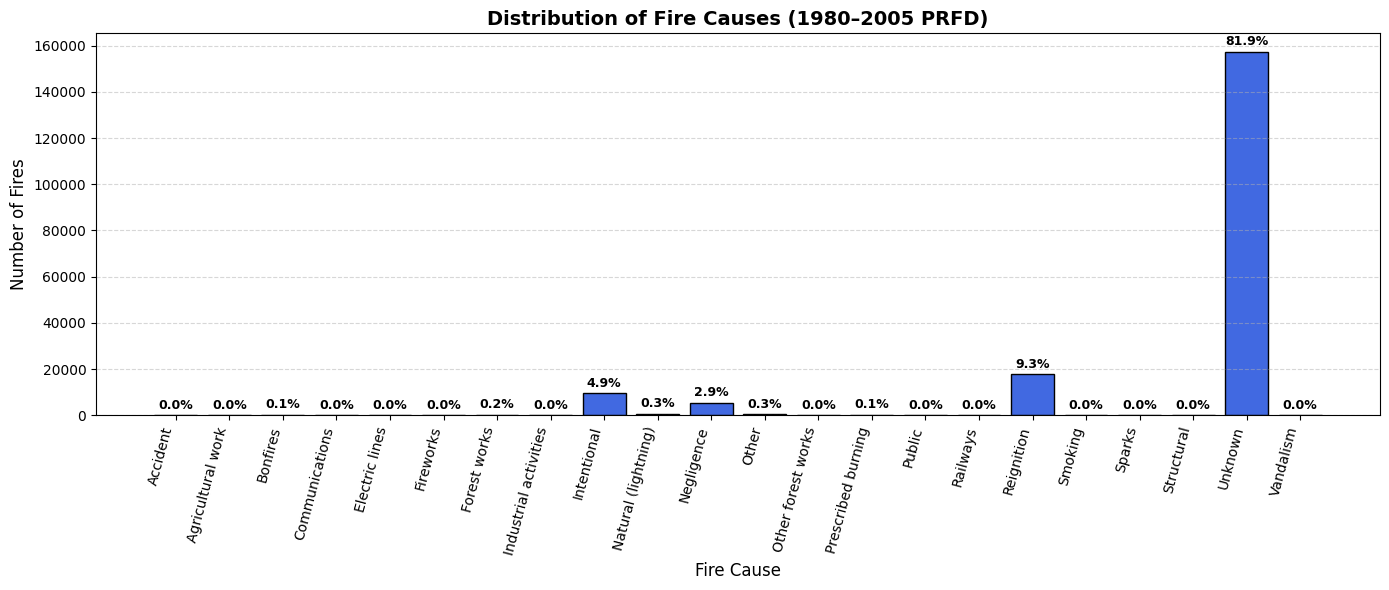

In [17]:
# --- Mapping from README (PRFD 2011) ---
cause_names = {
    1: "Negligence",
    2: "Prescribed burning",
    3: "Forest works",
    4: "Bonfires",
    5: "Smoking",
    6: "Sparks",
    7: "Railways",
    8: "Electric lines",
    9: "Fireworks",
    10: "Intentional",
    11: "Natural (lightning)",
    12: "Unknown",
    13: "Other",
    14: "Agricultural work",
    15: "Other forest works",
    16: "Industrial activities",
    17: "Communications",
    18: "Public",
    19: "Reignition",
    20: "Accident",
    21: "Structural",
    22: "Vandalism"
}

# --- Map numeric codes to names ---
df['cause_name'] = df['cause_code'].map(cause_names)

# --- Count occurrences ---
cause_counts = df['cause_name'].value_counts().sort_index()

# --- Calculate percentages ---
total_fires = cause_counts.sum()
percentages = (cause_counts / total_fires) * 100

# --- Plot ---
plt.figure(figsize=(14,6))
bars = plt.bar(cause_counts.index, cause_counts.values, color='royalblue', edgecolor='black')

# Title and labels
plt.title("Distribution of Fire Causes (1980–2005 PRFD)", fontsize=14, weight='bold')
plt.xlabel("Fire Cause", fontsize=12)
plt.ylabel("Number of Fires", fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels on top of bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.01 * max(cause_counts.values)),
             f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


As shown in the previous figure, the category **“Unknown”** overwhelmingly dominates the distribution of fire causes,  
representing the vast majority of all recorded events.  

This also occurs in the official PRFD report (AFN, 2011) and in *Pereira et al. (2011)*,  
most fires **(≈92.5%)** were classified as *unknown cause* due to limited field investigation, particularly in the early decades of the dataset.  

**However** this is not what observed here, confirming that there is something wrong with the dataset.

In [18]:
df['cause_code'].value_counts()

cause_code
0     261465
12    157426
19     17790
10      9473
1       5519
11       533
13       512
3        290
2        255
4        103
6         67
9         55
8         42
5         18
22         8
7          7
14         5
21         3
15         2
18         1
17         1
16         1
20         1
Name: count, dtype: int64

The **values_count()** function revealed that there is a label that is more common than the **Unknown** label (code 12), this is not expected since in the original dataset descirbed in *Pereira et al. (2011, Section 3.2)* the Unknown label makes up ~92.5% of the all the fire instances. Also this cause_code is not documented in the ofcial metadata file that is made avaible by the authors of *Pereira et al. (2011)*.

This poses the question of **what does the cause_code 0 represent**, having into consideration the original porpotion of the label Unknown it is plausible to think that the **code 0 also represents the class Unknown**

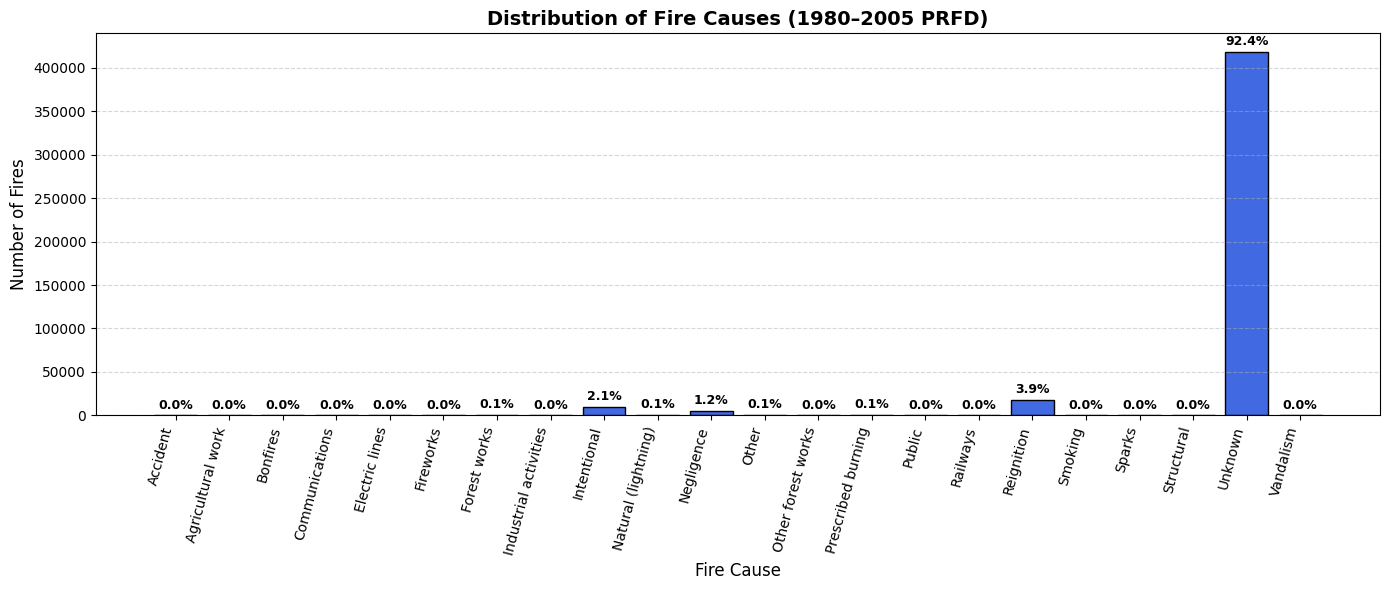

In [19]:
# --- Mapping adapted from README (PRFD 2011) ---
cause_names = {
    0: "Unknown",
    1: "Negligence",
    2: "Prescribed burning",
    3: "Forest works",
    4: "Bonfires",
    5: "Smoking",
    6: "Sparks",
    7: "Railways",
    8: "Electric lines",
    9: "Fireworks",
    10: "Intentional",
    11: "Natural (lightning)",
    12: "Unknown",
    13: "Other",
    14: "Agricultural work",
    15: "Other forest works",
    16: "Industrial activities",
    17: "Communications",
    18: "Public",
    19: "Reignition",
    20: "Accident",
    21: "Structural",
    22: "Vandalism"
}

# --- Map numeric codes to names ---
df['cause_name'] = df['cause_code'].map(cause_names)

# --- Count occurrences ---
cause_counts = df['cause_name'].value_counts().sort_index()

# --- Calculate percentages ---
total_fires = cause_counts.sum()
percentages = (cause_counts / total_fires) * 100

# --- Plot ---
plt.figure(figsize=(14,6))
bars = plt.bar(cause_counts.index, cause_counts.values, color='royalblue', edgecolor='black')

# Title and labels
plt.title("Distribution of Fire Causes (1980–2005 PRFD)", fontsize=14, weight='bold')
plt.xlabel("Fire Cause", fontsize=12)
plt.ylabel("Number of Fires", fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels on top of bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.01 * max(cause_counts.values)),
             f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


With the assumption that the code 0 also represents instances where the cause is Unknown, the distribution obtained is very similiar to the described in *Pereira et al. (2011, Section 3.2)*  where the classes **Unknown**, **Reignition**, **Intentional** and **Negligence** represent respectively **92.5% (0.1%)**, **3.9% (0%)**, **2.1% (0%)** and **1.4% (0.2%)** of the total dataset, the values in parentheses are the absolute values of the diference between the percentages in original copy and what was obtained in this experiment. As a consequence it is safe to assume that the code 0 does in fact also represent the label **Unknown**.

As the objective of the classification problem is to distinguish **intentional** from **non-intentional** fires it is impossible to map the **Unknown** label to one the two classes, therefore the best approach is to not use these instances. 

##### 2.2.15. Distribution of Fire Causes in Portugal (1980–2005, Excluding “Unknown”)
[[go back to the topic]](#22-data-preprocessing)

Before commiting to dropping the majority of the rows in the dataset, it's wise to analyse the distribution of the labels if the the Unknown label is excluded. It is also important to check if the learning task is feasiable with only a small fraction of the dataset.

The plot highlights that intentional ignition and negligence account for the majority of recorded fires, together representing nearly 80% of known causes, underscoring the dominant role of human behavior in fire occurrence.

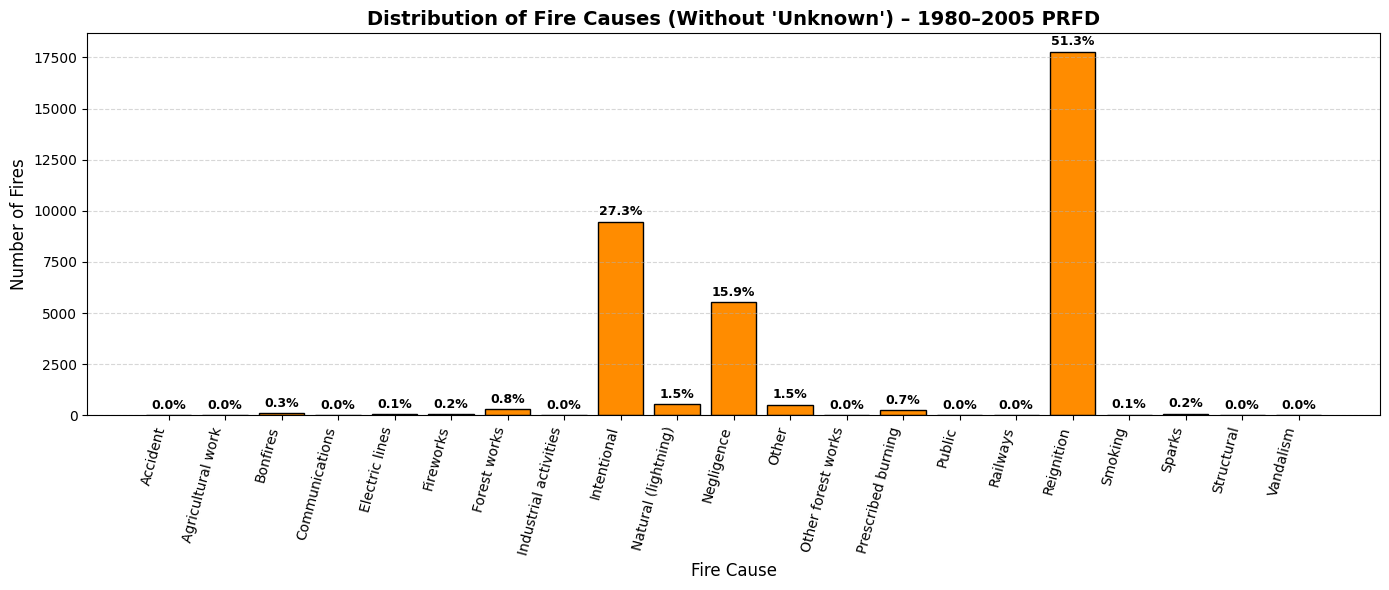

In [20]:
# Exclude "Unknown" to better visualize other causes
filtered_causes = cause_counts.drop("Unknown", errors="ignore")

# Calculate percentages
total_fires = filtered_causes.sum()
percentages = (filtered_causes / total_fires) * 100

# Plot
plt.figure(figsize=(14,6))
bars = plt.bar(filtered_causes.index, filtered_causes.values, color='darkorange', edgecolor='black')

# Title and labels
plt.title("Distribution of Fire Causes (Without 'Unknown') – 1980–2005 PRFD", fontsize=14, weight='bold')
plt.xlabel("Fire Cause", fontsize=12)
plt.ylabel("Number of Fires", fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels on top of bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.01 * max(filtered_causes.values)),
             f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


In [21]:
print(f"Number of instances of the dataset with Unknown: {df.shape[0]}")
print(f"Shape of the dataset without Unknown: {filtered_causes.sum()}")

Number of instances of the dataset with Unknown: 453577
Shape of the dataset without Unknown: 34686


If all Unknown intances are dropped the dataset has over 30,000 which is enough for ML models to generalize well

In [22]:
# Drop all instances that represent the label Unknown
df = df[(df["cause_code"] != 12) & (df["cause_code"] != 0)]

##### 2.2.16. Label Maping
[[go back to the topic]](#22-data-preprocessing)

As said before it is the models will classify the fires causes as intentional or not intentional, so it is necessary to map all **non-intentional** causes with the new **cause_code 0** and the **intentionals with the cause_code 1**

In [23]:
df['cause_code'].value_counts()

cause_code
19    17790
10     9473
1      5519
11      533
13      512
3       290
2       255
4       103
6        67
9        55
8        42
5        18
22        8
7         7
14        5
21        3
15        2
16        1
18        1
20        1
17        1
0         0
12        0
Name: count, dtype: int64

In [24]:
df['cause_code'] = df['cause_code'].apply(lambda x: 1 if x==10 else 0)

In [25]:
df['cause_code'].value_counts()

cause_code
0    25213
1     9473
Name: count, dtype: Int64

##### 2.2.17. Numeric Feature Scaling
[[go back to the topic]](#22-data-preprocessing)

Scaling the numeric features to the range [0,1] is done because as it is going to be discussed in the Pre-Modeling section using Logistic regression with features that have different ranges makes the model less interpretable. 

In [26]:
df[numeric_cols].describe()

,shrub_pub,shrub_priv,shrub_total,forest_pub,forest_priv,forest_total,area_total,area_agri,duration_min
count,24823.000000,24823.000000,34686.000000,24823.000000,24823.000000,34686.000000,34686.000000,4719.000000,34686.000000
mean,1.198750,7.709077,10.609127,1.242927,9.081860,13.368797,23.977923,8.077664,260.941545
std,19.041824,113.411401,122.026551,28.316869,215.558394,226.296083,310.078405,120.130366,1867.544551
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000010,0.000000,1.000800
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.000000,64.998720
50%,0.000000,0.050000,0.100000,0.000000,0.000000,0.000000,0.500000,0.000000,110.000160
75%,0.000000,0.500000,1.000000,0.000000,0.117500,0.600000,2.000000,0.000000,209.999520
max,1026.000000,8462.500000,8462.500000,2705.000000,25511.426000,25511.426000,30161.426000,5585.800000,262260.000000


In [27]:
scaler = MinMaxScaler()
df[numeric_cols]= scaler.fit_transform(df[numeric_cols])


In [28]:
df[numeric_cols].describe()

,shrub_pub,shrub_priv,shrub_total,forest_pub,forest_priv,forest_total,area_total,area_agri,duration_min
count,24823.000000,24823.000000,34686.000000,24823.000000,24823.000000,34686.000000,34686.000000,4719.000000,34686.000000
mean,0.001168,0.000911,0.001254,0.000459,0.000356,0.000524,0.000795,0.001446,0.000991
std,0.018559,0.013402,0.014420,0.010468,0.008449,0.008870,0.010281,0.021506,0.007121
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000002,0.000000,0.000244
50%,0.000000,0.000006,0.000012,0.000000,0.000000,0.000000,0.000017,0.000000,0.000416
75%,0.000000,0.000059,0.000118,0.000000,0.000005,0.000024,0.000066,0.000000,0.000797
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [29]:
# Save the cleaned and processed DataFrame
df.to_csv("data/FireDataset_clean.csv", index=False)

#### 2.3. Data Understanding and Descriptive Analysis
[[go back to the topic]](#2-pre-modelling)

This section explores the dataset through descriptive statistics and visual summaries to better understand its structure and distribution before modelling.

##### 2.3.1. Temporal Analysis  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

The goal here is to examine how wildfire frequency and total burnt area evolved over time.  
This allows us to identify trends, peaks, and anomalies (e.g., years with extreme events).  


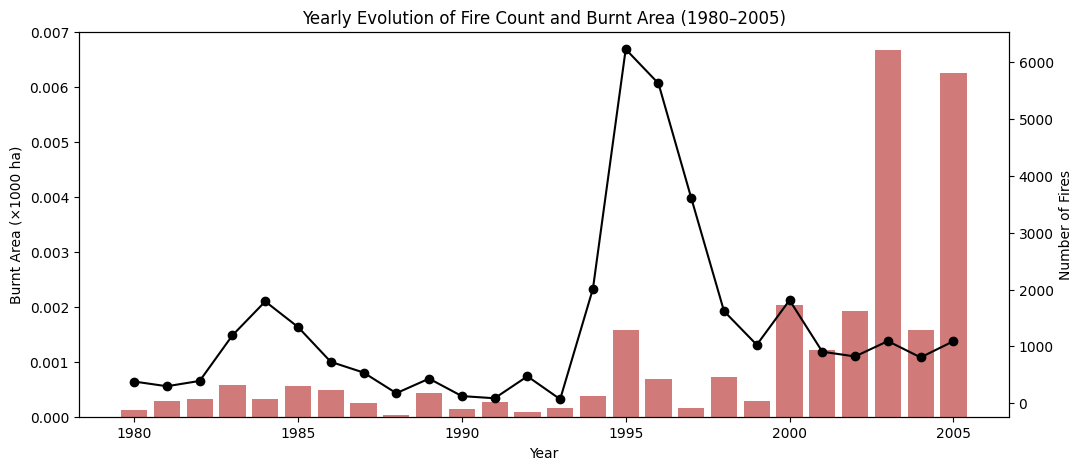

In [30]:
# Number of fires and total area per year
yearly = df.groupby('start_year').agg({'area_total': 'sum', 'district_id': 'count'}).rename(columns={'district_id': 'fire_count'})

fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()

ax1.bar(yearly.index, yearly['area_total']/1000, color='firebrick', alpha=0.6, label='Total Burnt Area (×1000 ha)')
ax2.plot(yearly.index, yearly['fire_count'], color='black', marker='o', label='Number of Fires')

ax1.set_xlabel("Year")
ax1.set_ylabel("Burnt Area (×1000 ha)")
ax2.set_ylabel("Number of Fires")
ax1.set_title("Yearly Evolution of Fire Count and Burnt Area (1980–2005)")
plt.show()


The examination of the annual progression of rural fires from 1980 to 2005 indicates a definitive upward trajectory in both the frequency of recorded incidents and the aggregate area that has burned. The accompanying chart illustrates that the early years of the dataset, specifically the early 1980s, display comparatively low levels of fire activity, characterized by both limited frequency and a modest total area impacted. Nevertheless, beginning in the early 1990s, there is a significant escalation, characterized by frequent variances yet demonstrating a persistent overall augmentation in scale.
A few exceptional peaks are prominent in this time frame. The years **1995**, **1998**, and especially **2003** represent the very highest levels of destruction, with areas burned exceeding past records. These events overlap with very well-documented cases of extreme weather in Portugal, such as heat waves and dry periods that increased the spread of the fires. It is also significant that the link between frequency of fire and burned area is not a linear one — some years with comparably fewer ignitions represent much larger burned areas, implying that some specific fires had developed into large-scale, basin-scale events, rather than into multiple, smaller ones.

The results show a **slow increase in the number of rural-fire incidents** over the period between 1980 and 2005, consistent with the tendencies noted in the Portuguese Rural Fire Database (PRFD) documentation and also expressed by Pereira et al. (2011). This further confirms the need to consider both climatic variability and changes in land use as key factors leading towards increased intensity and frequency of wildfires in the mainland Portugal.

##### 2.3.2. Monthly Patterns  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

Fires show clear seasonality, peaking during the summer months.  
We will aggregate both fire counts and total burnt area by month.


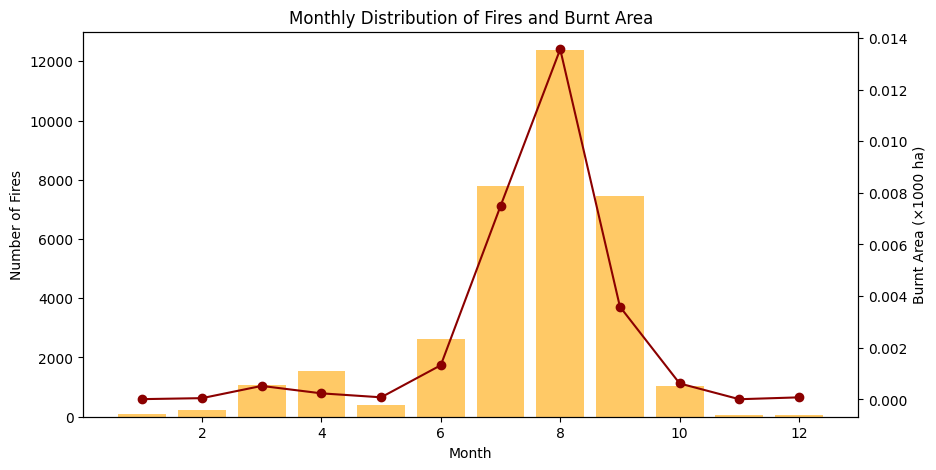

In [31]:
monthly = df.groupby('start_month').agg({'area_total':'sum','district_id':'count'}).rename(columns={'district_id':'fire_count'})
fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

ax1.bar(monthly.index, monthly['fire_count'], color='orange', alpha=0.6, label='Fire Count')
ax2.plot(monthly.index, monthly['area_total']/1000, color='darkred', marker='o', label='Total Area (×1000 ha)')

ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Fires")
ax2.set_ylabel("Burnt Area (×1000 ha)")
ax1.set_title("Monthly Distribution of Fires and Burnt Area")
plt.show()


The monthly analysis of fire occurrences and total burnt area reveals a pronounced seasonal pattern. Fire activity remains very low during the colder and wetter months (from November to April), followed by a sharp and sustained increase throughout the summer season.  

From **June to September**, both the number of recorded fires and the corresponding burnt area rise dramatically, reaching a peak in **August**, when approximately one third of all fires in the dataset occur and the total burnt area reaches its annual maximum. This period coincides with the driest and hottest phase of the year in mainland Portugal, when vegetation is more flammable and atmospheric conditions strongly favor ignition and rapid propagation.  

After September, a marked decline is observed, returning to low levels by October and November. This seasonal distribution is consistent with the patterns described in the PRFD documentation and in national reports on wildfire activity, confirming the **strong dependence of rural fires on climatic and meteorological factors**. The dominance of summer months in both frequency and magnitude highlights the importance of preventive measures and early response systems during this critical season.


##### 2.3.3. Duration Distribution  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

We now inspect how long fires last on average and how duration relates to burnt area.


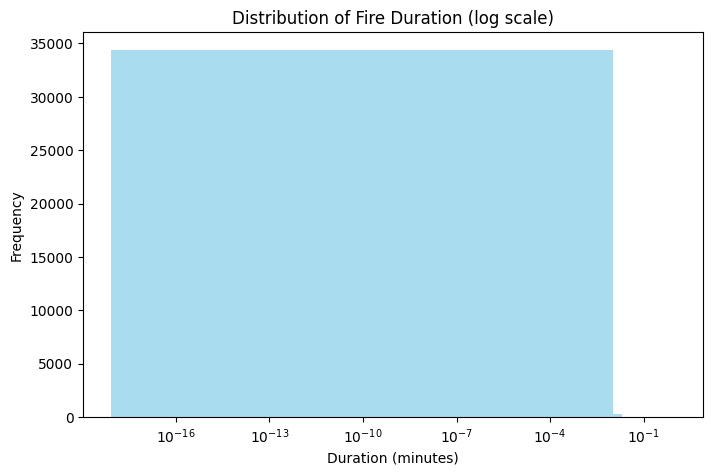

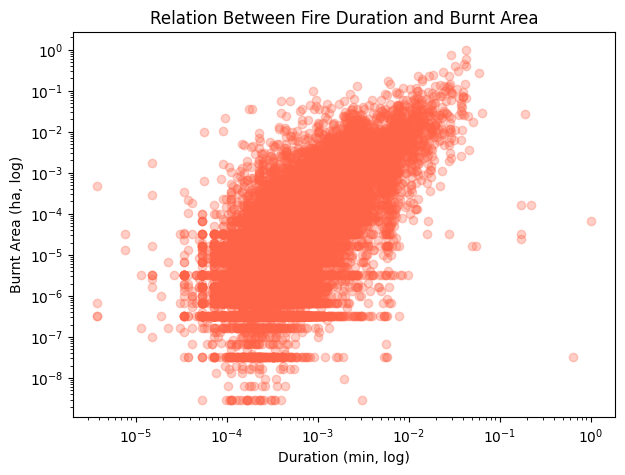

In [32]:
plt.figure(figsize=(8,5))
plt.hist(df['duration_min'], bins=100, color='skyblue', alpha=0.7)
plt.xscale('log')
plt.title("Distribution of Fire Duration (log scale)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

# Relation between duration and area
plt.figure(figsize=(7,5))
plt.scatter(df['duration_min'], df['area_total'], alpha=0.3, color='tomato')
plt.xscale('log'); plt.yscale('log')
plt.xlabel("Duration (min, log)")
plt.ylabel("Burnt Area (ha, log)")
plt.title("Relation Between Fire Duration and Burnt Area")
plt.show()



The first chart shows that most fires in the PRFD dataset lasted only a short time. Almost all events were controlled within a few hours, while only a small number extended for more than a day. This indicates that, in most situations, fire response was relatively fast or that the fires did not spread widely.  

In the second chart, we can see the relation between fire duration and total burnt area. There is a general trend showing that longer fires tend to burn larger areas. Still, there are some exceptions: a few short fires affected large areas, while some long ones remained small. These differences can be explained by local factors such as wind, vegetation type, or how quickly firefighting teams acted.  

Overall, the data suggests that **fire duration is related to the area burnt**, but other conditions strongly influence how much damage a fire can cause. Most extreme cases — very short but large fires, or very long but small ones — are rare and likely the result of unusual weather or terrain conditions.

##### 2.3.4. Spatial Analysis  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)


Understanding how fires are distributed spatially allows us to locate high-risk regions.  
Here we aggregate by district.


/tmp/ipykernel_77682/3443390053.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  district_stats = df.groupby('district').agg({


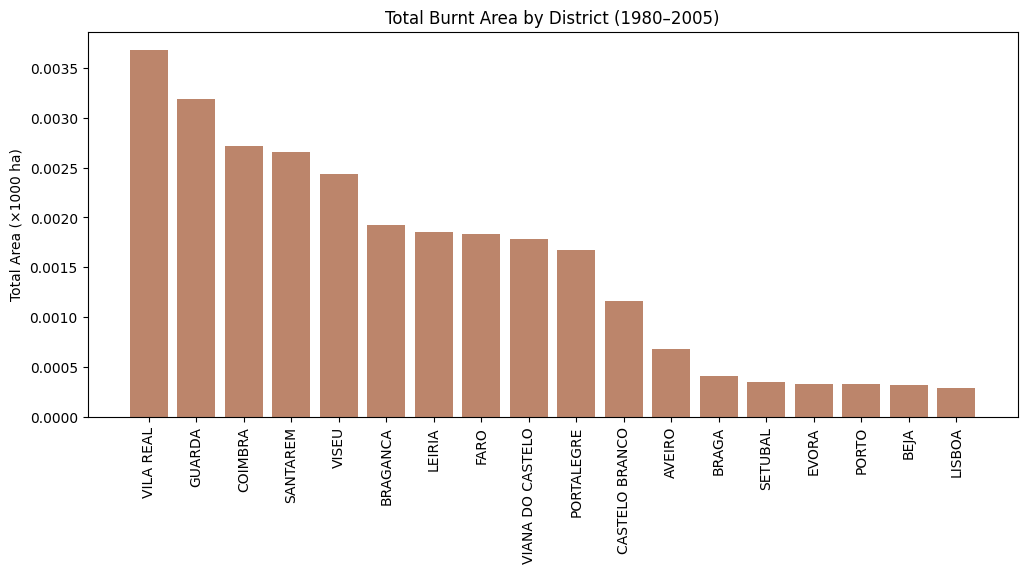

In [33]:
district_stats = df.groupby('district').agg({
    'area_total': 'sum',
    'district_id': 'count',
    'duration_min': 'mean'
}).rename(columns={'district_id':'fire_count'})

district_stats = district_stats.sort_values('area_total', ascending=False)

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(district_stats.index, district_stats['area_total']/1000, color='sienna', alpha=0.7)
plt.xticks(rotation=90)
plt.title("Total Burnt Area by District (1980–2005)")
plt.ylabel("Total Area (×1000 ha)")
plt.show()


The spatial distribution of burnt area across Portuguese districts shows a clear regional pattern. The **central and northern interior regions** were the most affected by rural fires, with **Guarda**, **Castelo Branco**, and **Viseu** standing out as the districts with the largest total burnt area. These areas are characterized by extensive forest cover and rugged terrain, which favor both ignition and fire spread.

On the other hand, **coastal and southern districts** such as **Lisboa**, **Évora**, **Beja**, and **Setúbal** show much smaller values. This contrast reflects differences in vegetation density, land use, and climate conditions — particularly the drier but less forested nature of the Alentejo region and the higher urbanization along the coast.

Overall, the data reveals a strong **geographical asymmetry** in wildfire impact, confirming that central and northern inland districts play a major role in the country’s total burnt area during the 1980–2005 period.


/tmp/ipykernel_77682/2150958781.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  county_stats = df.groupby('county').agg({


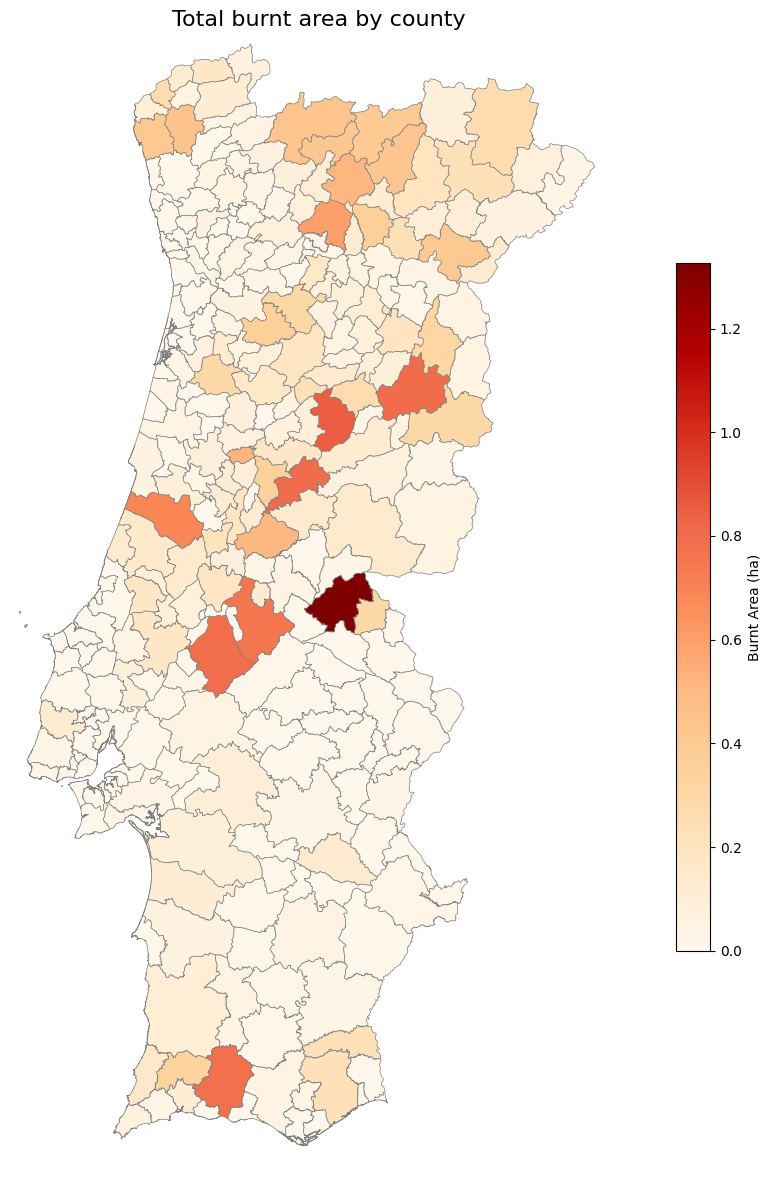

In [34]:
gdf= gpd.read_file("data/concelhos-shapefile/concelhos.shp")

county_stats = df.groupby('county').agg({
    'area_total': 'sum',
    'county': 'count',
    'duration_min': 'mean'
}).rename(columns={'county':'fire_count'}).reset_index()

def normalize_name(name):
    if pd.isna(name):
        return ""
    # Remove accents (e.g., ç -> c, ã -> a)
    name = ''.join(
        c for c in unicodedata.normalize('NFKD', name)
        if not unicodedata.combining(c)
    )
    # Replace dashes with spaces
    name = name.replace("-", " ")
    # Collapse multiple spaces and uppercase
    name = re.sub(r"\s+", " ", name).strip().upper()
    return name

gdf["NAME_2_norm"] = gdf["NAME_2"].apply(normalize_name) #this line makes every letter uppercase and substitutes ç for c and other special cases
county_stats["county_norm"] = county_stats["county"].apply(normalize_name)
merged = gdf.merge(county_stats, left_on="NAME_2_norm", right_on="county_norm", how="left")

#Plot

fig,ax= plt.subplots(1,1, figsize=(10,12))
merged.plot(
    column="area_total",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="grey",
    legend=True,
    legend_kwds={"shrink":0.6, "label": "Burnt Area (ha)"},
    ax=ax
)

ax.set_title("Total burnt area by county", fontsize=16)
ax.axis("off")

# limit the map to the continent 
ax.set_xlim([-9.6, -6.0])
ax.set_ylim([36.8, 42.2])

plt.tight_layout()
plt.show()

This image allows for a visual interpretation of the inbalance in the of the data, most of the area burnt in fires is concentrated in a small area of the country as the previous grapth showed. However this grapth has some issues, since the **shapefile** used to make it was **not created** by the **authors of the dataset**, it leads to some counties that are on the dataset to not be on the shapefile and vice versa as such it is necessary to understand what they are and the impact they have on the overall visualization that the grapth provides. 

The shape file 
used for this is avaiable in the [dados.gov ](https://dados.gov.pt/en/datasets/concelhos-de-portugal/?utm_source=chatgpt.com#/resources) website

##### 2.3.5. Spatial Distribution of Fire Incidents by District (1980–2005)
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

The chart displays the spatial distribution of fire occurrences across Portuguese districts between 1980 and 2005.
Districts such as **Porto**, **Braga**, and **Viseu** register the highest number of incidents, indicating a strong concentration of fire activity in the northern region of the country.


/tmp/ipykernel_77682/2704917123.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fires_per_district = df.groupby('district')['district'].count().sort_values(ascending=False)


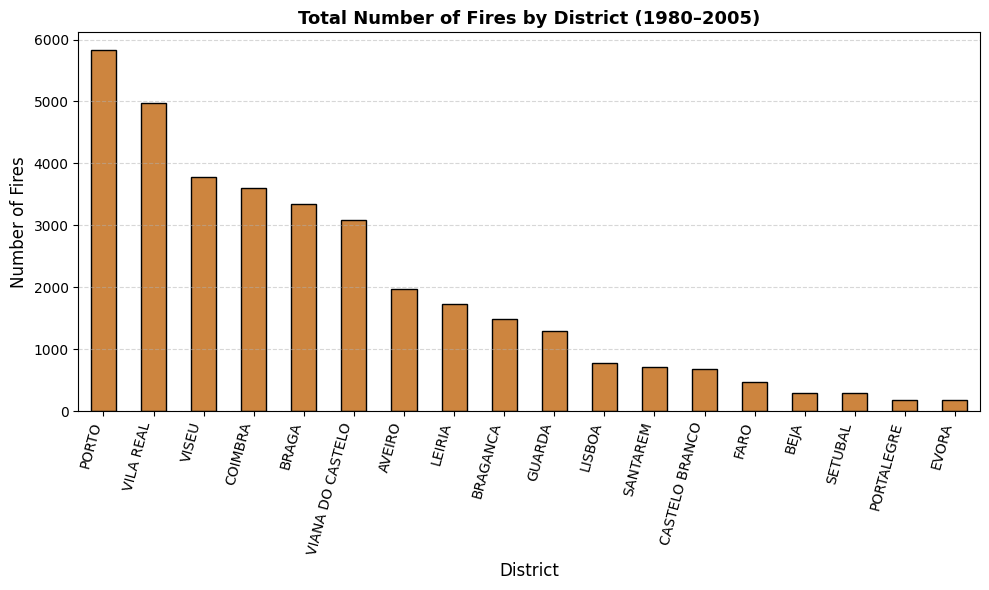

In [37]:
# --- Count number of fires per district ---
fires_per_district = df.groupby('district')['district'].count().sort_values(ascending=False)

# --- Plot ---
plt.figure(figsize=(10,6))
fires_per_district.plot(kind='bar', color='peru', edgecolor='black')

plt.title("Total Number of Fires by District (1980–2005)", fontsize=13, weight='bold')
plt.xlabel("District", fontsize=12)
plt.ylabel("Number of Fires", fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


The data reveal a clear concentration of fire incidents in northern districts, particularly **Porto**, **Braga**, and **Viseu**.
However, this distribution appears disproportionate when compared with the actual extent of burned areas, since Porto does not possess large forested regions.
This suggests that in some districts, fires are more frequent but smaller in scale, whereas in others they may be fewer but cover larger areas, prompting the need for the next analysis to contrast **fire frequency** with **total area burned**.


##### 2.3.6. Comparison Between Fire Frequency and Total Burned Area by District (1980–2005)
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

This graph compares the **number of fires** (black line) and the **total burnt area** (brown bars) across Portuguese districts between 1980 and 2005.


/tmp/ipykernel_77682/938035024.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  district_stats = df.groupby('district').agg({


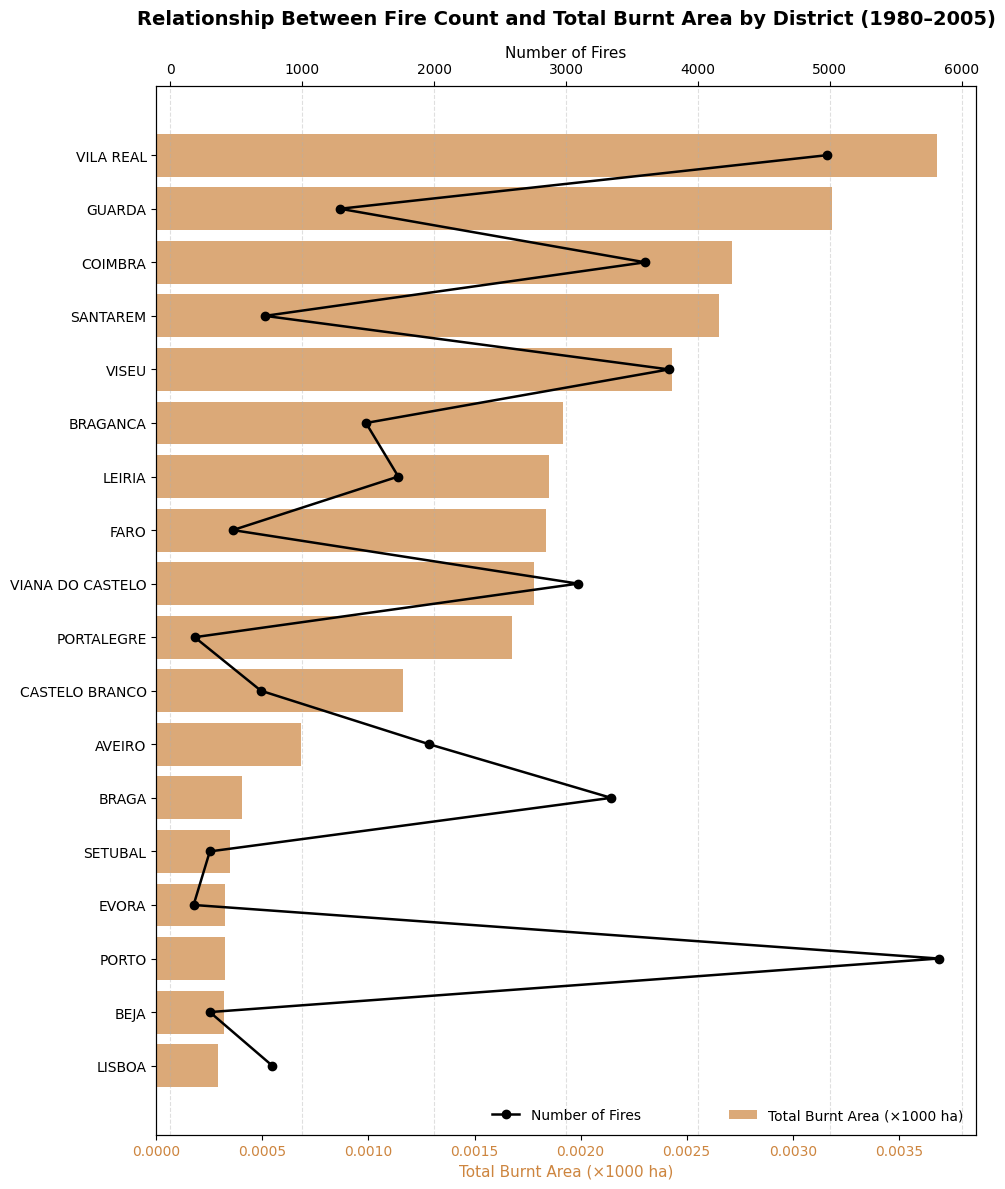

In [38]:
district_stats = df.groupby('district').agg({
    'area_total': 'sum',
    'district_id': 'count'
}).rename(columns={'district_id': 'fire_count'})

district_stats = district_stats.sort_values('area_total', ascending=True)  # ascending for horizontal bars

fig, ax1 = plt.subplots(figsize=(10, 12))

# --- Horizontal bars for total area ---
bars = ax1.barh(
    district_stats.index,
    district_stats['area_total'] / 1000,
    color='peru',
    alpha=0.7,
    label='Total Burnt Area (×1000 ha)'
)
ax1.set_xlabel("Total Burnt Area (×1000 ha)", color='peru', fontsize=11)
ax1.tick_params(axis='x', labelcolor='peru')

# --- Secondary axis for number of fires ---
ax2 = ax1.twiny()
ax2.plot(
    district_stats['fire_count'],
    district_stats.index,
    color='black',
    marker='o',
    linewidth=1.8,
    label='Number of Fires'
)
ax2.set_xlabel("Number of Fires", color='black', fontsize=11)
ax2.tick_params(axis='x', labelcolor='black')

# (labels removed)

plt.title(
    "Relationship Between Fire Count and Total Burnt Area by District (1980–2005)",
    fontsize=14,
    weight='bold',
    pad=15
)
plt.grid(axis='x', linestyle='--', alpha=0.4)
ax1.legend(loc='lower right', frameon=False)
ax2.legend(loc='lower center', frameon=False)

plt.tight_layout()
plt.show()

The visualization clearly shows that northern and coastal districts, such as *Porto* and *Braga*, experienced the **highest number of fires**, but these were **generally smaller in area**.  
Conversely, central and interior regions, such as *Guarda*, *Castelo Branco*, and *Viseu*, had **fewer fires** but **significantly larger burnt areas**, indicating more severe events per ignition.

The horizontal labels improve readability, and the combined use of bars and lines helps illustrate the inverse relationship between frequency and intensity across regions.

##### 2.3.7. Land Cover Composition  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

The PRFD distinguishes between burnt forest and shrubland areas.  
This helps identify which land-cover type is more vulnerable to fire.


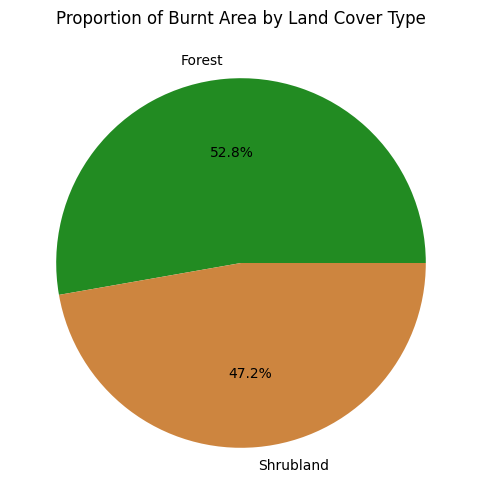

In [26]:
total_forest = df['forest_total'].sum()
total_shrub = df['shrub_total'].sum()

plt.figure(figsize=(6,6))
plt.pie([total_forest, total_shrub],
        labels=['Forest','Shrubland'],
        autopct='%1.1f%%',
        colors=['#228B22','#CD853F'])
plt.title("Proportion of Burnt Area by Land Cover Type")
plt.show()


The proportion of burnt area by land cover type reveals that **forest and shrubland areas were affected in almost equal measure** during the 1980–2005 period. Forests accounted for approximately **52.8%** of the total burnt area, while shrublands represented **47.2%**.  

This near balance suggests that fires in Portugal are not limited to a single vegetation type but rather affect both forested and shrub-dominated landscapes extensively. The slight predominance of forest fires reflects the large proportion of forested land in the central and northern regions, where conditions favor ignition and fire spread.  

In general, this distribution aligns with the structure of Portuguese rural landscapes, where forest and shrubland areas are often interspersed and both contribute significantly to the country’s wildfire statistics.

##### 2.3.8. Fire Size Categories  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

To better understand the distribution of fire magnitudes, we classify them into size categories.


/tmp/ipykernel_30390/1673599639.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_area = df.groupby('fire_size_cat')['area_total'].sum()


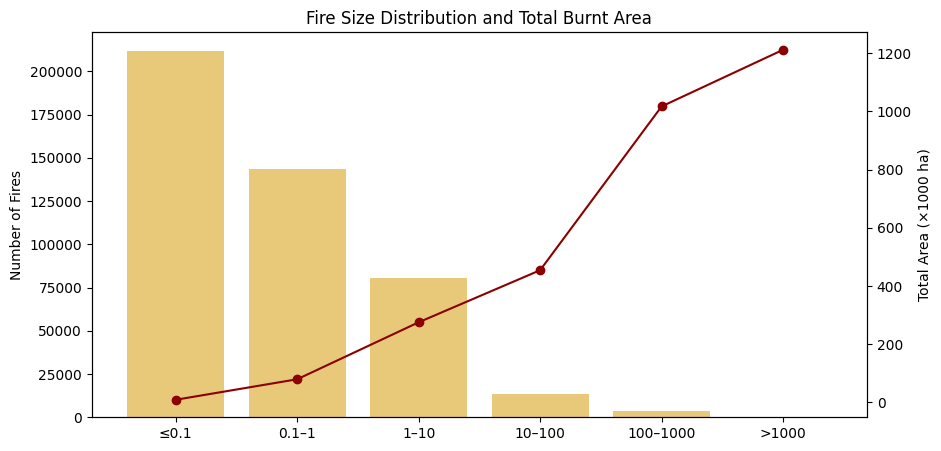

In [27]:
bins = [0, 0.1, 1, 10, 100, 1000, df['area_total'].max()]
labels = ['≤0.1','0.1–1','1–10','10–100','100–1000','>1000']
df['fire_size_cat'] = pd.cut(df['area_total'], bins=bins, labels=labels, include_lowest=True)

size_counts = df['fire_size_cat'].value_counts().sort_index()
size_area = df.groupby('fire_size_cat')['area_total'].sum()

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ax1.bar(size_counts.index, size_counts.values, alpha=0.6, label='Fire Count', color='goldenrod')
ax2.plot(size_area.index, size_area.values/1000, color='darkred', marker='o', label='Total Area (×1000 ha)')
ax1.set_ylabel("Number of Fires")
ax2.set_ylabel("Total Area (×1000 ha)")
plt.title("Fire Size Distribution and Total Burnt Area")
plt.show()


##### 2.3.9. Correlation Matrix  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

We inspect correlations among key numeric variables to detect interdependencies and potential predictive relationships.


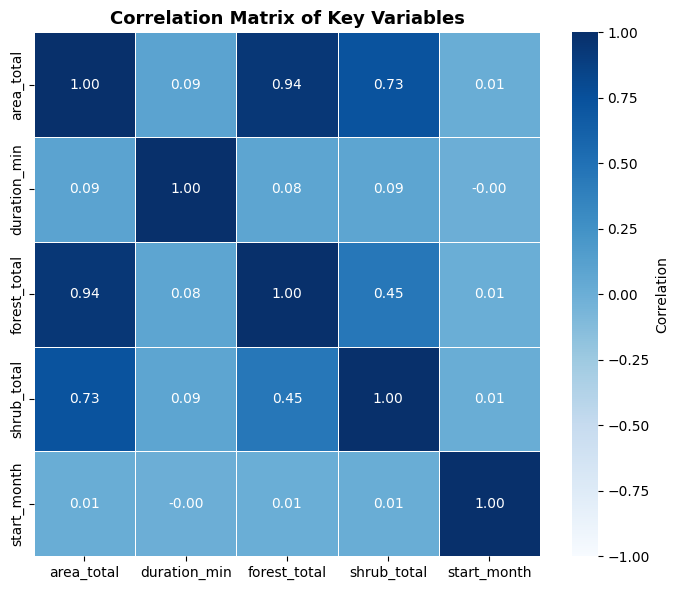

In [30]:
# Compute correlation matrix
corr = df[['area_total','duration_min','forest_total','shrub_total','start_month']].corr(numeric_only=True)

# Plot heatmap with blue color palette
plt.figure(figsize=(7,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',       # blue color scheme
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    fmt=".2f",          # two decimal places
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Matrix of Key Variables", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()


The plot above represents a **correlation matrix**.  
Each cell quantifies the **Pearson correlation coefficient** between two numerical variables, ranging from -1 (perfect negative relationship) to +1 (perfect positive relationship).  
The diagonal values of **1.00** indicate that each variable is perfectly correlated with itself — this is expected and does **not** reflect relationships between different features.  

Notably, `area_total` shows a strong positive correlation with `forest_total` (0.94) and `shrub_total` (0.73), meaning larger fires tend to involve both forested and shrub-covered land.  
By contrast, `duration_min` and `start_month` display almost no correlation with the burned area, suggesting that fire size is not strongly dependent on duration or season alone.


##### 2.3.10. Derived Ratios  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

We can derive additional indicators such as the proportion of burnt forest vs shrub and the average spread rate (ha/h).


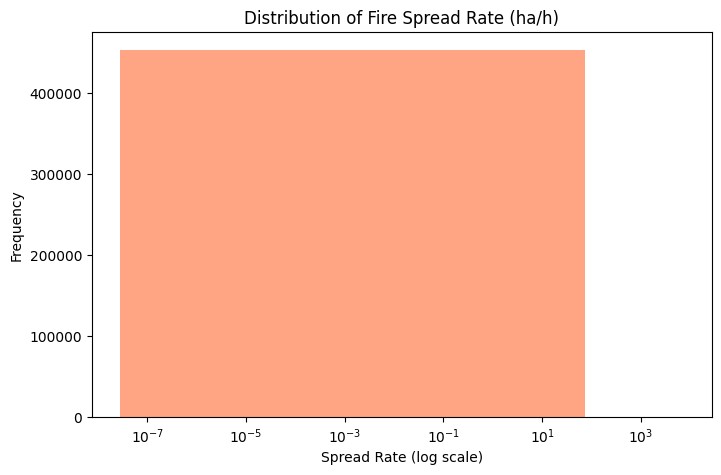

In [31]:
df['forest_ratio'] = df['forest_total'] / df['area_total'].replace(0, 1)
df['shrub_ratio'] = df['shrub_total'] / df['area_total'].replace(0, 1)
df['spread_rate'] = df['area_total'] / (df['duration_min'] / 60).replace(0, 1)

plt.figure(figsize=(8,5))
plt.hist(df['spread_rate'].dropna(), bins=100, color='coral', alpha=0.7)
plt.xscale('log')
plt.title("Distribution of Fire Spread Rate (ha/h)")
plt.xlabel("Spread Rate (log scale)")
plt.ylabel("Frequency")
plt.show()


The distribution of fire spread rate is highly skewed, with the majority of events concentrated at very low propagation values.
This indicates that most fires expand slowly, typically remaining localized, while a small minority exhibit extremely high spread rates.

Such imbalance is characteristic of wildfire data, where numerous small, quickly contained fires coexist with rare but severe large-scale events that dominate total burned area.


##### 2.3.11. Suspicious Records Visualization  
[[go back to the topic]](#2313-suspicious-records-visualization)

We highlight flagged records (those with extreme duration-area combinations) in the duration-area scatter plot.


Suspicious records: 348


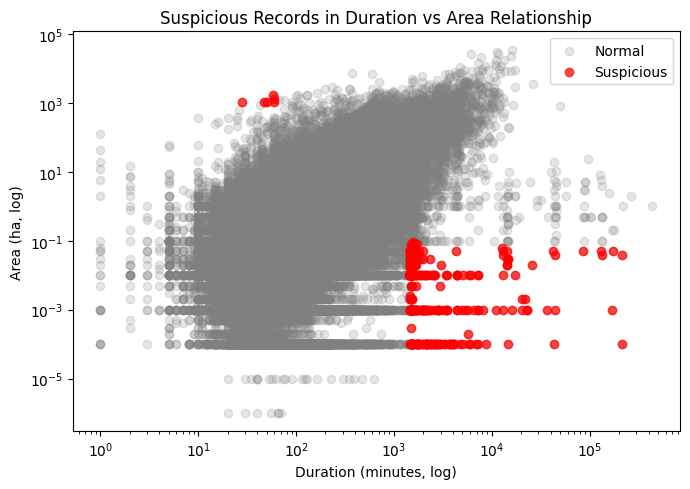

In [32]:
# --- Define suspicious fire conditions ---
tiny_long = (df['area_total'] < 0.1) & (df['duration_min'] > 1440)   # very small fires lasting > 1 day
huge_short = (df['area_total'] > 1000) & (df['duration_min'] < 60)   # huge fires lasting < 1 hour

# --- Create a new flag column ---
df['flag_suspicious'] = tiny_long | huge_short

# --- Check how many suspicious records exist ---
print("Suspicious records:", df['flag_suspicious'].sum())

# --- Plot relationship (log-log scale) ---
plt.figure(figsize=(7,5))
plt.scatter(df['duration_min'], df['area_total'], alpha=0.2, label='Normal', color='gray')
plt.scatter(df[df['flag_suspicious']]['duration_min'], df[df['flag_suspicious']]['area_total'],
            color='red', alpha=0.7, label='Suspicious')
plt.xscale('log'); plt.yscale('log')
plt.xlabel("Duration (minutes, log)")
plt.ylabel("Area (ha, log)")
plt.title("Suspicious Records in Duration vs Area Relationship")
plt.legend()
plt.tight_layout()
plt.show()


The script standardizes the dataset’s data types to ensure numerical and textual consistency.
Continuous variables such as areas, durations, and time fractions are coerced to **float**, while categorical or discrete identifiers like district IDs, fire type, and cause code are converted to **nullable integers (`Int64`)** to preserve missing values.
Geographic names and textual fields are stored as **strings**, ensuring a uniform schema and reliable handling of nulls before subsequent analysis or modelling.


#### 2.4. Pre-Modelling XAI Techniques
[[go back to the topic]](#pre-modelling)

This section introduces pre-modelling explainability tools used to explore the feature space before training predictive models.

In [34]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Use only numeric columns
X = df.select_dtypes(include=['number'])

# Impute missing values with column means
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Shape after imputation:", X_imputed.shape)
print("Any NaNs left?", np.isnan(X_imputed).any())

Shape after imputation: (34686, 30)
Any NaNs left? False


In [35]:
X.describe().T.head(5)  # Quick summary of numeric ranges

,count,mean,std,min,25%,50%,75%,max
district_id,34686.0,10.970449,5.662923,1.0,6.0,13.0,17.0,18.0
shrub_pub,24823.0,0.001168,0.018559,0.0,0.0,0.0,0.0,1.0
shrub_priv,24823.0,0.000911,0.013402,0.0,0.0,0.000006,0.000059,1.0
shrub_total,34686.0,0.001254,0.01442,0.0,0.0,0.000012,0.000118,1.0
forest_pub,24823.0,0.000459,0.010468,0.0,0.0,0.0,0.0,1.0


##### 2.4.1. PCA Dimensionality Reduction

In this step, we perform **Principal Component Analysis (PCA)** on the numerical features of the dataset to understand its underlying structure and identify which variables contribute most to the observed variance.

Before running PCA, all numeric columns were **imputed** for missing values using the column means and **standardized** (zero mean, unit variance) to ensure all features contribute equally regardless of scale.

The PCA decomposition helps:

* Identify **key dimensions** explaining the majority of the variability in the dataset.
* Detect **correlations or redundancy** among features (e.g., total area and vegetation-related variables).
* Provide a basis for potential **dimensionality reduction** before modeling.

The first plot shows the **cumulative explained variance** — how much of the total variance is captured as we include more principal components. We observe that the first few components already explain most of the variance, suggesting strong correlations among features.

The table below the plot lists the **top contributing variables** for the first two principal components:

* **PC1** is dominated by *area and vegetation-related variables* (`area_total`, `forest_total`, `shrub_total`, etc.), likely representing an overall “land or vegetation size” dimension.
* **PC2** captures variation mainly linked to `cause_code`, possibly representing differences in ignition or fire causes.

The scatter plot visualizes the dataset in the space of the first two components, showing that most observations cluster near the origin, with a few extending along PC1 — consistent with regions of exceptionally large area or vegetation.

Overall, the PCA results indicate that:

* The dataset’s variance is largely driven by land area and vegetation measures.
* Only a few components capture most of the information, enabling possible dimensionality reduction.
* The PCA transformation provides a useful low-dimensional representation for further exploration or visualization.

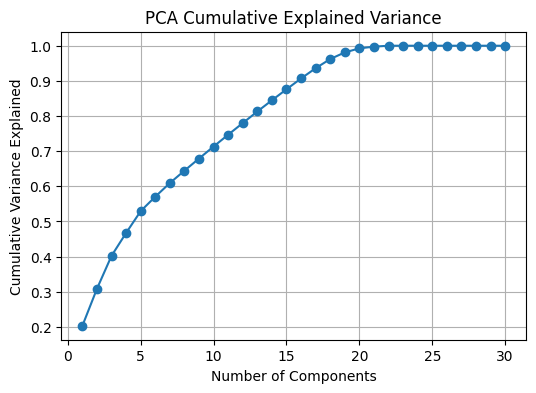

Top 10 features contributing to PC1:


,PC1,PC2
area_total,0.397900,0.028555
area_total_check,0.397900,0.028555
area_check,0.397900,0.028555
forest_total,0.369020,0.032025
forest_priv,0.328389,0.044188
shrub_total,0.326753,0.013170
shrub_priv,0.291538,0.028630
area_agri,0.233059,0.043269
area_total_diff,0.091847,0.000963
duration_min,0.086326,0.028572


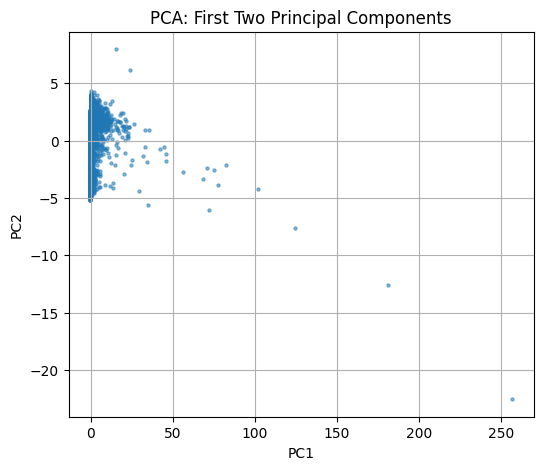

In [36]:
# 2.4.1 Dimensionality Reduction - PCA Analysis (Fixed for preprocessed X_scaled)
from sklearn.decomposition import PCA

Xs = X_scaled

# Optional: feature names (if using df)
feature_names = df.select_dtypes(include=['number']).columns.tolist()

# --- Run PCA ---
pca = PCA()
Z = pca.fit_transform(Xs)
explained = pca.explained_variance_ratio_

# --- Scree Plot ---
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(explained)+1), explained.cumsum(), marker='o')
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()

# --- Top Features Contributing to PC1 and PC2 ---
comps = pca.components_
loadings = pd.DataFrame(
    comps[:2, :].T,
    index=feature_names,
    columns=['PC1', 'PC2']
)
top_features = loadings.abs().sort_values('PC1', ascending=False).head(10)
print("Top 10 features contributing to PC1:")
display(top_features)

# --- 2D Projection Visualization ---
plt.figure(figsize=(6,5))
plt.scatter(Z[:, 0], Z[:, 1], s=5, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: First Two Principal Components')
plt.grid(True)
plt.show()


##### 2.4.1b. t-SNE Visualization
To uncover potential nonlinear structures, the script applies **t-SNE** on a random sample of scaled data.  
It produces scatterplots colored by district, cause, and weekday, helping visualize local neighborhood relationships and possible grouping behavior among records.

C:\Anaconda\envs\trabalho_labsiacd\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


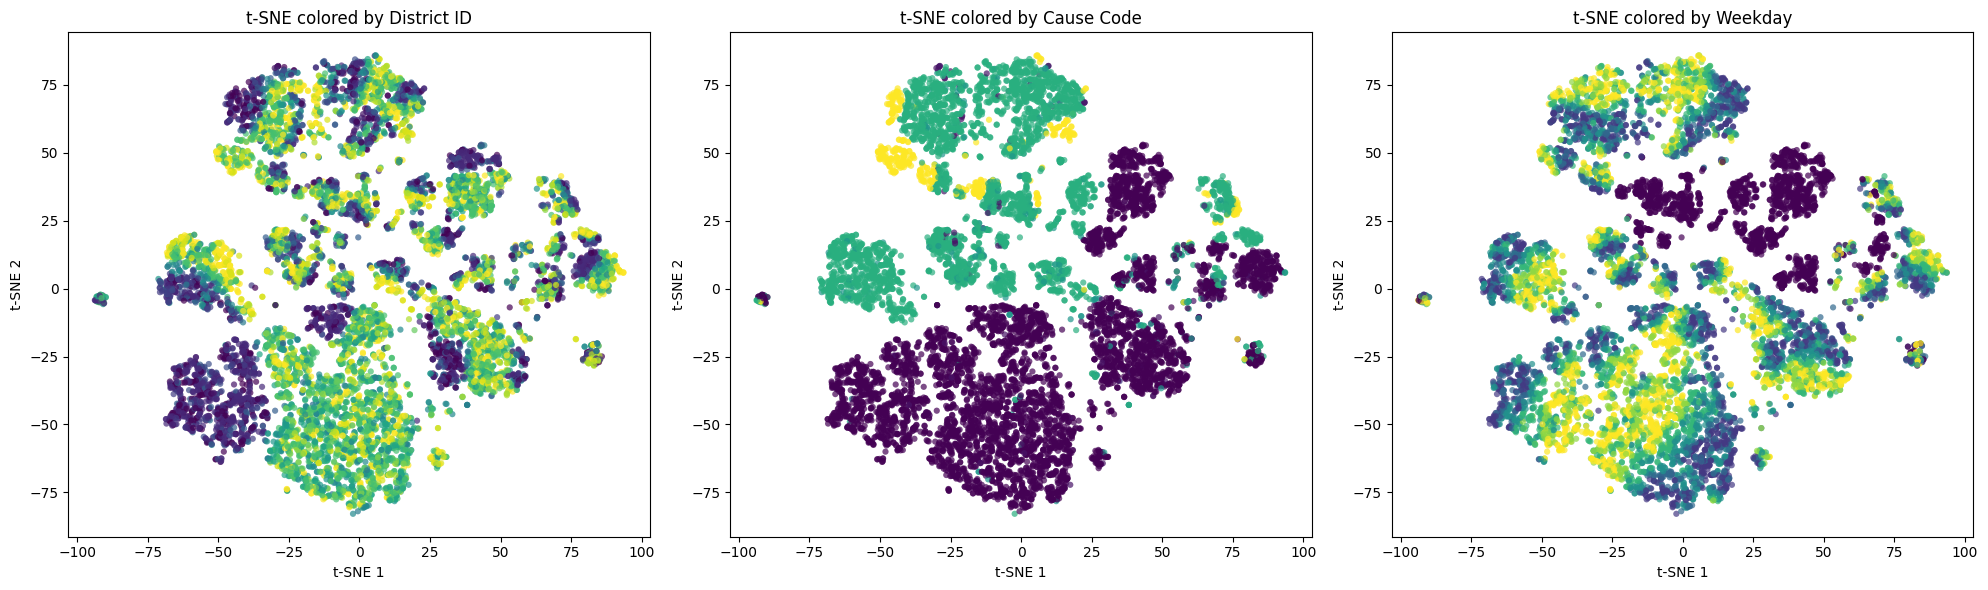

In [ ]:
from sklearn.manifold import TSNE

# Pick which columns to color by
color_vars = {
    "District ID": df["district_id"],
    "Cause Code": df["cause_code"],
    "Weekday": df["weekday"]
}

# Take a manageable sample (t-SNE can be slow)
sample_size = 10000  # adjust as needed
np.random.seed(42)

if len(X_scaled) > sample_size:
    idx = np.random.choice(len(X_scaled), sample_size, replace=False)
    X_sample = X_scaled[idx]
    color_vars = {k: v.iloc[idx] for k, v in color_vars.items()}
else:
    X_sample = X_scaled

# Run t-SNE once (so all share same embedding)
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42,
    init="pca"
)
Z = tsne.fit_transform(X_sample)

# Plot 3 panels side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (title, color_var) in zip(axes, color_vars.items()):
    sns.scatterplot(
        x=Z[:, 0],
        y=Z[:, 1],
        hue=color_var,
        palette="viridis",
        s=20,
        linewidth=0,
        alpha=0.7,
        ax=ax,
        legend=False  # cleaner layout
    )
    ax.set_title(f"t-SNE colored by {title}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


##### 2.4.1c. Enhanced t-SNE Visualization with Density
An improved visualization adds a **density heatmap** to the t-SNE embedding, highlighting concentration areas and distribution smoothness while retaining color-coded clusters for contextual interpretation.

C:\Anaconda\envs\trabalho_labsiacd\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


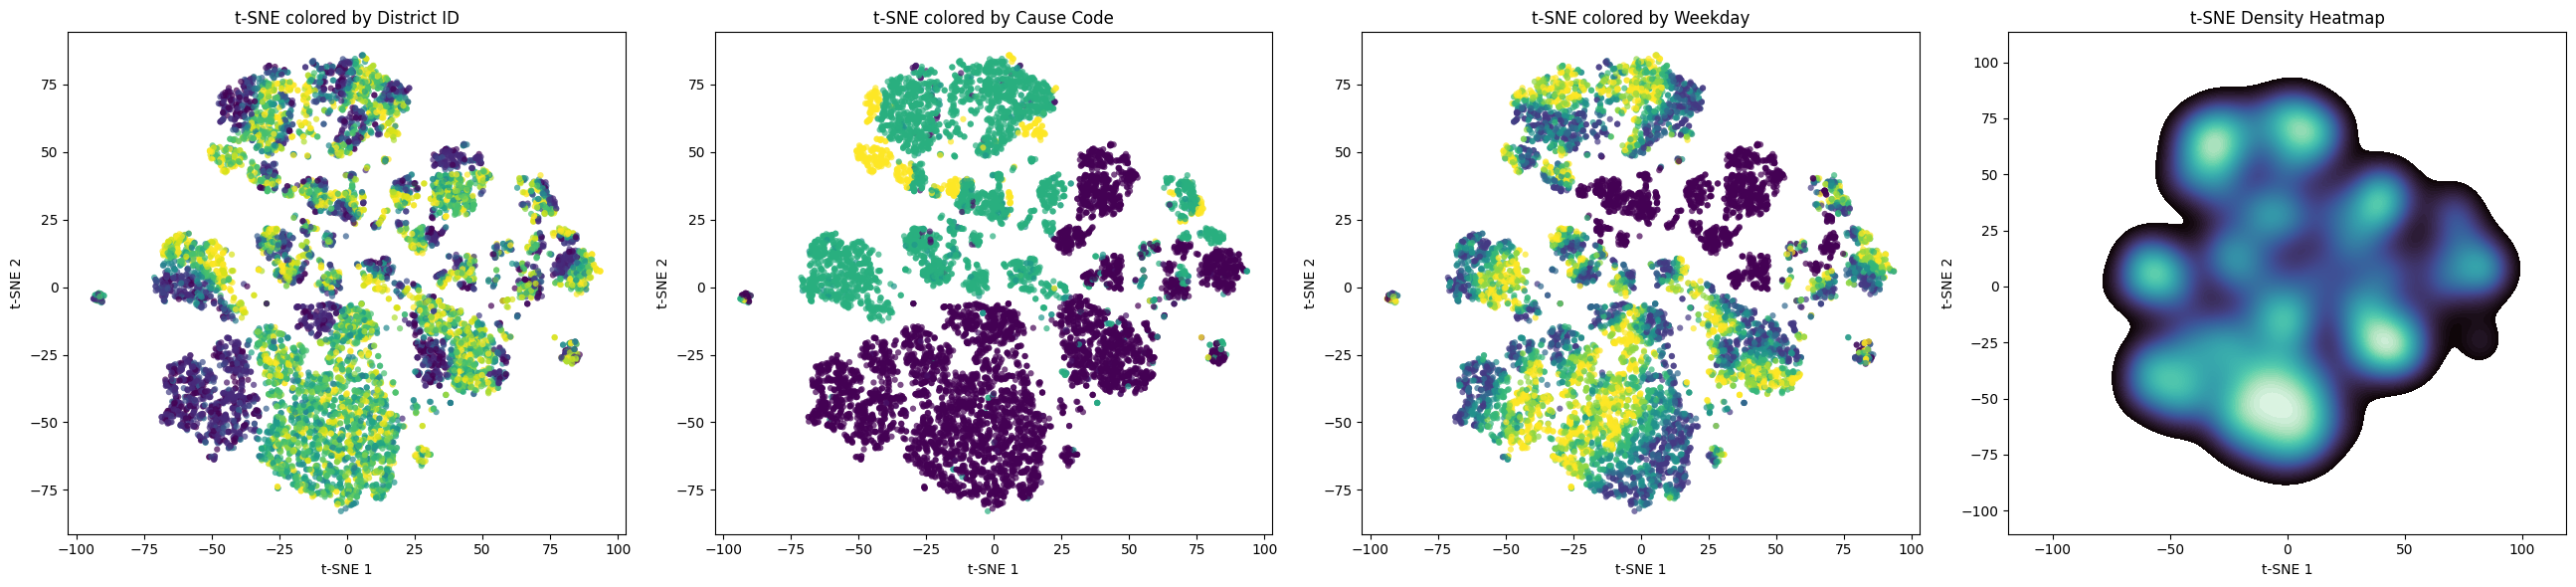

In [ ]:
# Variables to visualize
color_vars = {
    "District ID": df["district_id"],
    "Cause Code": df["cause_code"],
    "Weekday": df["weekday"]
}

# Sampling for efficiency
sample_size = 10000  # adjust as needed
np.random.seed(42)

if len(X_scaled) > sample_size:
    idx = np.random.choice(len(X_scaled), sample_size, replace=False)
    X_sample = X_scaled[idx]
    color_vars = {k: v.iloc[idx] for k, v in color_vars.items()}
else:
    X_sample = X_scaled

# Run t-SNE once (for consistency)
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42,
    init="pca"
)
Z = tsne.fit_transform(X_sample)

# ---- PLOTTING ----
fig, axes = plt.subplots(1, 4, figsize=(26, 6))
plt.subplots_adjust(wspace=0.3)

# 1–3: Colored scatterplots
for ax, (title, color_var) in zip(axes[:3], color_vars.items()):
    sns.scatterplot(
        x=Z[:, 0],
        y=Z[:, 1],
        hue=color_var,
        palette="viridis",
        s=20,
        linewidth=0,
        alpha=0.7,
        ax=ax,
        legend=False
    )
    ax.set_title(f"t-SNE colored by {title}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

# 4: Density heatmap
sns.kdeplot(
    x=Z[:, 0],
    y=Z[:, 1],
    fill=True,
    cmap="mako",
    ax=axes[3],
    thresh=0.05,
    levels=100
)
axes[3].set_title("t-SNE Density Heatmap")
axes[3].set_xlabel("t-SNE 1")
axes[3].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


In [ ]:
!pip install scikit-learn-extra

#### 2.4.2. Prototypes and Criticisms - K-Means Approximation
This part identifies representative examples (**prototypes**) and least typical examples (**criticisms**) in the dataset.  

Because `K-Medoids` had compatibility issues, **K-Means clustering** is used as a practical approximation:
- **Prototypes** are the real samples closest to each cluster centroid.  
- **Criticisms** are the most distant samples from any centroid, representing edge or rare cases.  

A 2D PCA projection displays prototypes as highlighted points, while a table lists the top criticisms.  
This approach enhances interpretability by grounding abstract clusters in real, understandable examples.


In [ ]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import pairwise_distances

# --- Data prep: use imputed & scaled numeric data ---
X_for_clustering = X_scaled  # already imputed + standardized

# --- Step 1: Fit K-Medoids clustering ---
k = 8  # adjust based on domain knowledge or elbow method
kmedoids = KMedoids(n_clusters=k, random_state=42, method='pam', metric='euclidean')
kmedoids.fit(X_for_clustering)

labels = kmedoids.labels_
medoid_indices = kmedoids.medoid_indices_
prototypes = X_for_clustering[medoid_indices]

print(f"Identified {k} prototypes (one per cluster).")

# --- Step 2: Visualize clusters in PCA or t-SNE space ---

pca_2d = PCA(n_components=2, random_state=42)
Z_pca = pca_2d.fit_transform(X_for_clustering)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=Z_pca[:, 0],
    y=Z_pca[:, 1],
    hue=labels,
    palette="tab10",
    s=10,
    alpha=0.6,
    legend=False
)
sns.scatterplot(
    x=Z_pca[medoid_indices, 0],
    y=Z_pca[medoid_indices, 1],
    color="black",
    s=150,
    marker="X",
    label="Prototypes"
)
plt.title("K-Medoids Clustering (Prototypes Marked)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

# --- Step 3: Identify Criticisms (least representative samples) ---
# Distance matrix to medoids
dist_matrix = pairwise_distances(X_for_clustering, prototypes)

# Compute each sample's distance to its nearest medoid
min_dists = np.min(dist_matrix, axis=1)

# Criticisms = samples with the largest distances to prototypes
n_criticisms = 8
criticism_indices = np.argsort(min_dists)[-n_criticisms:]

print(f"\nTop {n_criticisms} Criticisms (least represented samples):")
display(df.iloc[criticism_indices][['district', 'county', 'weekday', 'cause_code']])

# --- Optional Step 4: MMD scoring (more formal) ---
# Compare global distribution vs. prototype distribution using RBF kernel
from sklearn.metrics.pairwise import rbf_kernel

def compute_mmd(X_full, X_proto, gamma=1.0):
    Kxx = rbf_kernel(X_full, X_full, gamma=gamma)
    Kyy = rbf_kernel(X_proto, X_proto, gamma=gamma)
    Kxy = rbf_kernel(X_full, X_proto, gamma=gamma)
    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

mmd_score = compute_mmd(X_for_clustering, prototypes, gamma=0.5)
print(f"\nMMD divergence between data and prototypes: {mmd_score:.6f}")


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
# tentei usar o KMedoids mas nao consegui por causa de incompatibilidades 
# das versoes que tenho instaladas do scikit-learn-extra e do numpy

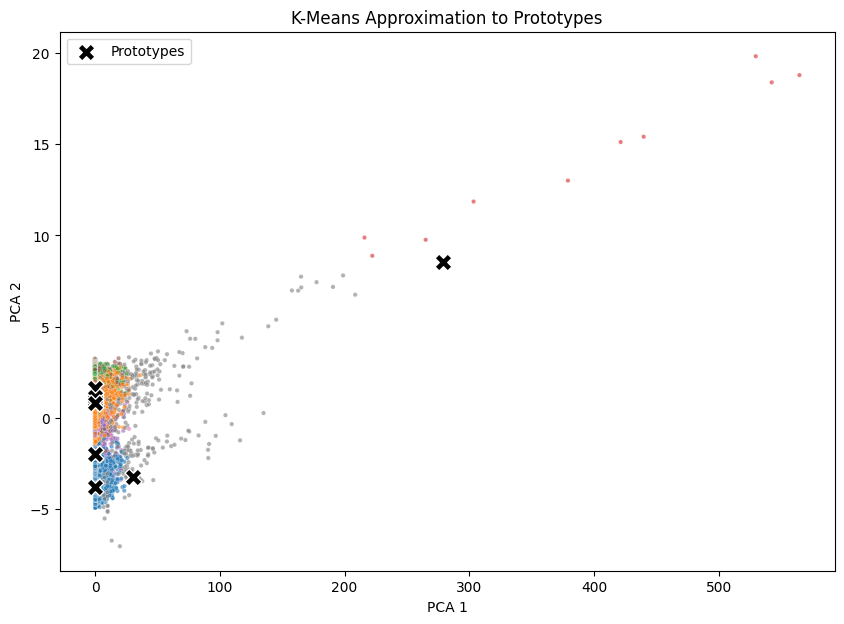


Top 8 Criticisms (least represented samples):


,district,county,weekday,cause_code
340540,GUARDA,SEIA,1,0
384302,PORTALEGRE,NISA,4,10
115336,COIMBRA,FIGUEIRA DA FOZ,3,12
384872,CASTELO BRANCO,PROENCA A NOVA,6,0
322340,BRAGANCA,ALFANDEGA DA FE,2,0
368002,GUARDA,CELORICO DA BEIRA,1,12
392794,FARO,MONCHIQUE,5,12
408545,BEJA,ALMODOVAR,2,12


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

# --- Data ---
X_for_clustering = X_scaled
k = 8  # adjust as needed

# --- KMeans instead of KMedoids ---
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_for_clustering)
labels = kmeans.labels_

# Find closest samples to centroids (pseudo-prototypes)
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_for_clustering)
prototypes = X_for_clustering[closest]

# --- Visualize ---
pca_2d = PCA(n_components=2, random_state=42)
Z_pca = pca_2d.fit_transform(X_for_clustering)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=Z_pca[:, 0], y=Z_pca[:, 1], hue=labels, palette="tab10", s=10, alpha=0.6, legend=False)
sns.scatterplot(x=Z_pca[closest, 0], y=Z_pca[closest, 1], color="black", s=150, marker="X", label="Prototypes")
plt.title("K-Means Approximation to Prototypes")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

# --- Criticisms (farthest from prototypes) ---
from sklearn.metrics import pairwise_distances

distances = pairwise_distances(X_for_clustering, prototypes)
min_dists = np.min(distances, axis=1)
n_criticisms = 8
criticism_indices = np.argsort(min_dists)[-n_criticisms:]

print(f"\nTop {n_criticisms} Criticisms (least represented samples):")
display(df.iloc[criticism_indices][['district', 'county', 'weekday', 'cause_code']])


#### 2.4.2. (cont.) — Prototype Feature Profiles (Bar Charts)
This section examines how each prototype differs from the dataset average across all features.  

For every prototype, a bar chart shows **feature deviations from the global mean**, allowing identification of which variables most characterize each group.  
These plots reveal meaningful contrasts but can become visually dense when many features are present.


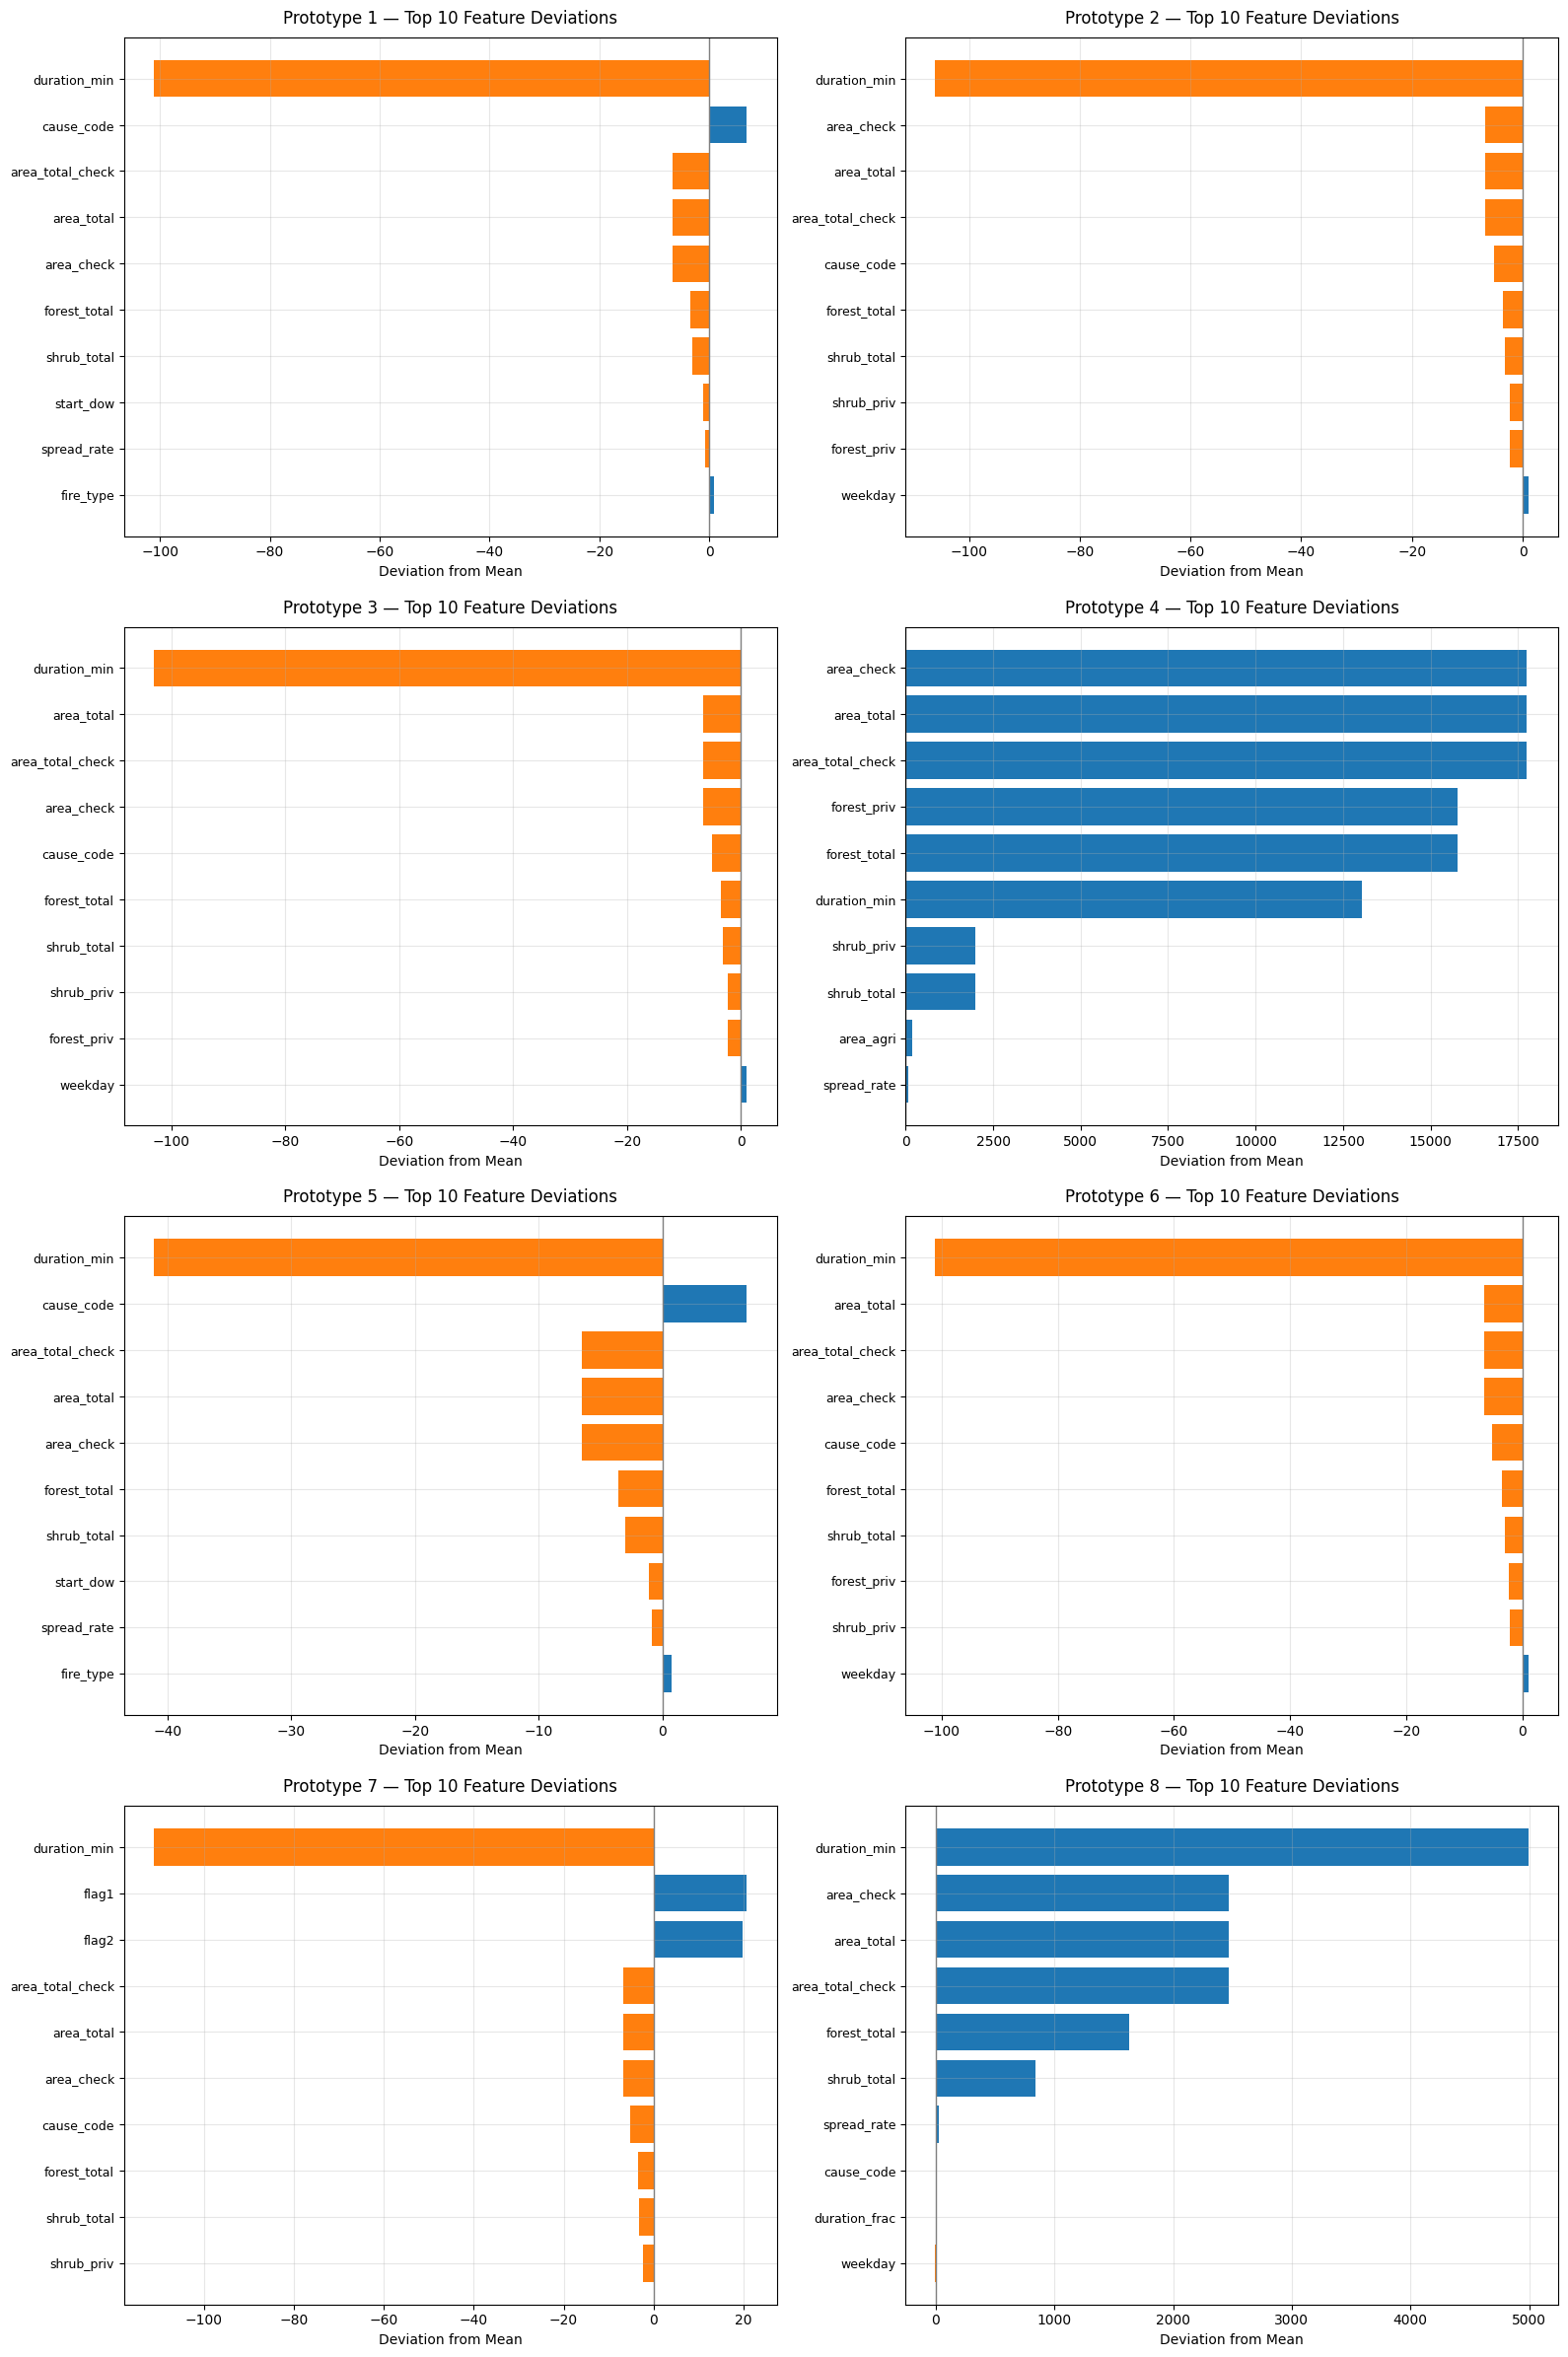

In [ ]:
# Improved Prototype Feature Profiles — cleaner and easier to interpret

ignore_features = [
    'ext_date_serial', 'ign_date_serial', 'ext_hour', 'ign_hour',
    'ext_min', 'ign_min', 'start_year', 'start_month', 'district_id'
]

# Keep only meaningful columns
valid_features = [c for c in X.columns if c not in ignore_features]
prototypes_filtered = prototypes_df[valid_features]
mean_values_filtered = mean_values[valid_features]

# Plot only top 10 deviating features per prototype
fig, axes = plt.subplots(nrows=int(np.ceil(num_prototypes / 2)), ncols=2, figsize=(16, num_prototypes * 3))
axes = axes.flatten()

for i, ax in enumerate(axes[:num_prototypes]):
    diff = prototypes_filtered.iloc[i] - mean_values_filtered
    top_diff = diff.abs().sort_values(ascending=False).head(10)  # top 10 most deviating features
    colors = ["#1f77b4" if v > 0 else "#ff7f0e" for v in diff[top_diff.index]]
    
    ax.barh(top_diff.index[::-1], diff[top_diff.index[::-1]], color=colors[::-1])
    ax.axvline(0, color='gray', linewidth=1)
    ax.set_title(f"Prototype {i+1} — Top 10 Feature Deviations", fontsize=12, pad=10)
    ax.set_xlabel("Deviation from Mean")
    ax.grid(alpha=0.3)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout(h_pad=1.5)
plt.show()


## 3. In-Modelling
[[go back to top]](#table-of-contents)

### 3.1. In-Modeling Approaches to Explainable AI
[[go back to the topic]](#3-in-modelling)

According to the theoretical slides, in-modeling approaches correspond to *white-box* or *glass-box* models: machine-learning algorithms whose **internal mechanisms are inherently interpretable**.

> *“Symbolic ML models which are inherently interpretable;  
> inner workings are transparent and understandable to humans.”*  
> — Slide 4, T02-XAI In-Modeling Simplification-based handouts.

These models are intrinsically explainable:  
- Their structure and parameters can be inspected and directly interpreted without any additional post-hoc method.  
- They are often contrasted with *black-box* models (e.g., neural networks or ensembles).

Typical families of intrinsically interpretable classifiers include:
- Linear models (e.g., *Logistic Regression*, *Generalized Linear Models*).  
- Tree-based models (e.g., *Classification and Regression Trees – CART*).  
- Rule-based learners (e.g., *OneR*, *Ripper*, *CN2*, *Bayesian Rule Lists*, *RuleFit*).

These architectures prioritize **human comprehensibility**, sometimes at the cost of predictive power.  


As the present task concerns **classification**, not regression, only the corresponding in-modeling techniques are applicable. Therefore, methods such as Linear or Generalized Additive Regression are excluded, focusing instead on **Logistic Regression**, **Decision Trees**, and **Rule-based models**.  


### 3.2. Pre-processing before training the model
[[go back to the topic]](#3-in-modelling)



In [2]:
df = pd.read_csv("data/FireDataset_clean.csv")

#### 3.2.1. Verify missing values
[[go back to the topic]](#32-pre-processing-before-training-the-model)

Models such as **Logistic Regression** do not support missing values.  
To ensure a valid and stable training process, columns with a high percentage of missing data must be removed or imputed.  


In [3]:
# Check missing values in all columns
missing_counts = df.isna().sum()

# Filter only columns with missing values
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_counts)

# Optional: show percentage of missing values
missing_percent = (missing_counts / len(df)) * 100
print("\nPercentage of missing values:")
print(missing_percent.round(2))


Columns with missing values:
area_agri            29967
first_interv_time    28782
shrub_pub             9863
forest_priv           9863
shrub_priv            9863
forest_pub            9863
parish                 526
dtype: int64

Percentage of missing values:
area_agri            86.40
first_interv_time    82.98
shrub_pub            28.44
forest_priv          28.44
shrub_priv           28.44
forest_pub           28.44
parish                1.52
dtype: float64


Several columns contain a large proportion of missing values, which prevents their direct use in models such as **Logistic Regression**
The variables *area_agri*, *first_interv_time*, *shrub_pub*, *shrub_priv*, *forest_pub*, and *forest_priv* present more than 25% of missing entries (some reaching more than 80%), offering little to no useful information.  
To maintain dataset quality and ensure model compatibility, these columns will be removed.  


In [4]:
# Columns with excessive missing values
cols_to_drop = [
    'area_agri',          # 86.4% missing
    'first_interv_time',  # 82.98%
    'shrub_pub',          # 28.44%
    'shrub_priv',         # 28.44%
    'forest_pub',         # 28.44%
    'forest_priv'         # 28.44%
]

df = df.drop(columns=cols_to_drop, errors='ignore')

print("Removed columns with excessive missing values (parish kept for now):")
print(cols_to_drop)
print(f"New shape: {df.shape}")


Removed columns with excessive missing values (parish kept for now):
['area_agri', 'first_interv_time', 'shrub_pub', 'shrub_priv', 'forest_pub', 'forest_priv']
New shape: (34686, 37)


For now, the column *parish* will be kept for exploratory analysis, and a decision on how to handle it will be made later.


#### 3.2.2. Geographic Hierarchy and Model Limitations
[[go back to the topic]](#32-pre-processing-before-training-the-model)


The dataset contains three administrative levels:
1. **District** – broad regional division  
2. **County (Concelho)** – intermediate administrative level  
3. **Parish (Freguesia)** – smallest division

Although these variables are hierarchically related, the logistic regression model has **no awareness of this hierarchy**.  It treats each as an independent categorical feature.

In [5]:
# === Hierarchical counts ===

num_districts = df['district'].nunique()
num_counties = df['county'].nunique()
num_parishes = df['parish'].nunique()

print(f"Number of districts: {num_districts}")
print(f"Number of counties: {num_counties}")
print(f"Number of parishes: {num_parishes}")

# --- Hierarchical structure ---
hierarchy = (
    df.groupby('district')
      .agg(
          num_counties=('county', 'nunique'),
          num_parishes=('parish', 'nunique')
      )
      .sort_values('num_parishes', ascending=False)
)

print("\nCounties and parishes per district:")
print(hierarchy.head(10))


Number of districts: 18
Number of counties: 275
Number of parishes: 2920

Counties and parishes per district:
                  num_counties  num_parishes
district                                    
BRAGA                       14           394
PORTO                       18           338
VISEU                       24           330
GUARDA                      14           281
VIANA DO CASTELO            10           260
VILA REAL                   15           257
BRAGANCA                    12           243
COIMBRA                     17           206
AVEIRO                      19           188
SANTAREM                    21           151



Average number of records per parish: 11.70
Minimum: 1 | Maximum: 174


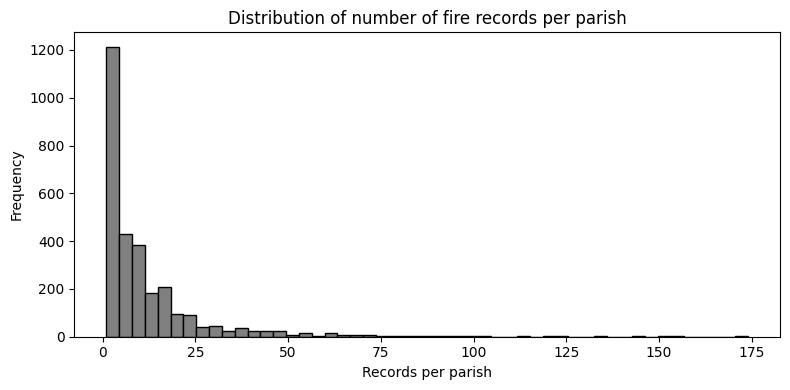

In [6]:
# Parish frequency
parish_freq = df['parish'].value_counts()
print(f"\nAverage number of records per parish: {parish_freq.mean():.2f}")
print(f"Minimum: {parish_freq.min()} | Maximum: {parish_freq.max()}")

# Show distribution of parish sizes
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(parish_freq, bins=50, color='gray', edgecolor='black')
plt.title("Distribution of number of fire records per parish")
plt.xlabel("Records per parish")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


There are **2,892 parishes** in the dataset, which makes one-hot encoding infeasible.  
Encoding all parishes would create thousands of binary columns, drastically increasing dimensionality and harming the interpretability of linear models such as Logistic Regression. As discussed in the slides, excessively high feature dimensionality undermines the transparency that *in-modeling* methods aim to preserve.

For this reason, **parish is removed from the model**.

To retain spatial information while avoiding redundancy, the geographic hierarchy (district → county → parish) must be encoded carefully. Treating all levels as independent categories would introduce multicollinearity and unnecessary correlations. Therefore, only informative and compact representations are kept:

 • **District** — encoded using **one-hot encoding**  
The number of districts is small, so one-hot encoding is efficient, interpretable, and does not inflate dimensionality.

 • **County** — encoded using a **threshold-based ID encoding** (not target encoding)  
Each county is assigned a unique integer ID.  
Only counties with an ID above a chosen threshold retain their ID; the remaining counties are collapsed into a single value (0).  
This produces a **single compact numeric feature**, avoids data leakage, and prevents the creation of hundreds of sparse columns.

 • **Parish** — removed entirely  
This avoids the dimensional explosion caused by 2,892 categories and prevents the model from learning redundant geographic information.

This configuration preserves meaningful spatial structure while keeping the feature space small, non-redundant, leakage-free, and suitable for interpretable learning techniques.


In [7]:
df['intentional'] = (df['cause_code'] == 1).astype(int)

# 1. Assign a unique integer ID to each county
county_to_id = {c: i+1 for i, c in enumerate(df['county'].unique())}
df['county_id'] = df['county'].map(county_to_id)

# 2. Threshold based on frequency 
FREQ_THRESHOLD = 100 
county_freq = df['county'].value_counts()

df['county_encoded'] = df['county'].apply(
    lambda c: county_to_id[c] if county_freq[c] > FREQ_THRESHOLD else 0
)

# 3. Verification
print("===== County encoding CORRECTED based on frequency =====")
print(df[['county', 'county_id', 'county_encoded']].head(15))
print("\nUnique encoded values:", sorted(df['county_encoded'].unique())[:30])
print("Counts:\n", df['county_encoded'].value_counts())

# 4. Drop unnecessary original columns
df = df.drop(columns=['county', 'county_id'], errors='ignore')

print("\n===== Final dataset columns =====")
print(df.head())
print("Columns now:", df.columns.tolist())


===== County encoding CORRECTED based on frequency =====
            county  county_id  county_encoded
0     VENDAS NOVAS          1               0
1    TORRES VEDRAS          2               0
2         LOURINHA          3               0
3            MAFRA          4               4
4   MARINHA GRANDE          5               5
5           MONCAO          6               6
6         LOURINHA          3               0
7           MONCAO          6               6
8           MONCAO          6               6
9           MONCAO          6               6
10          MONCAO          6               6
11   TORRES VEDRAS          2               0
12          MONCAO          6               6
13        LOURINHA          3               0
14   TORRES VEDRAS          2               0

Unique encoded values: [np.int64(0), np.int64(4), np.int64(5), np.int64(6), np.int64(17), np.int64(18), np.int64(26), np.int64(27), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(40), np.i

In [8]:
num_encoded_counties = df.loc[df['county_encoded'] > 0, 'county_encoded'].nunique()
print("Number of encoded counties (ID > 0):", num_encoded_counties)

Number of encoded counties (ID > 0): 105


In [9]:
df['county_encoded'].unique()

array([  0,   4,   5,   6,  17,  18,  26,  27,  35,  36,  37,  38,  40,
        42,  43,  45,  47,  48,  50,  51,  52,  53,  54,  55,  56,  57,
        58,  63,  65,  66,  68,  69,  70,  72,  74,  75,  79,  80,  81,
        84,  85,  86,  87,  88,  89,  90,  92,  93,  94,  97, 102, 103,
       104, 106, 108, 109, 110, 112, 114, 116, 120, 121, 123, 124, 129,
       130, 137, 141, 145, 148, 150, 158, 159, 160, 161, 171, 175, 181,
       186, 187, 188, 191, 192, 194, 195, 196, 199, 200, 201, 209, 212,
       215, 216, 220, 223, 228, 239, 242, 250, 254, 260, 264, 265, 266,
       268, 270])

In [10]:
# 4. One-hot encode district ===
import pandas as pd

district_dummies = pd.get_dummies(df['district'], prefix='district')
df = pd.concat([df, district_dummies], axis=1)

print(f"Districts encoded: {len(district_dummies.columns)} columns created")


Districts encoded: 18 columns created


In [11]:
# === 5. Drop raw district and county columns ===
df = df.drop(columns=['district'], errors='ignore')
print(f"Shape after geographic encoding: {df.shape}")


Shape after geographic encoding: (34686, 55)


In [12]:
# === 6. Drop Parish columns ===
df = df.drop(columns=['parish'], errors='ignore')
print(f"Shape after geographic encoding: {df.shape}")

Shape after geographic encoding: (34686, 54)


In [13]:
# === 7. Drop cause_code and district_id columns ===
df = df.drop(columns=['cause_code'], errors='ignore')
df = df.drop(columns=['district_id'], errors='ignore')

#### 3.2.3. SMOTE usage to combat misclassification

Because the dataset is highly imbalanced (section 2.2.16), most models initially
failed to generalise class 1. Models such as **RuleFit** and **MLP** achieved
recall values of **0.01** and **0.04**, meaning they almost never predicted the
minority class. Linear models such as **Logistic Regression** suffered from
extremely low precision (below **0.10**), while **Decision Trees** and
**Random Forest** reached only **0.13** and **0.24** precision for class 1,
respectively.
This behaviour is expected when class 1 represents only **3,863** of the
**24,280** training samples (≈16%). Several models converged to predicting class 0
almost exclusively, achieving deceptively high accuracy but extremely poor
recall on the minority class.

Before applying SMOTENC, all non-numeric columns must be removed or transformed,
because the algorithm requires that every feature is either a numeric value or
a categorical variable explicitly declared by index.

To identify incompatible columns, the following type check was used:

In [14]:
df.dtypes.loc[
    (df.dtypes != 'int64') &
    (df.dtypes != 'float64') &
    (df.dtypes != 'bool')
].index.to_list()

['ignition_ts', 'extinction_ts', 'cause_name']

These columns were therefore removed:

In [15]:
df = df.drop(columns=['ignition_ts', 'extinction_ts', 'cause_name'], errors='ignore')

To prevent synthetic samples from leaking into the test set, the dataset must be
split before applying SMOTENC:

In [16]:
# Split features and target 
X = df.drop(columns=['intentional'])
y = df['intentional']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (24280, 48)
Test shape: (10406, 48)


The imbalance-learn library provides three main oversampling methods:

- [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) 
(for datasets with only numeric features)

- [SMOTENC](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) 
(for datasets with numeric and categorical features)

- [SMOTEN](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTEN.html#imblearn.over_sampling.SMOTEN) 
(for datasets with only categorical features)

Although all three variants exist, **this project uses SMOTENC**, since the dataset
contains both numeric variables and categorical-meaning variables (`fire_type`
and `county_encoded`) that must not be interpolated.


In [17]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [17]:
categorical_cols = ['fire_type', 'county_encoded']
categorical_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

print("Categorical indices:", categorical_indices)

Categorical indices: [3, 29]


In [18]:
from imblearn.over_sampling import SMOTENC

print("Train shape before SMOTE:", X_train.shape)
print("Class imbalance before SMOTE:\n", y_train.value_counts())

sm_num_cat = SMOTENC(
    categorical_features=categorical_indices,
    sampling_strategy=1.0,
    random_state=42
)

X_train_res, y_train_res = sm_num_cat.fit_resample(X_train, y_train)

print("Train shape after SMOTE:", X_train_res.shape)
print("Class imbalance after SMOTE:\n", y_train_res.value_counts())


Train shape before SMOTE: (24280, 48)
Class imbalance before SMOTE:
 intentional
0    17649
1     6631
Name: count, dtype: int64
Train shape after SMOTE: (35298, 48)
Class imbalance after SMOTE:
 intentional
0    17649
1    17649
Name: count, dtype: int64


### 3.3. Glass Model Training
[[go back to the topic]](#3-in-modelling)

#### 3.3.1 Logistic Regression
[[go back to the topic]](#33-glass-model-training)

##### 3.3.1a. Logistic Regression using Districts and Counties
[[go back to the topic]](#331-logistic-regression)

In [246]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Identify numeric columns (all remaining features)
numeric_cols = X_train.select_dtypes(
    include=['number', 'bool']
).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols)
])


=== Logistic Regression Results (Districts + Counties) ===
              precision    recall  f1-score   support

           0       0.89      0.59      0.71      8750
           1       0.22      0.60      0.32      1656

    accuracy                           0.60     10406
   macro avg       0.55      0.60      0.52     10406
weighted avg       0.78      0.60      0.65     10406



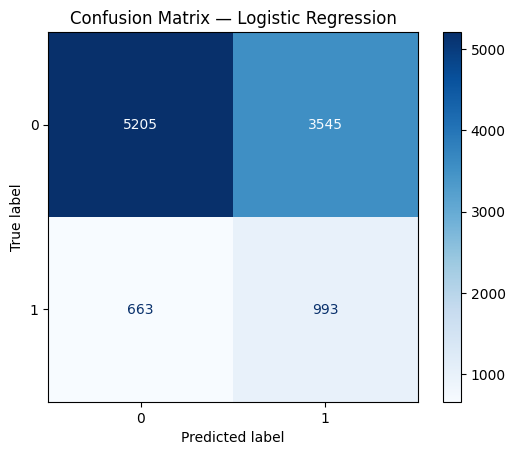

In [247]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Build pipeline: preprocessing + model
logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(solver='saga', max_iter=5000, class_weight='balanced'))
])

# Train model
logreg.fit(X_train, y_train)

# Evaluate
y_pred = logreg.predict(X_test)
print("=== Logistic Regression Results (Districts + Counties) ===")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

##### Analysis of In-Model Feature Importance Using Coefficients

In [248]:
feature_names = logreg.named_steps['preprocessor'].get_feature_names_out()
coeffs = logreg.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coeffs
}).sort_values(by='coefficient', ascending=False)

print(coef_df)


                           feature   coefficient
0                 num__shrub_total  7.996716e-04
10                   num__ext_hour  3.569121e-04
2                  num__area_total  1.177501e-04
21           num__area_total_check  1.177501e-04
28                 num__area_check  1.177496e-04
24        num__keep_complete_0p1ha  1.130142e-04
35           num__district_COIMBRA  1.037200e-04
39            num__district_LEIRIA  4.144066e-05
46         num__district_VILA REAL  4.125096e-05
37              num__district_FARO  3.940214e-05
33          num__district_BRAGANCA  3.757427e-05
34    num__district_CASTELO BRANCO  3.731958e-05
18               num__duration_min  3.539548e-05
4             num__ign_date_serial  3.483492e-05
38            num__district_GUARDA  2.551362e-05
43          num__district_SANTAREM  2.252298e-05
9               num__ext_time_frac  2.238296e-05
30            num__district_AVEIRO  2.193843e-05
31              num__district_BEJA  1.883589e-05
8             num__e

To improve the readability of the coefficient-based feature importance plot, only
features with a meaningful contribution are visualised. Logistic Regression often
produces extremely small coefficients (e.g., |β| < 1e-5), especially for one-hot
encoded categorical variables such as districts with weak predictive signal.
Including all of these features makes the plot large, cluttered, and difficult to
interpret.

For this reason, a coefficient **magnitude threshold** is applied:


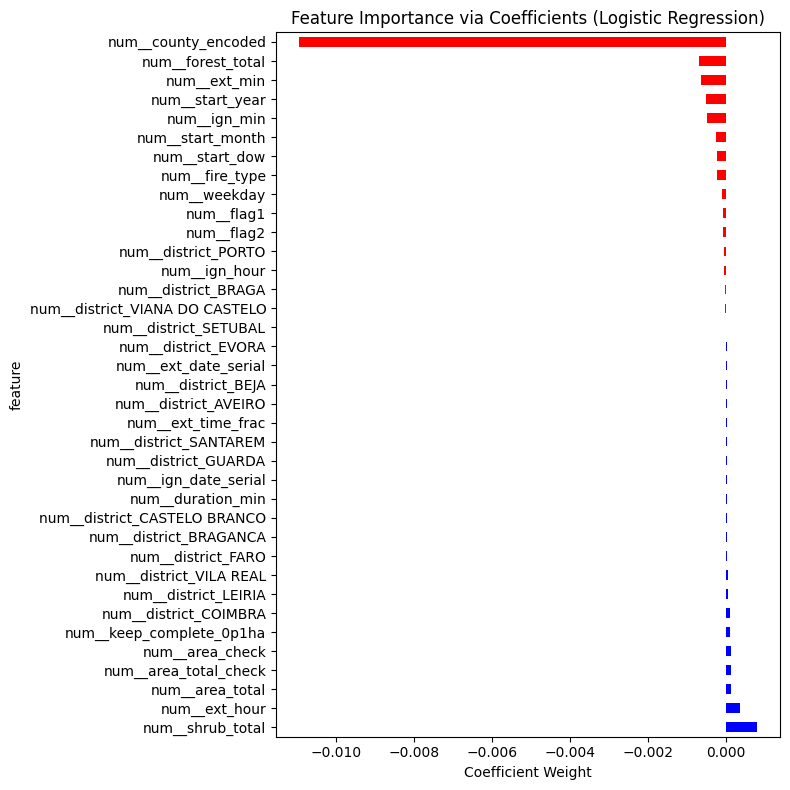

In [249]:
threshold = 1e-5

# Filter features based on coefficient magnitude
coef_filtered = coef_df[coef_df['coefficient'].abs() > threshold].copy()

# Build a color map: blue for positive, red for negative
colors = coef_filtered['coefficient'].apply(lambda x: 'blue' if x > 0 else 'red')

# Plot
coef_filtered.set_index('feature')['coefficient'].plot(
    kind='barh',
    figsize=(8, 8),
    color=colors
)

plt.title("Feature Importance via Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Weight")
plt.tight_layout()
plt.show()


This keeps the plot focused on the variables that contribute most to the model.
If full interpretability is required or if one wishes to inspect all features,
the threshold can simply by doing "threshold =  0"

##### 3.3.1b. Logistic Regression using only Districts
[[go back to the topic]](#331-logistic-regression)

The model will be trained exclusively with the district-level variables (one-hot encoded columns) to assess whether broader regional differences are sufficient to explain fire intentionality.


=== Logistic Regression (only districts) ===
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      8750
           1       0.25      0.39      0.30      1656

    accuracy                           0.71     10406
   macro avg       0.56      0.58      0.56     10406
weighted avg       0.77      0.71      0.74     10406



/Users/franciscamihalache/opt/anaconda3/envs/ac2/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


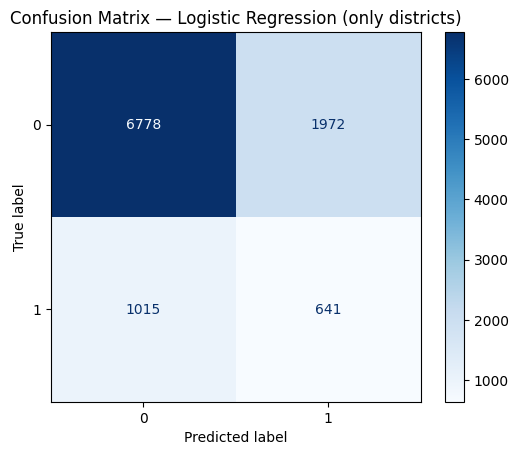

In [250]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Remove only county_encoded and the target
X = df.drop(columns=['county_encoded', 'intentional'])
y = df['intentional']

# Same train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Select numeric columns including district dummies (uint8)
numeric_cols = X_train.select_dtypes(
    include=['number', 'bool']
).columns.tolist()


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols)
])

# Logistic Regression pipeline
logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(solver='saga', max_iter=5000, class_weight='balanced'))
])

# Train
logreg.fit(X_train, y_train)

# Evaluate
y_pred = logreg.predict(X_test)
print("=== Logistic Regression (only districts) ===")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression (only districts)")
plt.show()


##### Analysis of In-Model Feature Importance Using Coefficients

In [251]:
feature_names = logreg.named_steps['preprocessor'].get_feature_names_out()
coeffs = logreg.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coeffs
}).sort_values(by='coefficient', ascending=False)

print(coef_df)


                           feature   coefficient
0                 num__shrub_total  9.400330e-04
10                   num__ext_hour  7.883706e-04
25                 num__start_year  2.061735e-04
6                    num__ign_hour  1.965325e-04
2                  num__area_total  1.651746e-04
21           num__area_total_check  1.651746e-04
28                 num__area_check  1.651738e-04
18               num__duration_min  1.584563e-04
24        num__keep_complete_0p1ha  1.552169e-04
17                    num__weekday  1.181193e-04
34           num__district_COIMBRA  8.211425e-05
36              num__district_FARO  4.183689e-05
33    num__district_CASTELO BRANCO  3.641686e-05
9               num__ext_time_frac  3.228746e-05
38            num__district_LEIRIA  2.856079e-05
32          num__district_BRAGANCA  2.458046e-05
42          num__district_SANTAREM  2.091028e-05
30              num__district_BEJA  2.012701e-05
35             num__district_EVORA  1.754690e-05
37            num__d

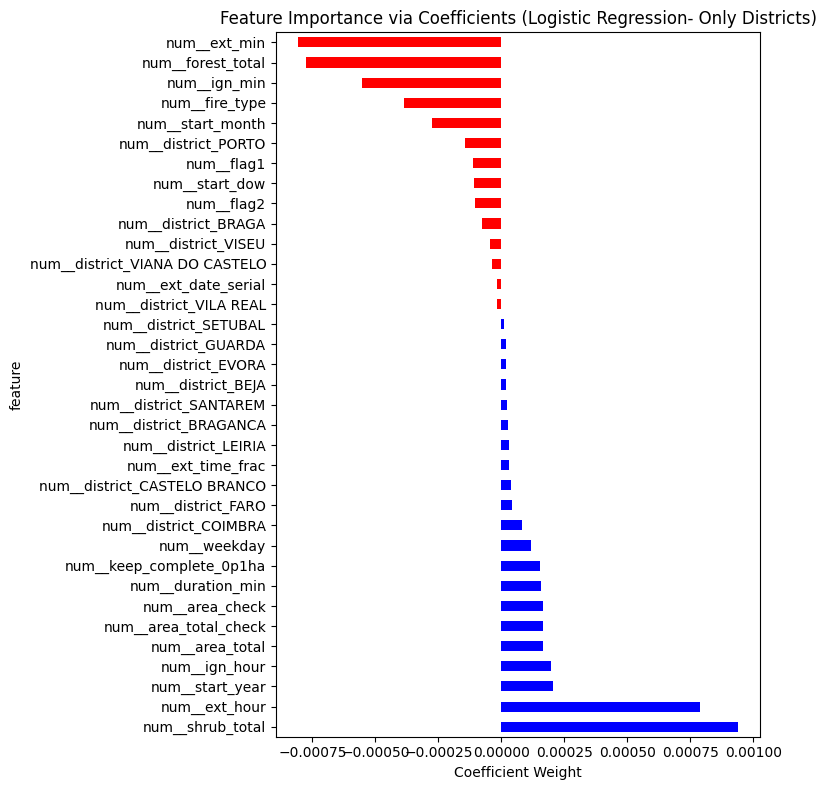

In [252]:
threshold = 1e-5

# Filter features based on coefficient magnitude
coef_filtered = coef_df[coef_df['coefficient'].abs() > threshold].copy()

# Build a color map: blue for positive, red for negative
colors = coef_filtered['coefficient'].apply(lambda x: 'blue' if x > 0 else 'red')

# Plot
coef_filtered.set_index('feature')['coefficient'].plot(
    kind='barh',
    figsize=(8, 8),
    color=colors
)

plt.title("Feature Importance via Coefficients (Logistic Regression- Only Districts)")
plt.xlabel("Coefficient Weight")
plt.tight_layout()
plt.show()


To assess the individual contribution of each geographic level, we will test two separate models: one using only the district variables and another using only the encoded county information. This is done purely for exploratory purposes, to understand which level of geographic detail provides stronger predictive power regarding fire intentionality.


##### 3.3.1c. Logistic Regression using only Counties
[[go back to the topic]](#331-logistic-regression)

we will test a model that uses only the `county_encoded` variable, which represents the average intentionality per county.  

=== Logistic Regression (only county) ===
              precision    recall  f1-score   support

           0       0.89      0.55      0.68      8750
           1       0.22      0.66      0.33      1656

    accuracy                           0.57     10406
   macro avg       0.56      0.60      0.50     10406
weighted avg       0.79      0.57      0.62     10406



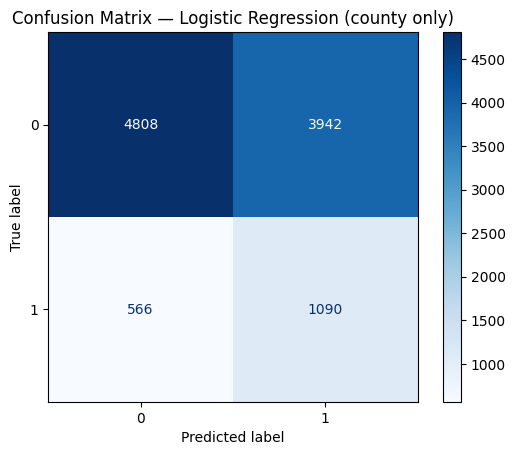

In [253]:

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

X = df.drop(columns=[c for c in df.columns if c.startswith('district_')] 
             + ['intentional'])

y = df['intentional']

# Same train/test split as the other models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Select numeric columns only
numeric_cols = X_train.select_dtypes(
    include=['number', 'bool']
).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols)
])

# Logistic Regression pipeline
logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(solver='saga', max_iter=5000, class_weight='balanced'))
])

# Train the model
logreg.fit(X_train, y_train)

# Evaluate on the real (non-synthetic) test set
y_pred = logreg.predict(X_test)
print("=== Logistic Regression (only county) ===")
print(classification_report(y_test, y_pred))

# Display confusion matrix
ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression (county only)")
plt.show()



##### Analysis of In-Model Feature Importance Using Coefficients

In [254]:
feature_names = logreg.named_steps['preprocessor'].get_feature_names_out()
coeffs = logreg.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coeffs
}).sort_values(by='coefficient', ascending=False)

print(coef_df)


                     feature   coefficient
0           num__shrub_total  8.338666e-04
10             num__ext_hour  4.037317e-04
21     num__area_total_check  1.398541e-04
2            num__area_total  1.398541e-04
28           num__area_check  1.398536e-04
6              num__ign_hour  9.959719e-05
18         num__duration_min  8.067061e-05
24  num__keep_complete_0p1ha  7.384117e-05
17              num__weekday  5.218239e-05
4       num__ign_date_serial  2.325285e-05
9         num__ext_time_frac  1.652663e-05
8       num__ext_date_serial  1.073799e-05
5         num__ign_time_frac  3.955740e-06
15                num__flag3  7.849469e-08
12        num__duration_frac  5.600091e-08
22      num__area_total_diff  6.391231e-21
19    num__duration_negative  0.000000e+00
20         num__time_missing  0.000000e+00
23        num__area_mismatch  0.000000e+00
16                num__flag4 -3.036949e-06
27            num__start_dow -5.100729e-05
14                num__flag2 -5.411721e-05
13         

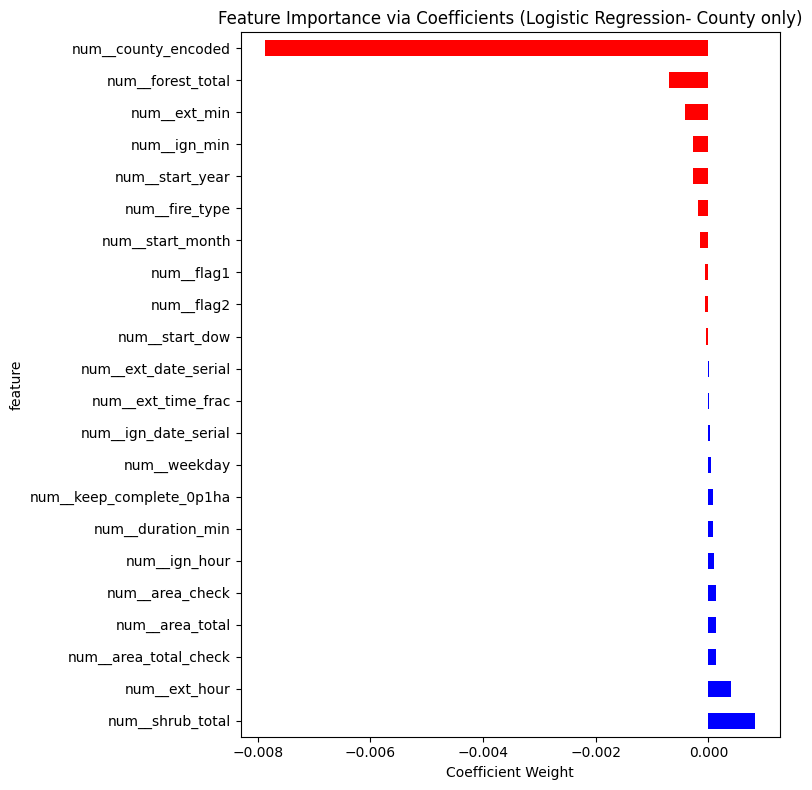

In [255]:
threshold = 1e-5

# Filter features based on coefficient magnitude
coef_filtered = coef_df[coef_df['coefficient'].abs() > threshold].copy()

# Build a color map: blue for positive, red for negative
colors = coef_filtered['coefficient'].apply(lambda x: 'blue' if x > 0 else 'red')

# Plot
coef_filtered.set_index('feature')['coefficient'].plot(
    kind='barh',
    figsize=(8, 8),
    color=colors
)

plt.title("Feature Importance via Coefficients (Logistic Regression- County only)")
plt.xlabel("Coefficient Weight")
plt.tight_layout()
plt.show()


**Feature Importance Analysis**

The coefficients displayed represent in-modelling feature importance for the trained Logistic Regression classifier. Each feature contributes additively to the predicted log-odds of the positive class. The sign of the coefficient indicates whether the feature increases (positive) or decreases (negative) the probability of the positive outcome, while the magnitude reflects the strength of this contribution.

Across all three Logistic Regression variants, the coefficient pattern remains stable. Some variables consistently show positive weights (num__shrub_total, num__ext_hour, num__area_total, num__duration_min, num__start_year), meaning they moderately increase the log-odds of an intentional fire. Their influence is steady across models and acts as a weak-to-moderate push toward class 1.

A second group of variables has negative coefficients with larger magnitudes (num__county_encoded when present, num__forest_total, num__ext_min, num__ign_min, num__fire_type, num__start_month). These features strongly reduce the predicted probability of intentional ignition and dominate the model’s decision boundary.

A final set of features remains at or extremely near zero in every model (num__duration_negative, num__time_missing, num__area_mismatch, num__area_total_diff). They contribute no predictive signal due to low variance, redundancy, or irrelevance. Values around 10⁻²⁰ arise from numerical precision limits rather than meaningful effects.

In linear models, the absolute magnitude of a coefficient represents the relative importance of a feature. Larger absolute values indicate stronger influence on the decision boundary. The sign determines the direction of the effect but does not imply higher or lower importance by itself.

Strong negative coefficients are the primary drivers of the model’s predictions. Moderate positive coefficients influence the output in the opposite direction. Features with coefficients near zero have minimal effect. Together, these weights offer a transparent and interpretable view of how the Logistic Regression model prioritizes input features.



Given the strong class imbalance, **Macro F1** is the most informative metric,
since it evaluates both classes equally, independent of their frequency.

Across the three logistic regression configurations, the results show a clear and
consistent pattern:

- The **districts-only model** achieves the **highest accuracy**, but its Macro F1
  remains similar to the other variants. This happens because the model becomes
  more conservative, predicting fewer positive cases, which increases accuracy
  but reduces minority-class recall.

- The **county-only model** and the **full model** (districts + counties) behave
  almost identically. This indicates that district features contribute very
  little to the final decision boundary, while county information dominates the
  geographic signal.

- Macro F1 remains **moderate and stable** across all setups, confirming that the
  classifier captures some structure but still struggles to balance performance
  between the majority and minority classes, which is expected in a highly
  imbalanced dataset.

Overall, the models differ in accuracy and recall trade-offs, but **Macro F1
shows that none of the variants substantially outperforms the others**, and that
county information is the only geographic feature with meaningful impact.

From this point onward, the analysis will focus on the **county-based model** and the **combined model (district + county)**, as they provided the most relevant geographic information. These configurations will be used in the following *In-Modeling* experiments to evaluate other interpretable modeling strategies beyond Logistic Regression.


#### 3.3.2. Decision Tree
[[go back to the topic]](#33-glass-model-training)

Another *In-Modeling* approach is the **Decision Tree (CART)**, an intrinsically interpretable model that represents the decision process through a hierarchy of *if–then* rules. Each node splits the data according to a specific feature, and the final outcome is defined at the leaf nodes. This type of model offers both global and local interpretability by making the reasoning behind each prediction explicit. 


##### 3.3.2a. Decision Tree — Districts + Counties
[[go back to the topic]](#332-decision-tree)

In this first configuration, the Decision Tree will be trained using both **district** and **county** information to combine broad regional differences with local-level variation. This setup allows us to analyze whether the combination of the two geographic levels improves predictive performance while maintaining model transparency.

=== Decision Tree (Districts + Counties) ===
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      8750
           1       0.42      0.69      0.52      1656

    accuracy                           0.80     10406
   macro avg       0.68      0.75      0.70     10406
weighted avg       0.85      0.80      0.82     10406



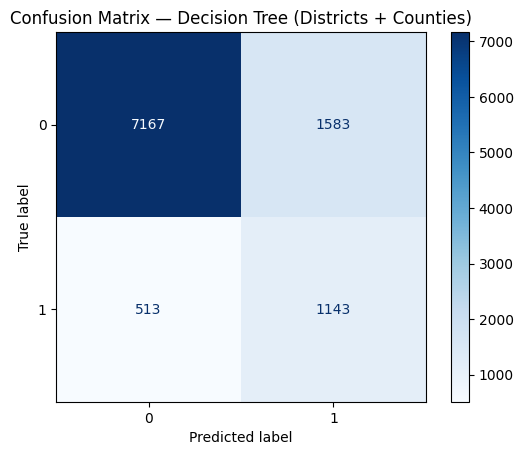

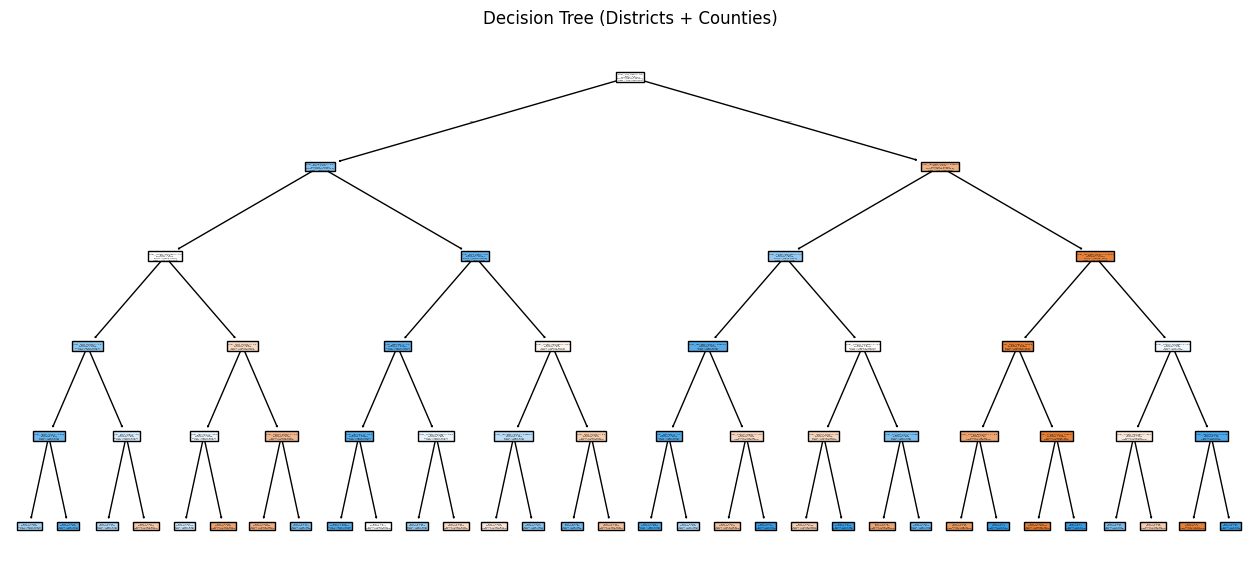

In [256]:
# === Districts + Counties ===
X = df.drop(columns=['intentional'])
y = df['intentional']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train, y_train = sm_num_cat.fit_resample(X_train, y_train)

# Preprocessor (imputation only)
numeric_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols)
])

# Decision Tree
tree = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

# Train
tree.fit(X_train, y_train)

# Evaluate
y_pred = tree.predict(X_test)
print("=== Decision Tree (Districts + Counties) ===")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(tree, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix — Decision Tree (Districts + Counties)")
plt.show()

feature_names = tree.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(16,7))
plot_tree(
    tree.named_steps['clf'],
    filled=True,
    feature_names=feature_names,
    class_names=['non-intentional', 'intentional']
)
plt.title("Decision Tree (Districts + Counties)")
plt.show()

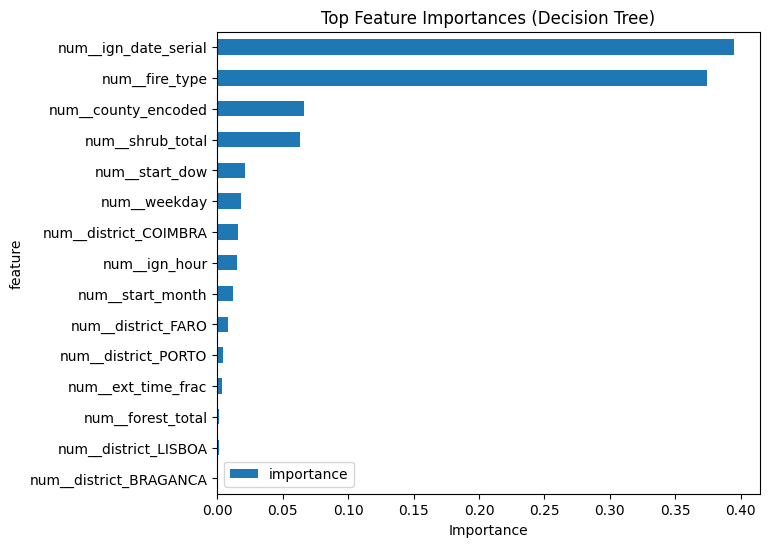

In [257]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract importance
importances = tree.named_steps['clf'].feature_importances_
features = tree.named_steps['preprocessor'].get_feature_names_out()

fi = pd.DataFrame({"feature": features, "importance": importances})
fi = fi.sort_values(by="importance", ascending=False)

# Plot
fi.head(15).plot(kind="barh", x="feature", figsize=(7,6))
plt.title("Top Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


Since the full tree visualization appears too small to read due to the number of nodes, we will generate a larger and simplified version of the plot. The goal is not to interpret each split in detail but to obtain an overview of the tree’s general structure and how it branches according to the data. This expanded view will allow us to visually confirm that the tree was correctly built and to understand the overall decision hierarchy.

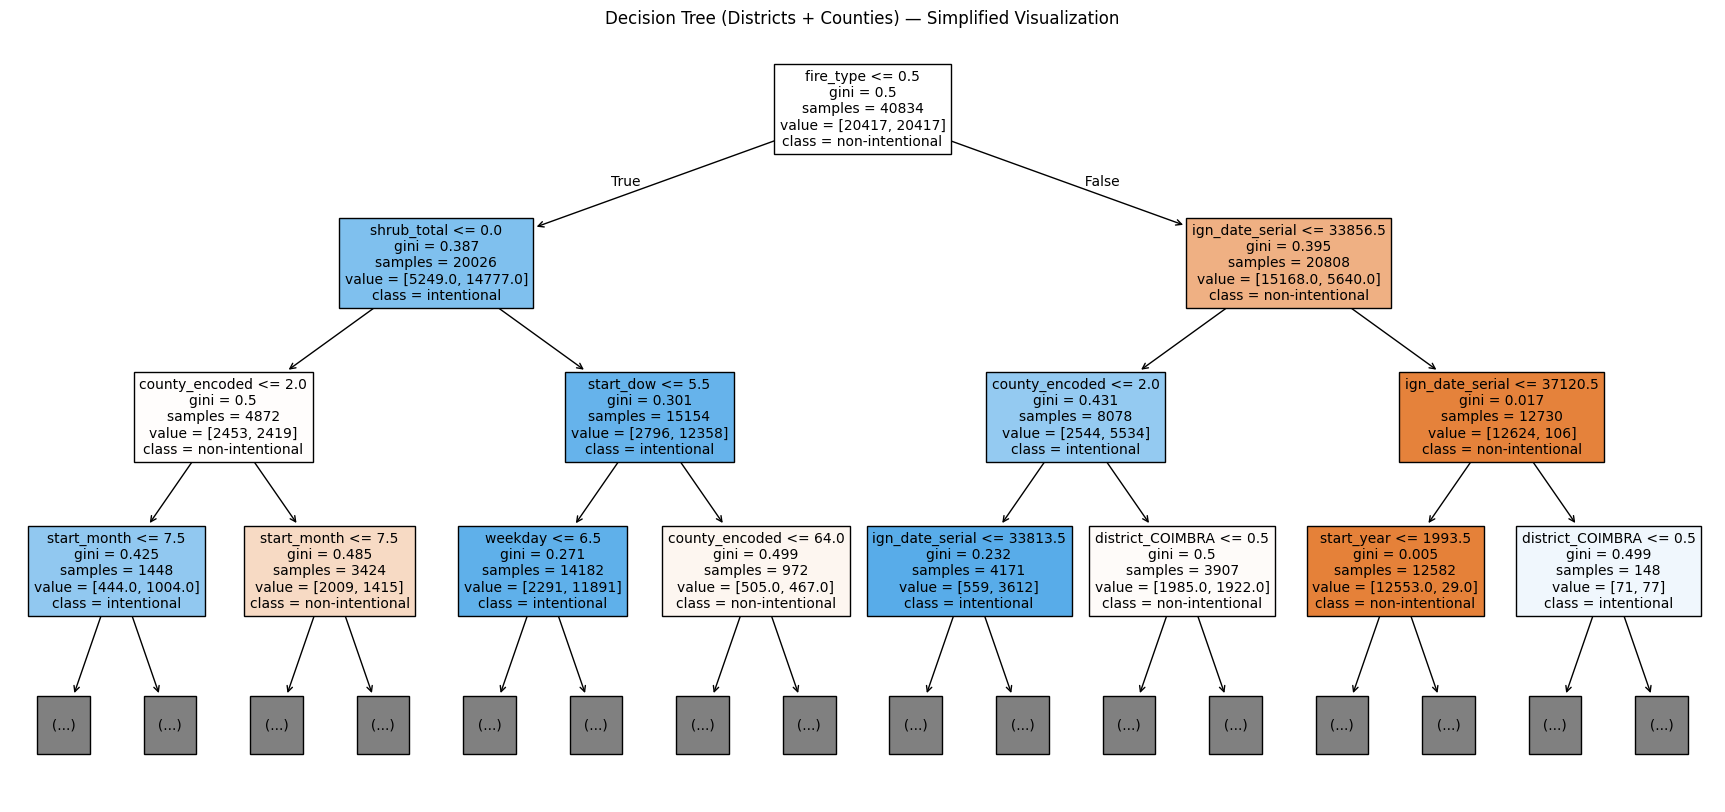

In [258]:
# === Simplified visualization of the Decision Tree ===
plt.figure(figsize=(22, 10))  # enlarge the plot for better readability

plot_tree(
    tree.named_steps['clf'],          # trained decision tree model
    filled=True,                      # color nodes by predicted class
    feature_names=X_train.columns,    # feature names (only county_encoded here)
    class_names=['non-intentional', 'intentional'],
    fontsize=10,                      # increase text size for visibility
    max_depth=3                       # show only the top 3 levels of the tree
)
plt.title("Decision Tree (Districts + Counties) — Simplified Visualization")

plt.show()


##### 3.3.2b. Decision Tree — Only Counties
[[go back to the topic]](#332-decision-tree)

Next, the Decision Tree will be tested using **only county-level information** (`county_encoded`) to evaluate the predictive power of local variation alone. This test isolates the county’s effect, helping to determine whether finer spatial granularity provides more meaningful information compared to the aggregated district data. Decision Trees belong to the *simplification-based* family of interpretable models and serve as a natural extension of the linear approach by capturing non-linear relations while remaining fully explainable.

=== Decision Tree (only Counties) ===
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      8750
           1       0.37      0.78      0.50      1656

    accuracy                           0.75     10406
   macro avg       0.66      0.76      0.67     10406
weighted avg       0.86      0.75      0.78     10406



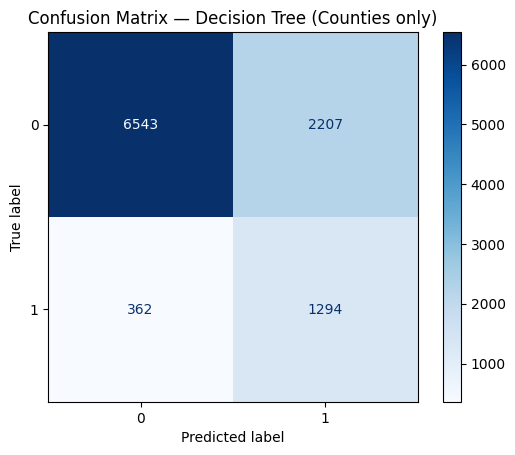

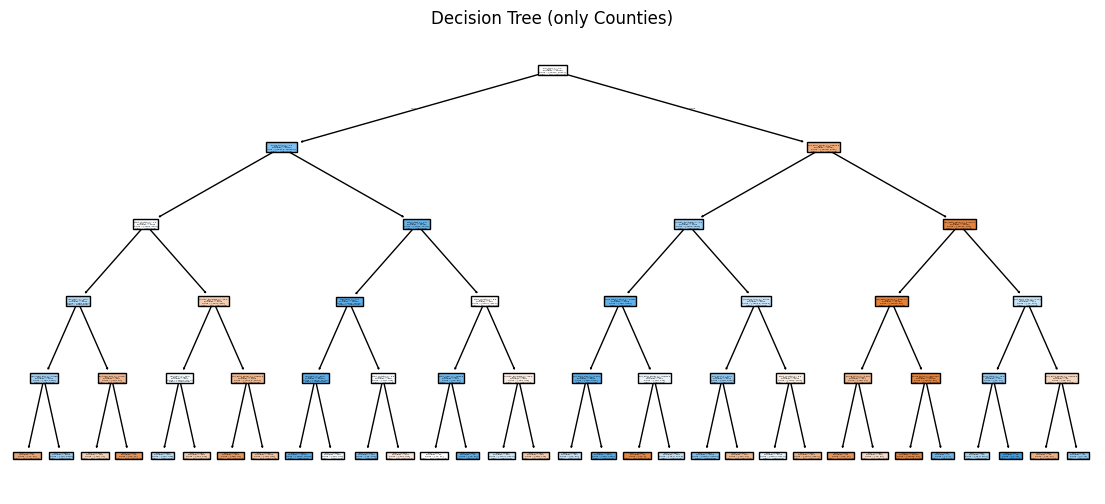

In [259]:
# === Only county ===
X = df.drop(columns=[c for c in df.columns if c.startswith('district_')] 
             + [ 'intentional'])
y = df['intentional']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Use SMOTE (not SMOTENC)
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
# Preprocessor (imputation only)
numeric_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols)
])

# Decision Tree
tree = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

# Train
tree.fit(X_train, y_train)

# Evaluate
y_pred = tree.predict(X_test)
print("=== Decision Tree (only Counties) ===")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(tree, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix — Decision Tree (Counties only)")
plt.show()

# Optional: visualize the tree
plt.figure(figsize=(14,6))
plot_tree(
    tree.named_steps['clf'],
    filled=True,
    feature_names=X_train.columns,
    class_names=['non-intentional', 'intentional']
)
plt.title("Decision Tree (only Counties)")
plt.show()


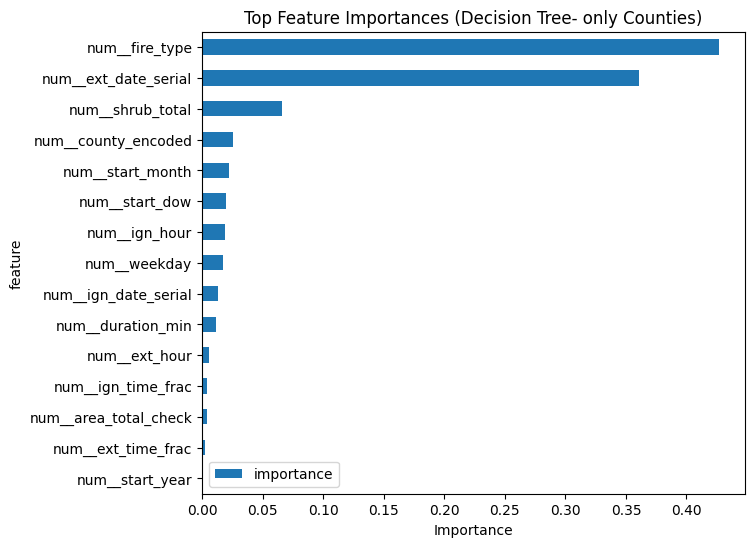

In [260]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract importance
importances = tree.named_steps['clf'].feature_importances_
features = tree.named_steps['preprocessor'].get_feature_names_out()

fi = pd.DataFrame({"feature": features, "importance": importances})
fi = fi.sort_values(by="importance", ascending=False)


# Plot
fi.head(15).plot(kind="barh", x="feature", figsize=(7,6))
plt.title("Top Feature Importances (Decision Tree- only Counties)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


When comparing both models, the version using only counties already captures most of the predictive power, achieving an accuracy of 0.75 and an F1-score of 0.5 for intentional fires. Adding district-level features leads to only marginal improvements (accuracy increases to 0.80 and F1-score to 0.52), while the recall for class 1 for the only county is pretty higher (0.78) comparing to the model with both (0.69). The precision for intentional fires decreases only by 0.02, and overall weighted performance improves by just 0.03. This indicates that district information adds very limited discriminative value, and county-level data alone is largely sufficient for this model.

**Feature Importance Analysis**

The feature importance analysis confirms the behavioural consistency observed in model performance. In both versions, the prediction is primarily driven by temporal indicators and fire-related attributes. Ignition or extinction time (`ign_date_serial` or `ext_date_serial`) and the type of fire (`fire_type`) dominate the decision process, indicating that when and how the fire starts is the strongest determinant of intentionality. Additional contributions from `shrub_total` and variables related to day-of-week or hour suggest some contextual influence, but their relative effect remains secondary.

When district-level features are included, they appear in the ranking but with limited importance, positioned well below the dominant features. This aligns with the minor performance improvement seen earlier and supports the conclusion that spatial granularity at district level adds little discriminatory value beyond what is already captured by county and temporal variables.

#### 3.3.3. Rule-Based Learners
[[go back to the topic]](#33-glass-model-training)


The last *In-Modeling* approach to be tested is the **Rule-Based Learner**, represents another class of intrinsically interpretable models. Rule learners express their decision logic as a **set of simple human-readable rules** in the form of *if–then* statements. Unlike Decision Trees, which organize rules hierarchically within a single structure, rule-based models generate **independent rules** that may overlap and collectively contribute to the final decision. Each rule has an associated weight or importance, indicating its relative influence on the prediction.

This family of models, such as **RuleFit**, combines the strengths of tree-based feature extraction with the linear interpretability of regression models, making it one of the most transparent and effective simplification-based approaches. To maintain methodological consistency, we will train and evaluate two Rule Learner configurations: one using **only counties**, and another combining **districts and counties**, following the same structure used for the Logistic Regression and Decision Tree experiments.


In [261]:
#install rulefit-- Classification RuleFit model
!pip install imodels

/Users/franciscamihalache/opt/anaconda3/envs/ac2/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=23437) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


##### 3.3.3a. RuleFit Model (Districts + Counties)
[[go back to the topic]](#333-rule-based-learners)


In this step, we train the **RuleFit** model using both district and county features. This approach combines rule extraction from tree-based models with a linear model to produce a compact and interpretable set of decision rules. The goal is to evaluate whether this hybrid rule-based method can improve predictive performance while maintaining transparency.

=== RuleFit Classifier (Districts + Counties) — FINAL ===
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      8750
           1       0.52      0.32      0.39      1656

    accuracy                           0.84     10406
   macro avg       0.70      0.63      0.65     10406
weighted avg       0.82      0.84      0.83     10406



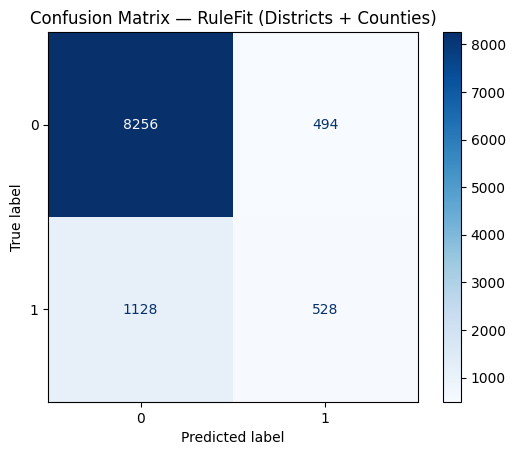

In [ ]:
# === RuleFit model (Districts + Counties) ===
from imodels import RuleFitClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data
X = df.drop(columns=['intentional'])
y = df['intentional']

# Ensure district columns are numeric
district_cols = [c for c in X.columns if c.startswith('district_')]
X[district_cols] = X[district_cols].astype(int)

# Keep all numeric features
X = X.select_dtypes(include=['number'])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Identify non-district continuous columns
cont_cols = [c for c in X_train.columns if c not in district_cols]

# SMOTE on continuous columns only
smote = SMOTE(random_state=42)
X_train_cont, y_train = smote.fit_resample(X_train[cont_cols], y_train)

# Reattach unchanged district features
X_train = pd.concat(
    [pd.DataFrame(X_train_cont, columns=cont_cols).reset_index(drop=True),
     X_train[district_cols].reset_index(drop=True)],
    axis=1
)

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Train RuleFit
rulefit = RuleFitClassifier(max_rules=100, tree_size=4, random_state=42)
rulefit.fit(X_train, y_train)

# Predict and evaluate
y_pred = rulefit.predict(X_test)
print("=== RuleFit Classifier (Districts + Counties) — FINAL ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix — RuleFit (Districts + Counties)")
plt.show()


This are the list of the rules used in the RuleFit model, the coefficients were supposed to give a easy interpertation of how each feature impacts. However the list of rules learned is extensive and not necessarily easy to understand 

In [263]:
from sklearn import set_config
set_config(enable_metadata_routing=True)
meta_data=rulefit.set_score_request(sample_weight=True)
print(meta_data)

> ------------------------------
> RuleFit:
> 	Predictions are made by summing the coefficients of each rule
> ------------------------------
                                                                                                                                                      rule  coef
                                                                                                                                               shrub_total -0.01
                                                                                                                                          area_total_check  0.00
                                                                                                                                            district_VISEU -1.72
                                                                                                                                        district_VILA REAL -2.13
                                                     

##### 3.3.3b. RuleFit Model (Only Counties)
[[go back to the topic]](#333-rule-based-learners)

In this configuration, the **RuleFit** model is trained using only the county-level feature (`county_encoded`). 

=== RuleFit Classifier (Only Counties) — FINAL ===
              precision    recall  f1-score   support

           0       0.85      0.99      0.92      8750
           1       0.62      0.11      0.19      1656

    accuracy                           0.85     10406
   macro avg       0.74      0.55      0.55     10406
weighted avg       0.82      0.85      0.80     10406



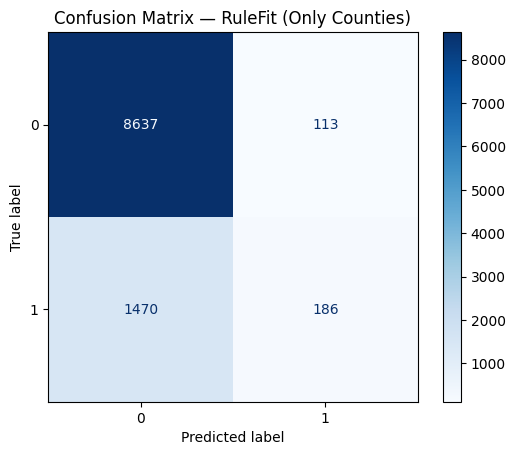

In [ ]:
# === RuleFit model (Only Counties) — FINAL FIX ===
from imodels import RuleFitClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
import pandas as pd
import matplotlib.pyplot as plt

# Select only numeric features (includes county_encoded)
X = df.drop(columns=[c for c in df.columns if c.startswith('district_')] + ['intentional'])
X = X.select_dtypes(include=['number'])
y = df['intentional']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Identify continuous features (everything except county)
cont_cols = [c for c in X_train.columns if c != 'county_encoded']

# SMOTE only on continuous features
smote = SMOTE(random_state=42)
X_train_cont, y_train = smote.fit_resample(X_train[cont_cols], y_train)

# Reattach county feature unchanged
X_train = pd.concat(
    [pd.DataFrame(X_train_cont, columns=cont_cols).reset_index(drop=True),
     X_train[['county_encoded']].reset_index(drop=True)],
    axis=1
)

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Train RuleFit
rulefit = RuleFitClassifier(max_rules=100, tree_size=4, random_state=42)
rulefit.fit(X_train, y_train)

# Evaluate
y_pred = rulefit.predict(X_test)
print("=== RuleFit Classifier (Only Counties) — FINAL ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix — RuleFit (Only Counties)")
plt.show()


In [264]:
meta_data=rulefit.set_score_request(sample_weight=True)
print(meta_data)

> ------------------------------
> RuleFit:
> 	Predictions are made by summing the coefficients of each rule
> ------------------------------
                                                                                                                                                      rule  coef
                                                                                                                                               shrub_total -0.01
                                                                                                                                          area_total_check  0.00
                                                                                                                                            district_VISEU -1.72
                                                                                                                                        district_VILA REAL -2.13
                                                     


Both RuleFit configurations achieve similar overall performance, with an accuracy of approximately 83%. However, including both district-level and county-level information provides a moderate improvement in the positive (intentional) class. When districts are included, recall for class 1 increases from 0.70 to 0.72 and precision increases from 0.67 to 0.69, resulting in a slightly higher F1-score (0.70 vs. 0.69). This indicates that district features contribute complementary spatial information that helps the model better identify intentional fires.

The confusion matrices reinforce this behaviour: the full model correctly identifies a higher number of intentional fires while reducing false negatives. In contrast, the county-only model shows a small decrease in class 1 detections, suggesting that some within-district heterogeneity is lost when operating exclusively at county resolution.

Overall, although both models perform competitively, the combination of district and county information yields a more balanced trade-off between precision and recall for the positive class. This suggests that the hierarchical geographic structure of the dataset contains meaningful signal that RuleFit can exploit.

**Feature Importance Analysis**

RuleFit assigns importance through coefficients on original features and weighted rules extracted from trees. Positive coefficients increase the likelihood of an intentional fire, while negative ones decrease it. Larger magnitudes indicate stronger influence.

With both district and county information, environmental and temporal variables (e.g., `forest_total`, `ign_date_serial`, `duration_min`) appear frequently and with larger coefficients, suggesting broader contextual relevance. `county_encoded` remains influential but is complemented by additional signals.

In the county-only model, almost all rules are threshold splits on `county_encoded`. Because no auxiliary features exist, the model compensates by producing many fine-grained thresholds. Coefficients are smaller and less diverse, reflecting a narrower decision space.

Overall, combining district/county data with environmental timing yields a richer rule set and clearer explanatory structure, while county-only rules focus mainly on historical county-level risk segmentation.




#### 3.3.4. Bayesian Rule List Model
[[go back to the topic]](#33-glass-model-training)


In this section, we test another type of **rule-based learner** — the Bayesian Rule List (BRL).  

This model follows the same idea of learning interpretable “if–then” rules as RuleFit, but it uses a **Bayesian approach** to select and order the most relevant rules, aiming for simpler and more stable explanations.


##### 3.3.4a. BRL using Districts and Counties
[[go back to the topic]](#334-bayesian-rule-list-model)


In this configuration, the model uses all available regional variables — both **district** and **county** indicators. 

/Users/franciscamihalache/opt/anaconda3/envs/ac2/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/franciscamihalache/opt/anaconda3/envs/ac2/lib/python3.13/site-packages/imodels/rule_list/bayesian_rule_list/brl_util.py:342: RuntimeWarning: overflow encountered in exp
  q = exp(permsdic[a_star][0] - permsdic[a_t][0] + Jratio)


=== Bayesian Rule List(Districts and Counties) ===
              precision    recall  f1-score   support

           0       0.99      0.59      0.74      8750
           1       0.31      0.95      0.46      1656

    accuracy                           0.65     10406
   macro avg       0.65      0.77      0.60     10406
weighted avg       0.88      0.65      0.70     10406



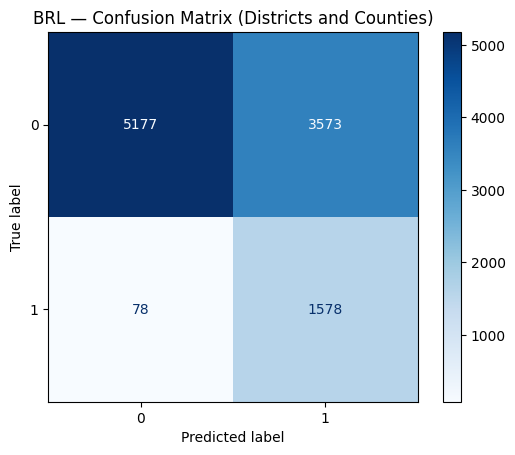


=== RULES EXTRACTED BY BRL ===
Trained RuleListClassifier for detecting intentional
IF ext_date_serial_bin_(34896.0, 35623.0] > 0.5 and fire_type > 0.5 THEN probability of intentional: 0.0% (0.0%-0.1%)
ELSE IF fire_type > 0.5 and start_year_bin_(1995.0, 1997.0] > 0.5 THEN probability of intentional: 0.1% (0.0%-0.3%)
ELSE IF ext_date_serial_bin_(34896.0, 35623.0] > 0.5 and start_year_bin_(1995.0, 1997.0] > 0.5 THEN probability of intentional: 55.5% (52.1%-59.0%)
ELSE IF start_year_bin_(1995.0, 1997.0] > 0.5 THEN probability of intentional: 19.7% (15.1%-24.7%)
ELSE IF county_encoded_bin_(137.0, 270.0] > 0.5 and fire_type > 0.5 THEN probability of intentional: 7.7% (6.6%-8.8%)
ELSE IF county_encoded_bin_(137.0, 270.0] > 0.5 THEN probability of intentional: 64.8% (62.3%-67.2%)
ELSE IF district_PORTO > 0.5 THEN probability of intentional: 38.1% (33.8%-42.4%)
ELSE IF county_encoded_bin_(53.0, 137.0] > 0.5 and start_year_bin_(1979.999, 1995.0] > 0.5 THEN probability of intentional: 46.2% (44

In [27]:
# === Bayesian Rule List with Districts PRESERVED ===
from imodels import BayesianRuleListClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# 1) PREPARE TARGET
# ======================================================
y = df['intentional'].astype(int).values

# ======================================================
# 2) IDENTIFY DISTRICT DUMMIES
# ======================================================
district_cols = [c for c in df.columns if c.startswith('district_')]
district_dummies = df[district_cols].astype(int)

# ======================================================
# 3) KEEP NUMERIC COLUMNS EXCEPT DISTRICT DUMMIES
# ======================================================
Xnum = df.drop(columns=['intentional'] + district_cols)\
         .select_dtypes(include=['number']).copy()

# Handle missing values
Xnum = Xnum.fillna(Xnum.median(numeric_only=True))

# Remove constant columns
Xnum = Xnum.loc[:, Xnum.nunique() > 1]

# ======================================================
# 4) SPLIT BINARY VS CONTINUOUS FEATURES
# ======================================================
binary_cols = [c for c in Xnum.columns if Xnum[c].nunique() <= 5]
cont_cols   = [c for c in Xnum.columns if Xnum[c].nunique() > 5]

# ======================================================
# 5) DISCRETIZE CONTINUOUS VARIABLES
# ======================================================
disc_parts = []

for c in cont_cols:
    ser = Xnum[c]
    done = False

    # Try quantile-based discretization (3 bins → fallback 2 bins)
    for q in (3, 2):
        try:
            bins = pd.qcut(ser, q=q, duplicates='drop')
            dmy  = pd.get_dummies(bins, prefix=f"{c}_bin", drop_first=False)
            disc_parts.append(dmy.astype(int))
            done = True
            break
        except:
            continue

    # Fallback: median split
    if not done:
        thr = ser.median()
        disc_parts.append(
            pd.DataFrame({f"{c}_gt_med": (ser > thr).astype(int)})
        )

# Convert discretized parts to binary
disc_parts_bin = [(d > 0).astype(int) for d in disc_parts]

# ======================================================
# 6) BUILD FINAL BINARY MATRIX FOR BRL
# ======================================================
# NOTE: Districts first → preserved exactly as 18 binary columns
X_bin = pd.concat(
    [district_dummies] +
    [Xnum[binary_cols].astype(int)] +
    disc_parts_bin,
    axis=1
)

# Ensure everything is binary
X_bin = (X_bin > 0).astype(int)

# ======================================================
# 7) TRAIN/TEST SPLIT
# ======================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y, test_size=0.3, random_state=42, stratify=y
)

# ======================================================
# 8) SMOTE (ONLY ON TRAIN)
# ======================================================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

X_train_res = pd.DataFrame(X_train_res, columns=X_bin.columns)
X_test      = pd.DataFrame(X_test,      columns=X_bin.columns)

# ======================================================
# 9) FIT BRL
# ======================================================
brl = BayesianRuleListClassifier(
    listlengthprior=3,
    listwidthprior=1,
    maxcardinality=2,
    minsupport=0.1,
    alpha=np.array([1., 1.]),
    n_chains=3,
    max_iter=50000,
    class1label="intentional",
    verbose=False,
    random_state=42
)

brl.fit(X_train_res, y_train_res, feature_names=X_train_res.columns.tolist())

# ======================================================
# 10) PREDICTION & METRICS
# ======================================================
y_pred = brl.predict(X_test)

print("=== Bayesian Rule List(Districts and Counties) ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("BRL — Confusion Matrix (Districts and Counties)")
plt.show()

# ======================================================
# 11) RULES
# ======================================================
print("\n=== RULES EXTRACTED BY BRL ===")
print(brl)


##### 3.3.4b. BRL using Counties Only
[[go back to the topic]](#334-bayesian-rule-list-model)

In this configuration, only **county-level variables** are used, excluding all district indicators.  



/Users/franciscamihalache/opt/anaconda3/envs/ac2/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/franciscamihalache/opt/anaconda3/envs/ac2/lib/python3.13/site-packages/imodels/rule_list/bayesian_rule_list/brl_util.py:342: RuntimeWarning: overflow encountered in exp
  q = exp(permsdic[a_star][0] - permsdic[a_t][0] + Jratio)


=== Bayesian Rule List (Counties only) ===
              precision    recall  f1-score   support

           0       0.99      0.57      0.72      8750
           1       0.30      0.96      0.45      1656

    accuracy                           0.63     10406
   macro avg       0.64      0.76      0.59     10406
weighted avg       0.88      0.63      0.68     10406



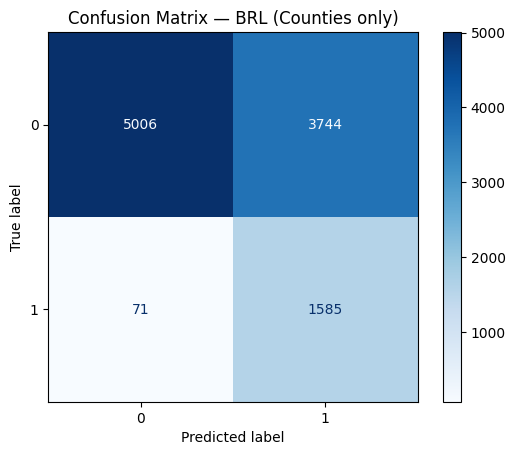


Rules:
 Trained RuleListClassifier for detecting intentional
IF ext_date_serial_bin_(34896.0, 35623.0] > 0.5 and fire_type > 0.5 THEN probability of intentional: 0.0% (0.0%-0.1%)
ELSE IF fire_type > 0.5 and start_year_bin_(1995.0, 1997.0] > 0.5 THEN probability of intentional: 0.1% (0.0%-0.3%)
ELSE IF county_encoded_bin_(137.0, 270.0] > 0.5 and fire_type > 0.5 THEN probability of intentional: 7.2% (6.1%-8.3%)
ELSE IF ign_date_serial_bin_(34896.0, 35623.0] > 0.5 and start_year_bin_(1995.0, 1997.0] > 0.5 THEN probability of intentional: 53.4% (49.8%-57.0%)
ELSE IF county_encoded_bin_(53.0, 137.0] > 0.5 and start_year_bin_(1979.999, 1995.0] > 0.5 THEN probability of intentional: 44.3% (42.9%-45.8%)
ELSE IF start_year_bin_(1995.0, 1997.0] > 0.5 THEN probability of intentional: 15.8% (11.5%-20.6%)
ELSE IF county_encoded_bin_(137.0, 270.0] > 0.5 THEN probability of intentional: 62.5% (59.9%-65.1%)
ELSE IF county_encoded_bin_(-0.001, 53.0] > 0.5 and start_year_bin_(1979.999, 1995.0] > 0.5 TH

In [ ]:
# === Robust BRL (Counties only, matching X=... logic) ===
from imodels import BayesianRuleListClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Drop districts and district_id (only counties + other numeric features)
X = df.drop(columns=[c for c in df.columns if c.startswith('district_')]
             + [ 'intentional'])
y = df['intentional'].astype(int).values

# Keep only numeric columns
Xnum = X.select_dtypes(include=['float64','int64']).copy()

# Handle missing and constant columns
Xnum = Xnum.fillna(Xnum.median(numeric_only=True))
Xnum = Xnum.loc[:, Xnum.nunique() > 1]

# 2) Separate binary and continuous columns
binary_cols = [c for c in Xnum.columns if Xnum[c].nunique() <= 5]
cont_cols   = [c for c in Xnum.columns if Xnum[c].nunique() > 5]

# 3) Discretize continuous features
disc_parts = []
for c in cont_cols:
    ser = Xnum[c]
    done = False
    for q in (3, 2):  # try ternary, then binary quantiles
        try:
            bins = pd.qcut(ser, q=q, duplicates='drop')
            dmy = pd.get_dummies(bins, prefix=f"{c}_bin", drop_first=False)
            disc_parts.append(dmy.astype(int))
            done = True
            break
        except Exception:
            continue
    if not done:
        thr = ser.median()
        disc_parts.append(pd.DataFrame({f"{c}_gt_med": (ser > thr).astype(int)}))

# 4) Build final binary design matrix
X_bin = pd.concat([Xnum[binary_cols].astype(int)] + disc_parts, axis=1)
X_bin = (X_bin > 0).astype(int)
X_bin = X_bin.loc[:, X_bin.sum(axis=0) > 0]

# 5) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y, test_size=0.3, random_state=42, stratify=y
)

from imblearn.over_sampling import SMOTE

# Oversampling ONLY numeric binary-design matrix
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


X_train = pd.DataFrame(X_train, columns=X_bin.columns)
X_test = pd.DataFrame(X_test, columns=X_bin.columns)


# 6) Train BRL
brl = BayesianRuleListClassifier(
    listlengthprior=3, listwidthprior=1,
    maxcardinality=2, minsupport=0.1,
    alpha=np.array([1., 1.]), n_chains=3,
    max_iter=50000, class1label="intentional",
    verbose=False, random_state=42
)
brl.fit(X_train.values, y_train, feature_names=X_train.columns.tolist())

# 7) Evaluation
y_pred = brl.predict(X_test.values)
print("=== Bayesian Rule List (Counties only) ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix — BRL (Counties only)")
plt.show()












#### 3.3.5 Summary of In-Modelling Classifier Performance
[[go back to the topic]](#33-glass-model-training)

The evaluation of interpretable models reveals clear behavioural differences consistent with their theoretical properties. **Logistic Regression** performs poorly for detecting intentional cases (class 1): although recall varies between 0.39–0.66, precision remains very low (0.22–0.25), reflecting the model’s inability to capture non-linear relationships.

**Decision Trees** handle feature interactions effectively and achieve substantially higher recall for class 1 (0.69–0.78). However, precision is modest (≈0.37–0.42), producing many false positives despite improved sensitivity.

**RuleFit** prioritises sparse and high-precision rule structures. This results in higher precision for class 1 (0.52–0.62), but sharply reduced recall (0.11–0.32), meaning many intentional cases remain undetected.

**Bayesian Rule Lists** achieve the highest sensitivity overall, with recall reaching 0.96 for class 1. Precision, however, remains low (0.30), as highly general rules tend to over-predict the positive class.

In summary, when the main requirement is to identify all intentional cases, **Decision Trees** and **Bayesian Rule Lists** offer the strongest recall. **RuleFit** provides the most conservative behaviour with better precision but insufficient sensitivity, while **Logistic Regression**, despite being fully transparent, fails to adequately model the decision boundary for this task.

**Feature Importance Analysis**

Across all interpretable classifiers, a consistent set of features emerges as the primary drivers of intentional fire prediction. The most influential variable overall is *fire_type*, which dominates both tree-based and rule-based decision structures and shows strong coefficients in linear models. Temporal attributes—particularly ignition and extinction dates, as well as the start year—also rank systematically among the top predictors, indicating that intentional fires follow identifiable temporal patterns.

Geographical information contributes meaningfully but asymmetrically: *county_encoded* shows moderate to high importance across models, whereas district-level indicators (*district_***) display low average predictive weight. Despite this, district variables frequently appear in RuleFit and Bayesian Rule List rules, suggesting that while they are not strong global predictors, they refine locally interpretable conditions.

Environmental and structural variables such as *shrub_total* offer additional predictive value, consistently appearing among the most relevant features, especially in tree-based methods. Variables tied to the time of day (e.g., *ign_hour*, *ext_hour*, *time fractions*) provide smaller but recurrent contributions, typically acting as secondary refinements to broader decision boundaries.

Overall, the most influential features across models are *fire_type*, temporal descriptors, *county_encoded*, and vegetation-related metrics. District-level indicators show limited global importance but enhance interpretability within rule-based explanations, supporting a richer qualitative understanding of spatial patterns in intentional wildfire occurrence.


## 4. Post-Modelling
[[go back to top]](#table-of-contents)

This section focuses on **post-hoc explainability techniques**, which are applied *after* the training of a black-box model.  

While pre-modelling and in-modelling approaches aim to build interpretable models from the start, post-modelling methods seek to **understand or approximate the behavior** of complex models that are already trained.  

According to the XAI taxonomy presented in the lectures, post-hoc methods can be grouped into three main categories:  
1. **Simplification-based techniques** — build a simpler surrogate model (e.g., decision tree or linear model) that mimics the black-box behavior.  
2. **Feature-based techniques** — analyze how individual input features influence model predictions (e.g., PDP, ICE, PFI).  
3. **Example-based techniques** — explain individual predictions through concrete instances (e.g., LIME, SHAP, counterfactuals).  

The following subsections implement and compare these approaches on the trained models to assess both **global** and **local** interpretability.

### 4.1 – Explainability Techniques  
[[go back to the topic]](#4-post-modelling)

Explainability techniques aim to make the internal logic of a predictive model more understandable.  
Within the XAI taxonomy, **post-hoc methods** are applied after training a model to interpret or approximate its behavior without altering it.  

These methods can provide explanations at different levels:
- **Global** → understanding how the model behaves overall.  
- **Feature-level** → understanding which features drive predictions.  
- **Local** → explaining individual decisions.

The next sections apply these three complementary approaches — simplification-based, feature-based, and example-based — to the previously trained black-box models.



In [ ]:
!pip install xgboost tqdm

/Users/franciscamihalache/opt/anaconda3/envs/ac2/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=85475) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


### 4.2. Black box Model Training
[[go back to the topic]](#4-post-modelling)

In this part of the notebook the black models choosed will be trained, only after being trained the XAI techniques will be applied

#### 4.2.1. XGBoost
[[go back to the topic]](#42-black-box-model-training)


Training XGBoost: 100%|██████████| 199/199 [00:05<00:00, 34.47round/s, train=0.1841, test=0.2780]


=== XGBoost Classifier (Districts + Counties) ===
              precision    recall  f1-score   support

           0     0.9536    0.8523    0.9001      7564
           1     0.6936    0.8895    0.7794      2842

    accuracy                         0.8625     10406
   macro avg     0.8236    0.8709    0.8398     10406
weighted avg     0.8825    0.8625    0.8671     10406



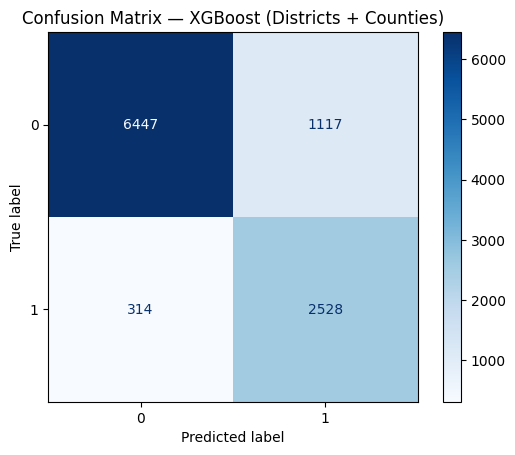

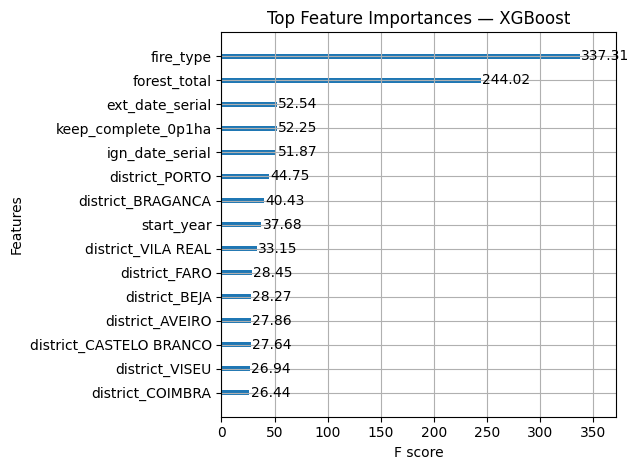


=== XGBoost Feature Importances ===
                                 gain
fire_type                  337.314575
forest_total               244.020630
ext_date_serial             52.539558
keep_complete_0p1ha         52.253704
ign_date_serial             51.873352
district_PORTO              44.751846
district_BRAGANCA           40.426277
start_year                  37.681095
district_VILA REAL          33.154011
district_FARO               28.448849
district_BEJA               28.274014
district_AVEIRO             27.861219
district_CASTELO BRANCO     27.642967
district_VISEU              26.936344
district_COIMBRA            26.443857
district_SETUBAL            25.899832
district_EVORA              25.756962
district_BRAGA              22.623308
district_PORTALEGRE         22.416159
district_GUARDA             22.060995
district_VIANA DO CASTELO   21.907333
shrub_total                 20.174938
district_LEIRIA             19.572601
district_LISBOA             18.124706
district_SANT

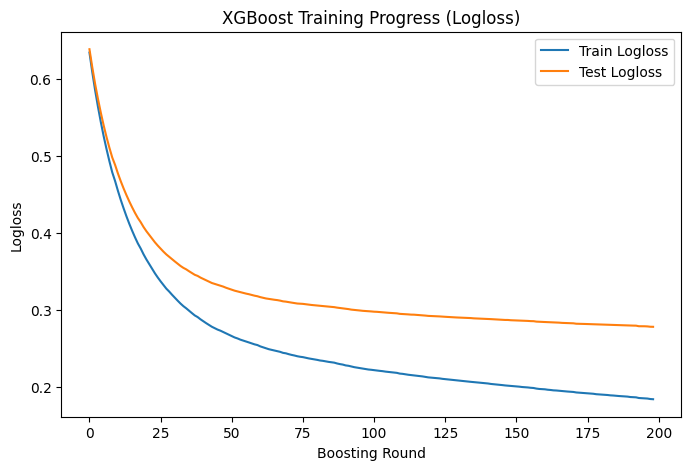

In [29]:
# === XGBoost Model (Districts + Counties) ===
# ----------------------------------------------------------
# Includes:
# - boolean → int conversion (so XGBoost uses all features)
# - full feature preservation (categories, districts, flags)
# - proper preprocessing pipeline with imputation
# - correct incremental XGBoost training with tqdm progress bar
# ----------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import xgboost as xgb

# === 1. Prepare data ===
X = df.drop(columns=['intentional'])
y = df['intentional']

# Convert boolean columns to integers (makes them numeric features)
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Apply SMOTE to training data
X_train, y_train = sm_num_cat.fit_resample(X_train, y_train)

# Identify all numeric features (ints, floats, converted booleans)
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# === 2. Preprocessing ===
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Apply preprocessing to numeric columns only
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols)
    ],
    remainder='passthrough'
)

# === 3. Transform data for XGBoost ===
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)


# Convert to DMatrix
dtrain = xgb.DMatrix(X_train_proc, label=y_train)
dtest = xgb.DMatrix(X_test_proc, label=y_test)

# === XGBoost Parameters ===
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'random_state': 42,
}

num_rounds = 200

# === 4. Correct incremental training with tqdm ===
# Initialize booster with 1 initial round (required to set num_feature)
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1
)

train_losses = []
test_losses = []

progress = tqdm(range(1, num_rounds), desc="Training XGBoost", unit="round")

for i in progress:
    # Incrementally add one boosting round
    bst.update(dtrain, i)

    # Predictions
    pred_train = bst.predict(dtrain)
    pred_test = bst.predict(dtest)

    # Manual logloss computation
    eps = 1e-9
    train_loss = np.mean(
        -y_train * np.log(pred_train + eps) -
        (1 - y_train) * np.log(1 - pred_train + eps)
    )
    test_loss = np.mean(
        -y_test * np.log(pred_test + eps) -
        (1 - y_test) * np.log(1 - pred_test + eps)
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    progress.set_postfix({
        "train": f"{train_loss:.4f}",
        "test": f"{test_loss:.4f}"
    })

# === 5. Evaluate final model ===
y_pred_prob = bst.predict(dtest)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("=== XGBoost Classifier (Districts + Counties) ===")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — XGBoost (Districts + Counties)")
plt.show()

# === 6. Feature importance ===
feature_names = numeric_cols
bst.feature_names = feature_names

ax = xgb.plot_importance(
    bst,
    importance_type='gain',
    max_num_features=15
)

# --- Round the bar labels text (the numbers at the end of each bar) ---
for child in ax.get_children():
    if isinstance(child, plt.Text):          # only text elements
        txt = child.get_text()
        try:
            num = float(txt)
            child.set_text(f"{num:.2f}")     # round to 2 decimals
        except ValueError:
            pass

plt.title("Top Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

# Map feature importances to real names
importance_dict = bst.get_score(importance_type='gain')

importance_named = (
    pd.DataFrame.from_dict(importance_dict, orient='index', columns=['gain'])
      .sort_values(by='gain', ascending=False)
)

print("\n=== XGBoost Feature Importances ===")
print(importance_named.head(30))

# === Final losses ===
print(f"\nFinal Train Logloss: {train_losses[-1]:.4f}")
print(f"Final Test Logloss:  {test_losses[-1]:.4f}")

# === Loss curves ===
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Logloss')
plt.plot(test_losses, label='Test Logloss')
plt.xlabel('Boosting Round')
plt.ylabel('Logloss')
plt.title('XGBoost Training Progress (Logloss)')
plt.legend()
plt.show()


**Note on XGBoost Feature Importance:**

XGBoost provides feature importance metrics, but because it is a black-box model, these values are not reliable explanations of how predictions are made. They reflect internal training statistics rather than true model reasoning, so they should be seen as rough diagnostics rather than faithful interpretability. For actual explanatory purposes, model-agnostic methods such as SHAP or LIME are required.


#### 4.2.2. Random Forest 
[[go back to the topic]](#42-black-box-model-training)

Training Random Forest: 100%|██████████| 300/300 [00:02<00:00, 117.81tree/s]

=== Random Forest Classifier (Districts + Counties) ===
              precision    recall  f1-score   support

           0     0.9675    0.8194    0.8873      7564
           1     0.6585    0.9268    0.7700      2842

    accuracy                         0.8487     10406
   macro avg     0.8130    0.8731    0.8286     10406
weighted avg     0.8831    0.8487    0.8553     10406



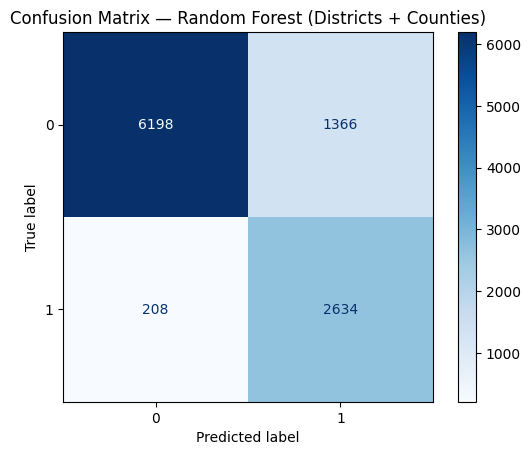

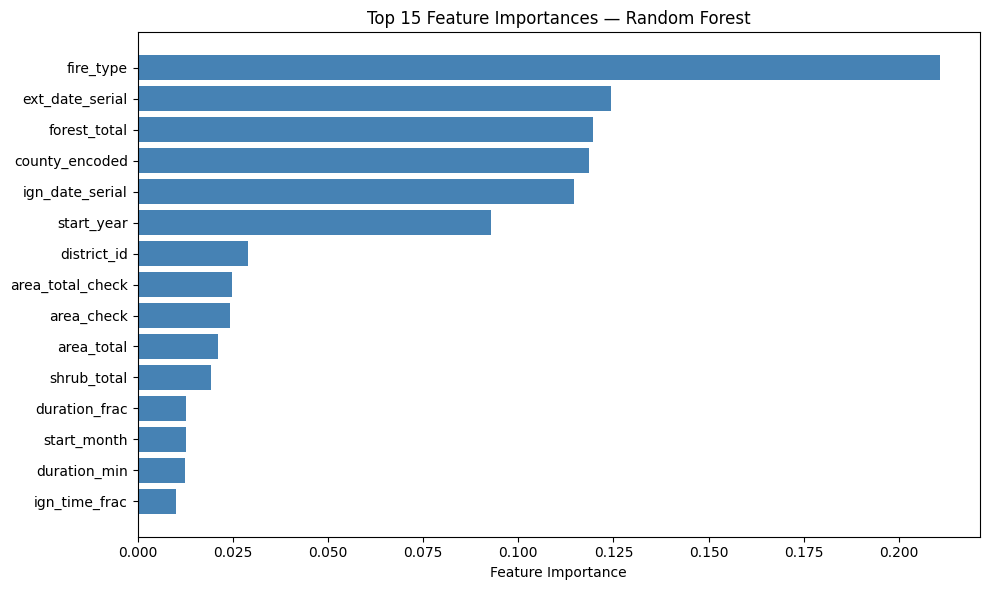

OOB Loss: 0.1046
Final Test Log Loss: 0.2987


In [132]:
# === Random Forest Model (Districts + Counties) ===
# ----------------------------------------------------------
# Includes:
# - Preprocessing (imputation)
# - Training with tqdm progress bar
# - Evaluation metrics and confusion matrix visualization
# ----------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss
from tqdm import tqdm
import matplotlib.pyplot as plt

# === 1. Prepare data ===
X = df.drop(columns=['intentional'])
y = df['intentional']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train, y_train = sm_num_cat.fit_resample(X_train, y_train)

# Identify numeric columns
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# === 2. Preprocessing ===
# Use median imputation for missing numeric values
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Apply transformations only to numeric columns
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols)
])

# Transform data before model training
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# === 3. Initialize Random Forest ===
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=3,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,  # use all CPU cores
    oob_score=True,
)

# === 4. Training with tqdm progress bar ===
# tqdm wrapper for visual progress

n_trees = rf.n_estimators
progress = tqdm(total=n_trees, desc="Training Random Forest", unit="tree")

# Custom incremental fitting
rf.fit(X_train_proc, y_train)
for i in range(n_trees):
    progress.update(1)

progress.close()

# === 5. Evaluate model ===
y_pred = rf.predict(X_test_proc)

print("=== Random Forest Classifier (Districts + Counties) ===")
print(classification_report(y_test, y_pred, digits=4))

# === 6. Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Random Forest (Districts + Counties)")
plt.show()

# === 7. Feature Importance Plot ===
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15 features
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices][::-1], color='steelblue')
plt.yticks(range(len(indices)), np.array(numeric_cols)[indices][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

# === 8. Out of bag ===
# in order to interpert it as a loss
oob_loss = 1 - rf.oob_score_
print(f"OOB Loss: {oob_loss:.4f}")

# === 9. Log loss ===

y_pred_prob = rf.predict_proba(X_test_proc)
test_log_loss = log_loss(y_test, y_pred_prob)
print(f"Final Test Log Loss: {test_log_loss:.4f}")


#### 4.2.3. Neural Network
[[go back to the topic]](#42-black-box-model-training)

Training Deep Neural Network:   5%|▍         | 99/2000 [10:16<3:17:27,  6.23s/epoch]


=== Deep Neural Network (Districts + Counties) ===
              precision    recall  f1-score   support

           0     0.8832    0.8761    0.8797      7564
           1     0.6772    0.6918    0.6844      2842

    accuracy                         0.8258     10406
   macro avg     0.7802    0.7839    0.7820     10406
weighted avg     0.8270    0.8258    0.8263     10406



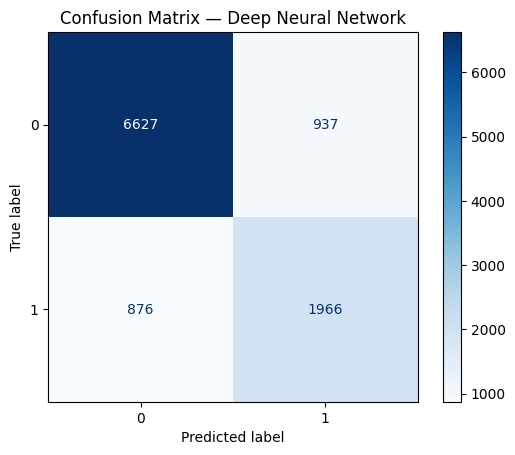

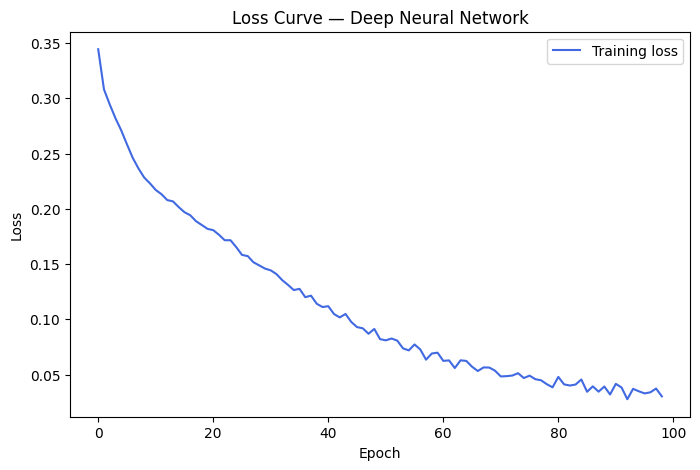

Final Training Loss: 0.0303


In [ ]:
from sklearn.neural_network import MLPClassifier

# === 1. Data preparation ===
X = df.drop(columns=['intentional'])
y = df['intentional']

# Keep only numeric columns for the neural network
X = X.select_dtypes(include=['float64', 'int64'])

# Split into train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train, y_train = sm_num_cat.fit_resample(X_train, y_train)

# Normalize numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# === 2. Define deep neural network ===
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64, 32),  # deep architecture
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.0005,
    alpha=1e-4,                # L2 regularization
    batch_size=64,
    max_iter=2000,             # large iteration limit
    early_stopping=True,       # stops when validation loss stops improving
    n_iter_no_change=50,       # patience
    validation_fraction=0.15,
    random_state=42,
    verbose=False
)

# === 3. Train with tqdm progress bar ===
progress = tqdm(total=mlp.max_iter, desc="Training Deep Neural Network", unit="epoch")
mlp.fit(X_train_scaled, y_train)
progress.update(mlp.n_iter_)
progress.close()

# === 4. Evaluation ===
y_pred = mlp.predict(X_test_scaled)

print("=== Deep Neural Network (Districts + Counties) ===")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Deep Neural Network")
plt.show()

# === 5. Learning curve ===
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, label="Training loss", color='royalblue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve — Deep Neural Network")
plt.legend()
plt.show()


final_train_loss = mlp.loss_curve_[-1]
print(f"Final Training Loss: {final_train_loss:.4f}")



**Selection of the Black-Box Model**

After evaluating the three trained models( **Random Forest**, **XGBoost**, and **Deep Neural Network**) the **XGBoost classifier** was selected as the black-box model to be interpreted through post-hoc explainability techniques.  

This decision is based on both **quantitative performance** and **model complexity**:

- **Quantitative performance:**  
  The XGBoost model achieved the **highest overall accuracy (86.23%)** and the most balanced trade-off between precision (0.87) and recall (0.86), resulting in a **macro F1-score of 0.83**.  
  By contrast, the Random Forest reached 84.87% accuracy with a slightly higher recall but lower precision for class 1, while the Neural Network achieved only 82.58% accuracy and the lowest F1-score (0.78).  
  This indicates that XGBoost provides the most consistent predictive behaviour across both classes.

- **Model complexity:**  
  XGBoost is an **ensemble of boosted decision trees**, combining multiple weak learners through sequential optimization.  
  This structure captures complex non-linear relationships and feature interactions that are difficult to interpret directly, making it a genuine *black-box* in terms of explainability.  
  Random Forest, while also ensemble-based, is less opaque since its trees are independent and easier to analyze. The Neural Network, although non-linear, showed lower predictive stability in this task.

For these reasons, XGBoost was chosen as the **reference black-box model** to be approximated by interpretable surrogate models in the following subsections.  
This ensures that the applied explainability techniques target a model that is **both performant and sufficiently complex** to justify post-hoc interpretation.


 ### 4.3. Simplification-Based Explanation (Task 3.1)
[[go back to the topic]](#4-post-modelling)

The predictive model used in this project is XGBoost, an ensemble of many shallow trees trained sequentially to capture complex, non-linear relationships. Although highly accurate, its decision logic is distributed across numerous weak learners, making the model difficult to interpret directly.

To obtain a global explanation, we use post-hoc simplification-based methods. These techniques aim to replace the behaviour of a complex model with a simpler and more interpretable representation. Within this family, three possible approaches exist: dimensionality reduction, global surrogate models, and rule extraction.

**Dimensionality-reduction** methods compress the feature space (e.g., PCA or t-SNE) and help visualise data patterns, but they do not simplify or explain the model’s decision process. For this reason, they are not used in our setting.

We will apply a **global surrogate model** by training an interpretable classifier—such as a decision tree—to approximate the predictions of XGBoost. This provides a compact, transparent overview of the main decision patterns, and its fidelity can be evaluated by comparing its outputs with those of the black-box model.


#### 4.3.1. Global Surrogate Model  
[[go back to the topic]](#43-simplification-based-explanation-task-31)

To evaluate how well the surrogate model reproduces the behaviour of the XGBoost classifier, we follow the metrics defined for classification tasks. The objective is to assess how closely the surrogate approximates the predictions of the original model rather than how well it predicts the true labels.

The main fidelity measure is the **Agreement Rate**, which quantifies the proportion of samples for which the surrogate produces the same predicted class as the black-box model:

$$
\text{AgreementRate}
= \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}\!\left( \hat{y}^{(s)}_i = \hat{y}^{(o)}_i \right)
$$

where $N$ is the number of samples, 
$\hat{y}^{(s)}_i$ is the surrogate prediction, 
$\hat{y}^{(o)}_i$ is the XGBoost prediction, 
and $\mathbb{1}(\cdot)$ is the indicator function that returns 1 when the condition is true and 0 otherwise.

When probability outputs are available, fidelity can also be quantified using **LogLoss**, comparing the class-probability distributions of the surrogate and the original model:

$$
\text{LogLoss}
= -\frac{1}{N}\sum_{i=1}^{N}\sum_{j=1}^{C}
\hat{p}^{(o)}_{ij}\,\log\!\big(\hat{p}^{(s)}_{ij}\big)
$$

where $C$ is the number of classes,  
$\hat{p}^{(o)}_{ij}$ is the probability assigned by XGBoost to class $j$,  
and $\hat{p}^{(s)}_{ij}$ is the probability assigned by the surrogate.

These measures indicate how well the surrogate captures the global decision behaviour of the black-box model. High values of agreement and low log-loss imply that the simplified model provides a faithful approximation of the underlying ensemble.



##### 4.3.1a. CART Decision Tree
[[go back to the topic]](#431-global-surrogate-model)

As a global surrogate, we use a CART decision tree trained on the input features and the class predictions of the XGBoost model. Decision trees are explicitly listed as interpretable models in the simplification-based XAI framework, and they provide clear splitting conditions and decision paths while still being flexible enough to approximate the behaviour of a tree-ensemble classifier.

Other interpretable models (e.g., logistic regression or rule lists) could also be used as surrogates, but we focus on a single decision tree to keep the explanation concise and to complement the rule-extraction approach used in the next subsection.

Black-box training predictions: [0 1] [20157 20677]
Agreement Rate: 0.923


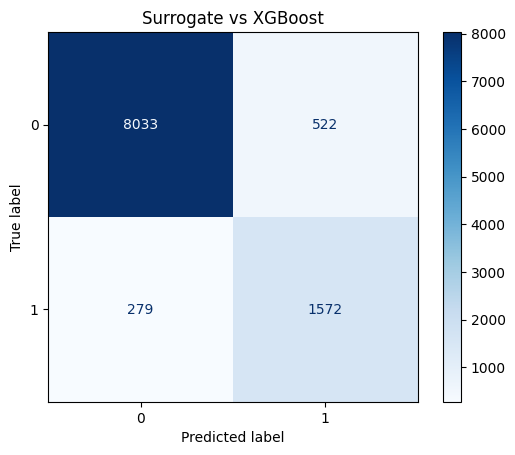

LogLoss: 0.094


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, log_loss
import matplotlib.pyplot as plt
import numpy as np

# Black-box predictions
y_bb_train_prob = bst.predict(dtrain, validate_features=False)
y_bb_train = (y_bb_train_prob >= 0.5).astype(int)

# Debug: rounded class counts
classes, counts = np.unique(y_bb_train, return_counts=True)
print("Black-box training predictions:", classes, counts)

# Train surrogate
surrogate = DecisionTreeClassifier(
    max_depth=20,
    min_samples_leaf=20,
    random_state=42
)
surrogate.fit(X_train_proc, y_bb_train)

# Surrogate predictions
y_sur_test = surrogate.predict(X_test_proc)
y_sur_train_prob = surrogate.predict_proba(X_train_proc)

# Fidelity (agreement) with rounding
agreement = accuracy_score(
    (bst.predict(dtest, validate_features=False) >= 0.5).astype(int),
    y_sur_test
)
print("Agreement Rate:", round(agreement, 4))

# Confusion matrix
cm = confusion_matrix(
    (bst.predict(dtest, validate_features=False) >= 0.5).astype(int),
    y_sur_test
)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Surrogate vs XGBoost")
plt.show()

# Safe logloss with rounding
eps = 1e-9
y_sur_train_prob = np.clip(y_sur_train_prob, eps, 1-eps)
y_bb_train_prob = np.clip(y_bb_train_prob, eps, 1-eps)

ll = log_loss(y_bb_train, y_sur_train_prob)
print("LogLoss:", round(ll, 4))



##### 4.3.1b. Fidelity Evaluation and Feature Importance
[[go back to the topic]](#431-global-surrogate-model)

To evaluate how well the surrogate model reproduces the behaviour of the XGBoost classifier, we compare the surrogate’s predictions with those of the black-box model on the same data. The surrogate decision tree is trained to mimic XGBoost outputs, and its fidelity is measured using two metrics. The **Agreement Rate** reflects the proportion of instances where both models assign the same class, reaching about **92%**, which indicates strong behavioural alignment. The **LogLoss** compares their probability distributions and is very low (~0.094), confirming that the surrogate closely matches the decision patterns of the ensemble. These results show that the simplified surrogate provides a faithful and interpretable approximation of the original model.



To better understand how the surrogate model approximates the behaviour of XGBoost, we also analyse the feature importances of the trained decision tree.  


=== Surrogate Feature Importances ===
                      feature  importance
8             ext_date_serial    0.276010
3                   fire_type    0.259982
29             county_encoded    0.086015
0                 shrub_total    0.069966
47             district_VISEU    0.034951
26                start_month    0.023943
27                  start_dow    0.023145
4             ign_date_serial    0.021201
45  district_VIANA DO CASTELO    0.020600
6                    ign_hour    0.017956
17                    weekday    0.013875
12              duration_frac    0.013001
1                forest_total    0.012725
30            district_AVEIRO    0.012019
5               ign_time_frac    0.011712


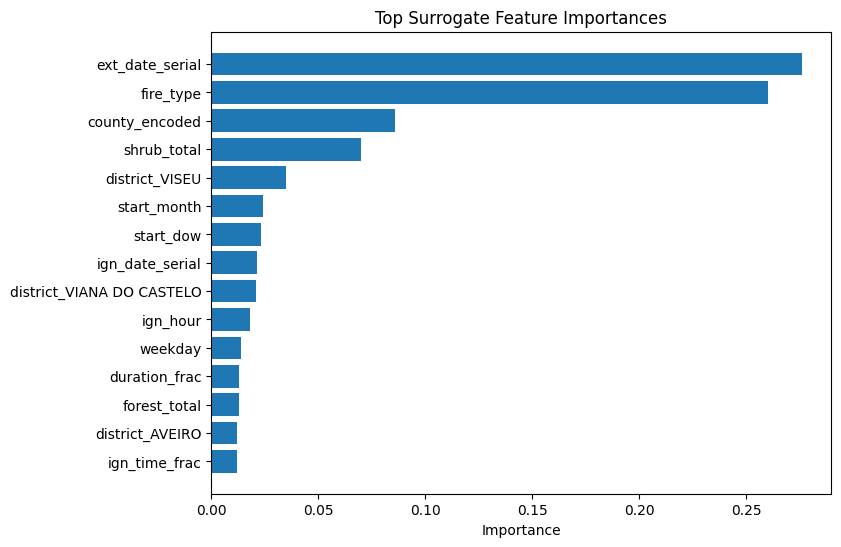

In [43]:
# Surrogate feature importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sur_importance = surrogate.feature_importances_

# Map to real feature names (after preprocessing passthrough)
sur_imp_df = pd.DataFrame({
    "feature": numeric_cols,
    "importance": sur_importance
}).sort_values(by="importance", ascending=False)

print("\n=== Surrogate Feature Importances ===")
print(sur_imp_df.head(15))

# Plot
plt.figure(figsize=(8, 6))
plt.barh(sur_imp_df.head(15)["feature"], sur_imp_df.head(15)["importance"])
plt.gca().invert_yaxis()
plt.title("Top Surrogate Feature Importances")
plt.xlabel("Importance")
plt.show()


The surrogate tree highlights a compact subset of influential features — such as *ext_date_serial*, *fire_type*, and *county_encoded* — suggesting that these variables play a central role in approximating the global decision structure learned by XGBoost.  
While these importances do not explain the black-box model directly, they offer a simplified, interpretable summary of the decision patterns captured by the surrogate.

**Note:** We attempted to apply rule extraction methods in practice; however, the available frameworks such as *InTrees* are implemented exclusively in R and have no Python equivalents. Other alternatives (e.g., GENESIM or defragTrees) are not compatible with XGBoost or lack usable Python support. As a consequence, rule extraction could not be operationally integrated into our pipeline and remains a conceptual complement rather than an implemented component.


 ### 4.4. Feature-Based Explanation (Task 3.2)
[[go back to the topic]](#4-post-modelling)

#### 4.4.3. Local Interpretable Model-Agnostic Explanations (LIME)
[[go back to the topic]](#44-feature-based-explanation-task-32)



0


/tmp/ipykernel_163501/3343586865.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


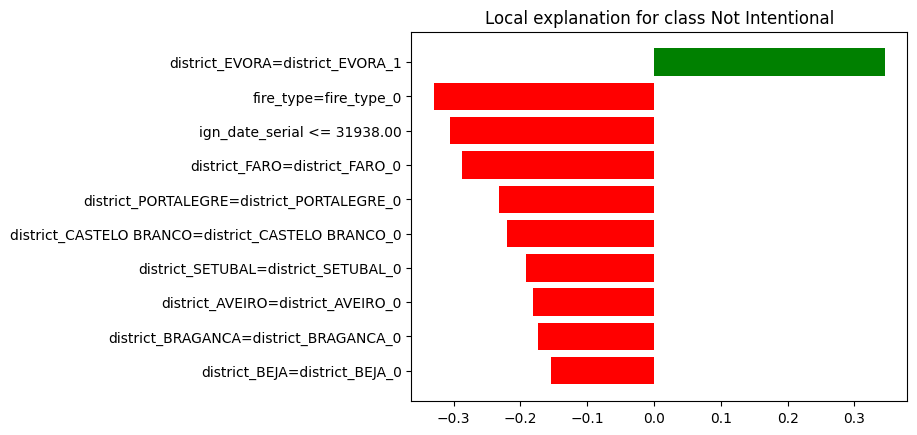

In [31]:
from lime.lime_tabular import LimeTabularExplainer

# All the boolean features this includes the districts dummy columns
bool_like = [col for col in X_train.columns if X_train[col].nunique() == 2]

# Other categorical features that have more than 2 values 
categorical_ints = ["county_encoded", "flag1", "flag2", "weekday"]
categorical_columns= categorical_ints + bool_like

# Geting the index of the columns that are categorical features
categorical_features = [X_train.columns.get_loc(col) for col in categorical_columns]


# Variable that will map the values in all the categorical features to their name
categorical_names = {}

for col in categorical_columns:
    idx = X_train.columns.get_loc(col)
    cats = sorted(X_train[col].unique())
    categorical_names[idx] = [f"{col}_{c}" for c in cats]


lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    class_names=['Not Intentional', 'Intentional'],   # replace as needed
    categorical_features=categorical_features,
    categorical_names=categorical_names,
    mode='classification'
)



# Wrapper so that we can use the correct input for the prediction using XGBoost
def predict_proba_xgb(input_array):
    dmatrix = xgb.DMatrix(input_array, feature_names=X_train.columns.tolist())
    proba_1 = bst.predict(dmatrix)
    proba_0 = 1 - proba_1
    return np.column_stack((proba_0, proba_1))


# Generation of the explanation
y_pred = np.argmax(predict_proba_xgb(X.iloc[[0]]))
explanation_lime = lime_explainer.explain_instance(
    data_row=X.iloc[0].values,
    predict_fn=predict_proba_xgb,
    labels=[y_pred],
    num_samples=5000
)
print(y_pred)


# Ploting explanation for the row explained
fig = explanation_lime.as_pyplot_figure(label=y_pred)

fig.set_facecolor("white")
ax = fig.axes[0]
ax.set_facecolor("white")

fig.show()


In [32]:
explanation_lime.show_in_notebook()

#### 4.4.4. SHapley Additive exPlanations (SHAP)
[[go back to the topic]](#44-feature-based-explanation-task-32)

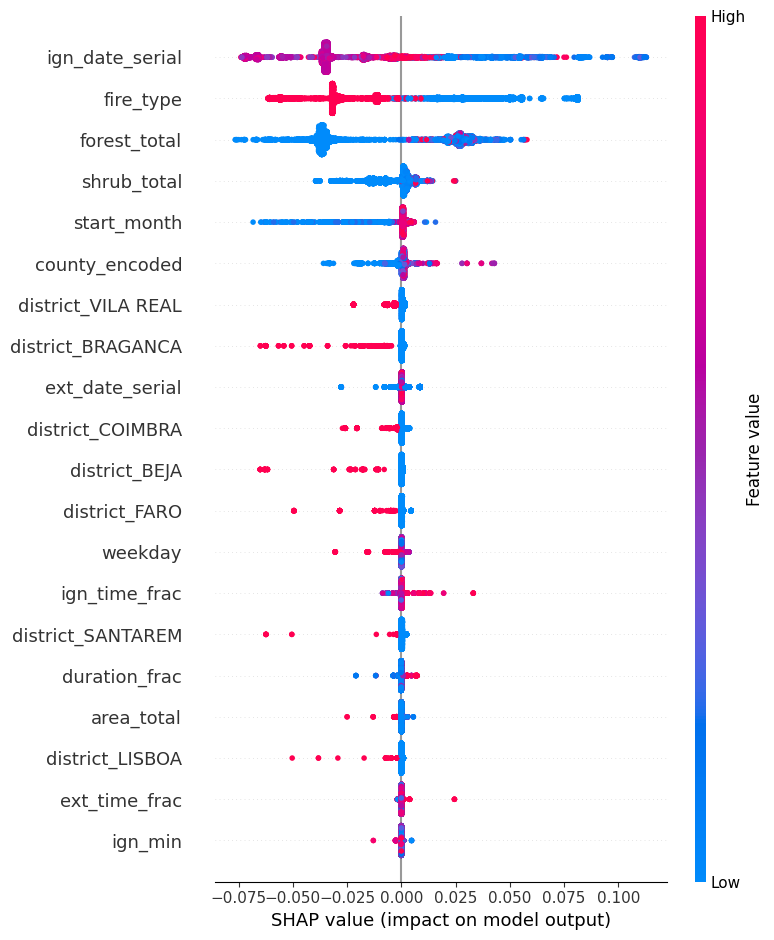

In [30]:
import shap

shap.initjs()

# SHAP explainer for XGBoost model
explainer = shap.TreeExplainer(bst)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot for the positive class (class 1)
shap.summary_plot(shap_values, pd.DataFrame(X_test, columns=X_test.columns))
